# Scripts for reproducing Figures in study

## Fig. 1 Schematic overview of the PPI-based computational framework for viral phenotype prediction.

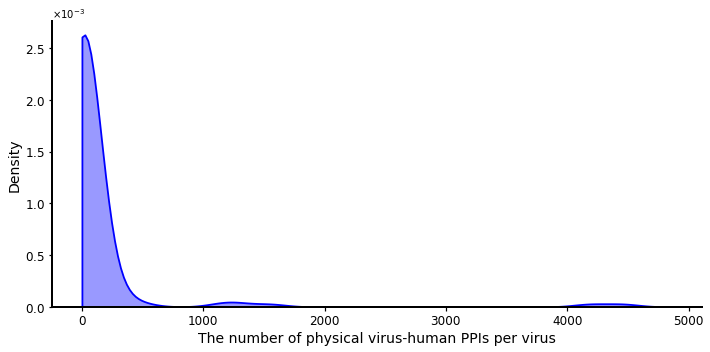

In [ ]:
##====== Fig. 1A Distribution of experimentally determined physical virus-human PPIs ======##

def show_ppi_virus_density():
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.ticker as mticker

    # ======== 读取数据 ========
    df = pd.read_csv("../../data/virus_human_physical_ppi.txt", sep="\t", header=0)

    # ======== 每个病毒的 PPI 数 ========
    df_counts = df.groupby("VirusName").size().reset_index(name="ppi_count")

    # ======== 绘制密度分布 ========
    plt.figure(figsize=(10, 5))
    
    sns.kdeplot(
        data=df_counts,
        x="ppi_count",
        fill=True,
        color="blue",       # Nature-style 蓝色
        alpha=0.4,
        linewidth=1.8,
        clip=(0, None),
        bw_adjust=0.6,
    )
    
    # ======== 图形美化 ========
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

    ax.tick_params(axis='both', labelsize=12, width=1.2)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

    plt.xlabel("The number of physical virus-human PPIs per virus", fontsize=14)
    plt.ylabel("Density", fontsize=14)

    plt.tight_layout()

    plt.savefig("../../fig_in_paper/Fig1A_panel1.pdf",
                format="pdf",
                dpi=300,
                bbox_inches="tight",
                pad_inches=0.1)

    plt.show()


if __name__ == "__main__":
    show_ppi_virus_density()


(16314, 5)


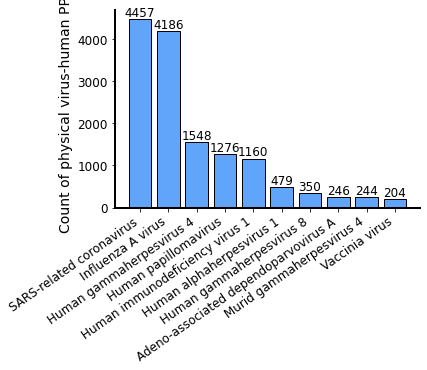

In [ ]:
##====== Fig. 1a The top 10 virus species of all PPIs ======##

def show_ppi_virusFam_top20():
    import pandas as pd
    import matplotlib.pyplot as plt
    
    df = pd.read_csv("../../data/virus_human_physical_ppi.txt", sep="\t", header=0)
    print(df.shape)

    # 统计每个病毒科（VirusName）的 PPI 数目（即行数），只取前10
    family_counts = df["VirusName"].value_counts().head(10)

    family_counts.index = [
        name.replace("Severe acute respiratory syndrome-related coronavirus", "SARS-related coronavirus")
        for name in family_counts.index
    ]
    
    # 绘制柱状图
    plt.figure(figsize=(6,5.2))
    bars = plt.bar(family_counts.index, family_counts.values,
                   color="#60a5fa", edgecolor="black")
    
    # 在柱子上方添加数值
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 str(height), ha='center', va='bottom', fontsize=12)
        
    
    # 设置标签
    plt.ylabel("Count of physical virus-human PPIs", fontsize=14)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

    plt.xticks(rotation=35, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()

    plt.savefig(
        "../../fig_in_paper/Fig1A_panel2.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.1
    )
    
    plt.show()


if __name__ == "__main__":
    show_ppi_virusFam_top20()


In [ ]:
##====== Fig. 1a Top 5 families of all PPIs ======##

## see ./codeForFig1A.R

In [ ]:
##====== Fig. 1b Framework for predicting viral phenotypes with predicted virus-human PPIs ======##

## see ../../fig_saved/Fig1B_workflow.drawio

## Fig. 2 Prediction of viral human infectivity

In [10]:
import pandas as pd

dt = pd.read_excel("../../data/dataset_from_gaowenze/human_infecting_viruses_from_fy_gwz_260910.xlsx", sheet_name="human_infecting_virus", header=0)
dt_high = dt[dt["Evidence level"]=="high"].reset_index(drop=True)
dt_mid = dt[dt["Evidence level"]=="middle"].reset_index(drop=True)
dt_low = dt[dt["Evidence level"]=="low"].reset_index(drop=True)

print(f"No.Virus: High={dt_high.shape[0]}; Middle={dt_mid.shape[0]}; Low={dt_low.shape[0]}; Sum={dt.shape[0]}")

No.Virus: High=331; Middle=346; Low=792; Sum=1469


In [3]:
## Figure 2A: data prepration (将数据整理为 upset 的格式)
def data_prepare_for_fig2a_extract_source():
    import pandas as pd

    dt = pd.read_excel("../../data/dataset_from_gaowenze/human_infecting_viruses_from_fy_gwz_260910.xlsx", sheet_name="human_infecting_virus", header=0)
    #dt = dt[dt["Evidence level"]!="low"].reset_index(drop=True)
    print(dt.shape, len(dt["Taxid"].unique()))
    souce_str_list = dt["Evidence source"].unique().tolist()
    source_list = []
    for src_str in souce_str_list:
        tmp_list = src_str.split(";")
        for src in tmp_list:
            source_list.append(src.strip())
    source_list = list(set(source_list))
    print(source_list)
    

def data_prepare_for_fig2a():
    import pandas as pd
    import numpy as np

    dt = pd.read_excel("../../data/dataset_from_gaowenze/human_infecting_viruses_from_fy_gwz_260910.xlsx", sheet_name="human_infecting_virus", header=0, dtype=str)
    #dt = dt[dt["Evidence level"]!="low"].reset_index(drop=True)
    dt_res = pd.DataFrame(data=np.zeros((len(dt["Taxid"].unique()), 7))) ## 7: number of sources
    dt_res.index = dt["Taxid"].unique().tolist()
    dt_res.columns = ['HVD', 'Virus-HostDB', 'ViralZone', 'VIRION', 'Olival2017', 'Mollentze2021', 'Zhang2026']
    for i in range(dt.shape[0]):
        taxid = dt["Taxid"][i]
        src_list = dt["Evidence source"][i].split(";")
        for src in src_list:
            dt_res.loc[taxid, src.strip()] += 1
    dt_res.fillna(0, inplace=True)
    dt_res.to_csv("../../data/dt_for_fig2a_upset_plot.csv", sep="\t")



    

if __name__ == "__main__":
    data_prepare_for_fig2a_extract_source()
    data_prepare_for_fig2a()


# ./CodeForFig2A.R

(1469, 16) 1469
['Zhang2026', 'Olival2017', 'Mollentze2021', 'VIRION', 'ViralZone', 'Virus-HostDB', 'HVD']


In [23]:
import pandas as pd
dt = pd.read_csv("../../data/AllDataIdMapping.csv", sep="\t", header=0)
dt_0 = dt[dt["Label"]==0].reset_index(drop=True)
dt_1 = dt[dt["Label"]==1].reset_index(drop=True)

dt_gwz = pd.read_excel("../../tables_and_figs_updated/Table S2_update.xlsx", sheet_name="Table S2", header=1)
human_infecting_virus_gwz = dt_gwz["Taxid"].unique().tolist()
non_human_infecting_virus = dt_0["Taxid"].unique().tolist()
human_infecting_virus = dt_1["Taxid"].unique().tolist()

print(len(set(human_infecting_virus_gwz)&set(non_human_infecting_virus)))
print(len(set(human_infecting_virus_gwz)&set(human_infecting_virus)))
print(len(set(human_infecting_virus_gwz)&set(dt["Taxid"].unique().tolist())))

## gwz的数据和 mollentze的数据存在部分重叠，
# mollentze 的human infecting virus在gwz中也都是human infecting；
# 但是 mollentze的部分的non-human infecting在gwz里面是human infecting，
# 最终以 gwz 的为准。

print(dt.head(2))
print(dt_0.shape, dt_1.shape)


## 将 mollentze label=0 的部分属于gwz的病毒，标签改成1
update_virus = list(set(human_infecting_virus_gwz)&set(non_human_infecting_virus))
dt["label_update"] = [1 if dt["Taxid"][i] in update_virus else dt["Label"][i] for i in range(dt.shape[0])]
dt.to_csv("../../data/AllDataIdMapping_update.csv", sep="\t", index=False)

print(len(dt[dt["label_update"]==0]["Taxid"].unique().tolist())) ## 应该是 600 - 36 = 564 个非感染人的病毒

36
495
531
                  Species   Taxid       Genome  Label    belong
0   Alphapapillomavirus 7  337042  NC_001357.1      1  861paper
1  Alphapapillomavirus 11  337049  NC_001587.1      1  861paper
(600, 5) (684, 5)
564


In [12]:
def table_combine():
    import warnings
    warnings.filterwarnings("ignore")

    import pandas as pd
    import numpy as np

    # =====================================================
    # ① 读取 human-infecting（high + middle）
    # =====================================================
    dt_conf = pd.read_excel(
        "../../tables_and_figs_updated/Table S2_update.xlsx",
        sheet_name="Table S2",
        header=1
    )
    dt_conf.rename(columns={"Evidence level": "confidence level", "Family": "virus family"}, inplace=True)
    dt_conf_low = dt_conf[dt_conf["confidence level"]=="low"].reset_index(drop=True)
    dt_conf_low["Label_text"] = ["low confidence"]*dt_conf_low.shape[0]

    dt_conf = dt_conf[
        dt_conf["confidence level"].isin(["high", "middle"])
    ].reset_index(drop=True)

    dt_conf["Label_text"] = "human-infecting"

    # =====================================================
    # ② 读取 non-human-infecting
    # =====================================================
    dt_full = pd.read_csv(
        "../../data/AllDataIdMapping_update.csv",
        sep="\t", header=0, dtype=str
    )

    # 病毒科映射
    dict_vtaxid2vfam = {}
    with open("../../data/1284virusTaxnomy.txt") as inF:
        for line in inF:
            line = line.strip().split("\t")
            vtaxid = line[0]
            vfam = None
            for tax_str in line[2].split(";"):
                if tax_str.endswith("viridae"):
                    vfam = tax_str
            dict_vtaxid2vfam[vtaxid] = vfam

    dt_full["vfam"] = [dict_vtaxid2vfam.get(tid) for tid in dt_full["Taxid"]]
    dt_full["Label_text"] = dt_full["label_update"].map(
        {"0": "non-human-infecting", "1": "human-infecting"}
    )

    dt_non = dt_full[
        dt_full["Label_text"] == "non-human-infecting"
    ].copy()


    print(dt_conf.columns)
    print(dt_non.columns)

    dt_conf_low = dt_conf_low.loc[:, ["Taxid","Label_text"]]
    dt_conf = dt_conf.loc[:, ["Taxid", "Label_text"]]
    dt_non = dt_non.loc[:, ["Taxid", "Label_text"]]

    dt_merge = pd.concat([dt_conf, dt_conf_low], ignore_index=True)
    dt_merge = pd.concat([dt_merge, dt_non], ignore_index=True)
    dt_merge.to_csv("./hvirus_nonhvirus_table_update.csv", sep="\t", index=False)
    
    print(dt_conf_low.shape, dt_conf.shape, dt_non.shape, dt_merge.shape)

if __name__ == "__main__":
    table_combine()

Index(['Taxid', 'virus family', 'Genus', 'Species', 'Genome',
       'NucleicAcid Type', 'confidence level', 'Evidence source',
       'Detail evidence', 'Label_text'],
      dtype='object')
Index(['Species', 'Taxid', 'Genome', 'Label', 'belong', 'label_update', 'vfam',
       'Label_text'],
      dtype='object')
(792, 2) (677, 2) (564, 2) (2033, 2)


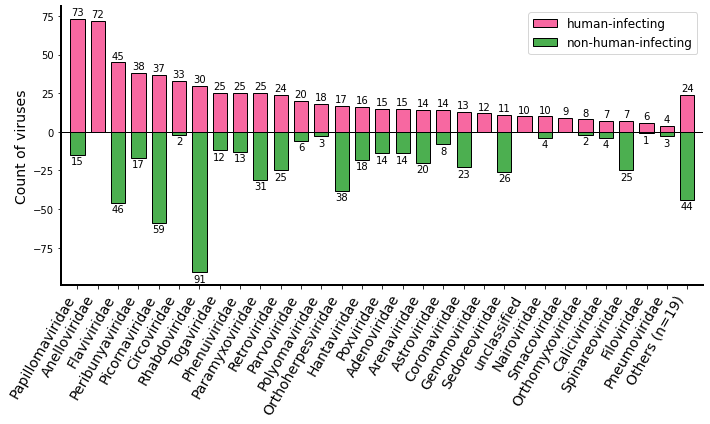

In [20]:
def barplot_virus_family_combined():
    import warnings
    warnings.filterwarnings("ignore")

    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

    # =====================================================
    # ① 读取 human-infecting（high + middle）
    # =====================================================
    dt_conf = pd.read_excel(
        "../../tables_and_figs_updated/Table S2_update.xlsx",
        sheet_name="Table S2",
        header=1
    )
    dt_conf.rename(columns={"Evidence level": "confidence level", "Family": "virus family"}, inplace=True)

    dt_conf = dt_conf[
        dt_conf["confidence level"].isin(["high", "middle"])
    ].reset_index(drop=True)

    dt_conf["Label_text"] = "human-infecting"

    # =====================================================
    # ② 读取 non-human-infecting
    # =====================================================
    dt_full = pd.read_csv(
        "../../data/AllDataIdMapping_update.csv",
        sep="\t", header=0, dtype=str
    )

    # 病毒科映射
    dict_vtaxid2vfam = {}
    with open("../../data/1284virusTaxnomy.txt") as inF:
        for line in inF:
            line = line.strip().split("\t")
            vtaxid = line[0]
            vfam = None
            for tax_str in line[2].split(";"):
                if tax_str.endswith("viridae"):
                    vfam = tax_str
            dict_vtaxid2vfam[vtaxid] = vfam

    dt_full["vfam"] = [dict_vtaxid2vfam.get(tid) for tid in dt_full["Taxid"]]
    dt_full["Label_text"] = dt_full["label_update"].map(
        {"0": "non-human-infecting", "1": "human-infecting"}
    )

    dt_non = dt_full[
        dt_full["Label_text"] == "non-human-infecting"
    ].copy()

    # =====================================================
    # ③ 按病毒科统计
    # =====================================================
    df_inf = (
        dt_conf
        .groupby("virus family")
        .size()
        .rename("human_infecting")
    )

    df_non = (
        dt_non
        .groupby("vfam")
        .size()
        .rename("non_human_infecting")
    )

    df_merge = (
        pd.concat([df_inf, df_non], axis=1)
        .fillna(0)
        .astype(int)
    )

    # =====================================================
    # 只保留前 30，其余合并为 Other
    # =====================================================
    df_merge = df_merge.sort_values(
        "human_infecting", ascending=False
    )

    top_n = 30
    df_top = df_merge.iloc[:top_n].copy()
    df_other = df_merge.iloc[top_n:].copy()

    if len(df_other) > 0:
        other_row = pd.DataFrame(
            {
                "human_infecting": [df_other["human_infecting"].sum()],
                "non_human_infecting": [df_other["non_human_infecting"].sum()],
            },
            index=[f"Others (n={len(df_other)})"]
        )
        df_plot = pd.concat([df_top, other_row])
    else:
        df_plot = df_top.copy()

    families = df_plot.index.tolist()
    inf_vals = df_plot["human_infecting"].values
    non_vals = df_plot["non_human_infecting"].values

    x = np.arange(len(families))

    # =====================================================
    # ④ 颜色
    # =====================================================
    colors = {
        "human-infecting": "#f768a1",
        "non-human-infecting": "#4CAF50"
    }

    # =====================================================
    # ⑤ 绘图
    # =====================================================
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(
        x,
        inf_vals,
        color=colors["human-infecting"],
        edgecolor="black",
        label="human-infecting",
        width=0.7
    )

    ax.bar(
        x,
        -non_vals,
        color=colors["non-human-infecting"],
        edgecolor="black",
        label="non-human-infecting",
        width=0.7
    )

    # =====================================================
    # ⑥ 数字标注
    # =====================================================
    offset = 1

    for i, v in enumerate(inf_vals):
        if v > 0:
            ax.text(
                x[i], v + offset, str(int(v)),
                ha="center", va="bottom", fontsize=10
            )

    for i, v in enumerate(non_vals):
        if v > 0:
            ax.text(
                x[i], -(v + offset), str(int(v)),
                ha="center", va="top", fontsize=10
            )

    ax.axhline(0, color="black", linewidth=1)

    # =====================================================
    # ⑦ 发表级样式
    # =====================================================
    ax.set_xlim(-0.8, len(families) - 0.2)

    ax.set_xticks(x)
    ax.set_xticklabels(
        families, rotation=60, ha="right", fontsize=14
    )

    ax.set_ylabel("Count of viruses", fontsize=14)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.legend(fontsize=12, loc="upper right")

    plt.tight_layout()

    plt.savefig(
        "../../tables_and_figs_updated/fig2b_update.pdf",
        dpi=300, format="pdf",
        bbox_inches="tight", pad_inches=0.1
    )

    plt.show()


if __name__ == "__main__":
    barplot_virus_family_combined()


(643, 3) (543, 3)
     Taxid  ppi_count           Label_text   log_ppi
0  1002359       1403  non-human-infecting  3.147367
1  1002360       1361  non-human-infecting  3.134177
2    10245      24363      human-infecting  4.386749


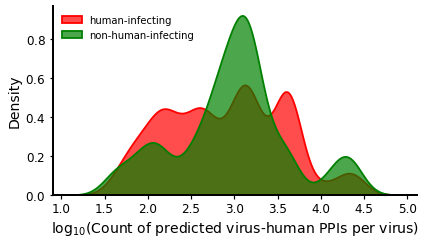

In [14]:
## Fig. 2C

def show_ppi_virus_density():
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.ticker as mticker
    import numpy as np

    # ======== 读取数据 ========
    df = pd.read_csv("../../data_updated/all_pred_ppis_final.csv", sep="\t", header=0, dtype=str)
    df_xx = pd.read_csv("./xx.csv", dtype=str)
    df = df[df["Taxid"].isin(df_xx["Taxid"].tolist())].reset_index(drop=True)

    # ======== 读取标签文件（区分human-infecting与non-human-infecting） ========
    dt3 = pd.read_excel("../../tables_and_figs_updated/Table S3_update.xlsx", sheet_name="Table S3", header=1, dtype=str)
    df = df[df["Taxid"].isin(set(dt3["Taxid"]))].reset_index(drop=True)

    # ======== 取出感染类型列表 ========
    taxid_label_map = dict(zip(dt3["Taxid"], dt3["Label_text"]))

    # ======== Before & After 数据集（这里只画 Before 的分布） ========
    df_before = df.copy()

    # ======== 计算每个病毒的 PPI 数量 ========
    df_before_counts = df_before.groupby("Taxid").size().reset_index(name="ppi_count")
    df_before_counts["Label_text"] = df_before_counts["Taxid"].map(taxid_label_map)

    df_hv = df_before_counts[df_before_counts["Label_text"]=="human-infecting"].reset_index(drop=True)
    df_nhv = df_before_counts[df_before_counts["Label_text"]=="non-human-infecting"].reset_index(drop=True)
    print(df_hv.shape, df_nhv.shape)

    # ======== 删除缺失标签（如部分taxid在标签表中不存在） ========
    df_before_counts = df_before_counts.dropna(subset=["Label_text"])

    # ======== 对ppi_count取log10变换 ========
    df_before_counts["log_ppi"] = np.log10(df_before_counts["ppi_count"] + 1)
    print(df_before_counts.head(3))

    # ======== 绘图 ========
    plt.figure(figsize=(6, 3.5))
    sns.kdeplot(
        data=df_before_counts[df_before_counts["Label_text"] == "human-infecting"],
        x="log_ppi",
        fill=True,
        color="red",
        alpha=0.7,
        linewidth=1.8,
        label="human-infecting",
        bw_adjust=0.8
    )

    sns.kdeplot(
        data=df_before_counts[df_before_counts["Label_text"] == "non-human-infecting"],
        x="log_ppi",
        fill=True,
        color="green",
        alpha=0.7,
        linewidth=1.8,
        label="non-human-infecting",
        bw_adjust=0.8
    )

    # ======== 坐标轴与外观设置 ========
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="both", labelsize=12, width=1.2)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))

    plt.xlabel("log$_{10}$(Count of predicted virus-human PPIs per virus)", fontsize=14)
    plt.ylabel("Density", fontsize=14)
    plt.legend(loc="upper left", frameon=False, fontsize=10)
    plt.tight_layout()
    
    plt.savefig(
        "../../tables_and_figs_updated/fig2c_update.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.1,
    )
    
    plt.show()


if __name__ == "__main__":
    show_ppi_virus_density()


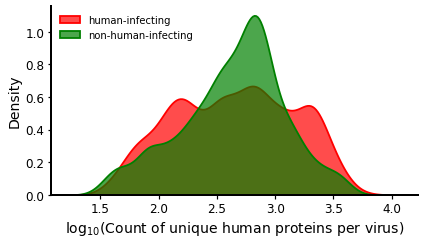

In [15]:
def density_unique_human_proteins():
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # ======== 读取数据 ========
    df = pd.read_csv("../../data_updated/all_pred_ppis_final.csv", sep="\t", header=0, dtype=str)
    df_xx = pd.read_csv("./xx.csv", dtype=str)
    df = df[df["Taxid"].isin(df_xx["Taxid"].tolist())].reset_index(drop=True)

    # ======== 读取标签文件（区分human-infecting与non-human-infecting） ========
    dt3 = pd.read_excel("../../tables_and_figs_updated/Table S3_update.xlsx", sheet_name="Table S3", header=1, dtype=str)
    df = df[df["Taxid"].isin(set(dt3["Taxid"]))].reset_index(drop=True)

    # ======== 取出感染类型列表 ========
    taxid_label_map = dict(zip(dt3["Taxid"], dt3["Label_text"]))

    # =====================================================
    # 3. 每个病毒互作到的 unique human proteins 数量
    # =====================================================
    df_unique = (
        df
        .drop_duplicates(subset=["Taxid", "human_unid"])
        .groupby("Taxid")["human_unid"]
        .nunique()
        .reset_index(name="count_human_proteins")
    )

    # 添加标签
    df_unique["Label_text"] = df_unique["Taxid"].map(taxid_label_map)

    # 去掉没有标签的
    df_unique = df_unique.dropna(subset=["Label_text"])

    # =====================================================
    # 4. log10 转换
    # =====================================================
    df_unique["log10_count"] = np.log10(
        df_unique["count_human_proteins"] + 1
    )

    # =====================================================
    # 5. KDE 密度图
    # =====================================================
    plt.figure(figsize=(6, 3.5))

    sns.kdeplot(
        data=df_unique[df_unique["Label_text"] == "human-infecting"],
        x="log10_count",
        fill=True,
        color="red",
        alpha=0.7,
        linewidth=1.8,
        bw_adjust=0.8,
        label="human-infecting"
    )

    sns.kdeplot(
        data=df_unique[df_unique["Label_text"] == "non-human-infecting"],
        x="log10_count",
        fill=True,
        color="green",
        alpha=0.7,
        linewidth=1.8,
        bw_adjust=0.8,
        label="non-human-infecting"
    )

    # =====================================================
    # 6. 发表级样式
    # =====================================================
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="both", labelsize=12, width=1.2)

    plt.xlabel(
        "log$_{10}$(Count of unique human proteins per virus)",
        fontsize=14
    )
    plt.ylabel("Density", fontsize=14)

    plt.legend(loc="upper left", frameon=False, fontsize=10)
    plt.tight_layout()

    # =====================================================
    # 7. 保存
    # =====================================================
    plt.savefig(
        "../../tables_and_figs_updated/fig2d_update.pdf",
        dpi=300,
        format="pdf",
        bbox_inches="tight",
        pad_inches=0.1
    )

    plt.show()


if __name__ == "__main__":
    density_unique_human_proteins()


rf: top=1000, auc=0.823
svm: top=1050, auc=0.812
knn: top=1300, auc=0.798
xgboost: top=550, auc=0.808


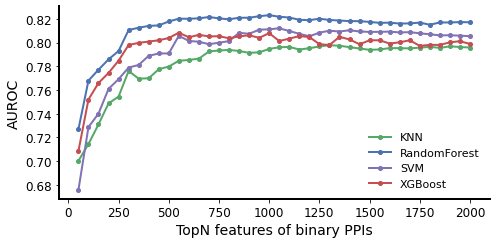

In [2]:
## Fig. 2E

import pandas as pd
import matplotlib.pyplot as plt
import os

def read_val_csv(infile):
    dt = pd.read_csv(infile, sep=",", header=0)
    return dt["auroc"].iloc[0]

def select_topN_features_on_mydataset():
    # 读取Excel文件
    ml_list = ["rf", "svm", "knn", "xgboost"]
    #ml_list = ["rf", "svm", "knn"]
    df = []
    for ml in ml_list:
        for topn in range(50, 2050, 50):
            try:
                auroc_value = read_val_csv(infile=f"../../mid_result_updated/val/ppi/{ml}_top{topn}_summary_val.csv")
            except:
                auroc_value = read_val_csv(infile=f"../../mid_result_updated/val/ppi/{ml}_top{topn}_summary_val_repeat10.csv")
            df.append([ml, topn, auroc_value])
    df = pd.DataFrame(df, columns=["ml","top","auc"])
    df_wide = (df.pivot(index="top", columns="ml", values="auc").reset_index().rename(columns={ml: f"{ml}_auc" for ml in ml_list}))
    df_wide.columns.name = None

    ## 返回每种方法对应的topN和AUC最大值
    for ml in ml_list:
        col = f"{ml}_auc"
        idx = df_wide[col].idxmax()
        top_val = df_wide.loc[idx, "top"]
        max_val = round(df_wide.loc[idx, col], 3)
        print(f"{ml}: top={top_val}, auc={max_val}")
    
    # 设置画布大小
    plt.figure(figsize=(7,3.5))
    
    # 图例映射字典
    label_map = {
        "RF": "RandomForest",
        "XGBOOST": "XGBoost",
        "KNN": "KNN",
        "SVM": "SVM"
    }
    
    # 科研 风格配色
    colors = {
        "RF": "#4C72B0",      # 蓝
        "XGBOOST": "#C44E52", # 红
        "KNN": "#55A868",     # 绿
        "SVM": "#8172B3"      # 紫
    }
    
    # 绘制每一列（除了top列）对应的折线图
    for col in df_wide.columns[1:]:
        name = col.replace('_auc', '').upper()
        label = label_map.get(name, name)
        plt.plot(
            df_wide['top'], df_wide[col], marker='o',
            label=label, markersize=4, linewidth=2,
            color=colors.get(name, None)  # 使用配色
        )
    
    # 设置坐标轴标签和标题
    plt.xlabel('TopN features of binary PPIs', fontsize=14)
    plt.ylabel('AUROC', fontsize=14)
    
    # 调大刻度字体
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # 去掉上方和右侧的框线，加粗左侧和下方
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    
    # 图例字体调大
    plt.legend(fontsize=11, frameon=False)  # 去掉图例边框
    
    plt.tight_layout()

    plt.savefig("../../tables_and_figs_updated/fig2e_update.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    select_topN_features_on_mydataset()


rf: top=1000, auc=0.823
svm: top=1050, auc=0.812
knn: top=1300, auc=0.798
xgboost: top=1000, auc=0.811


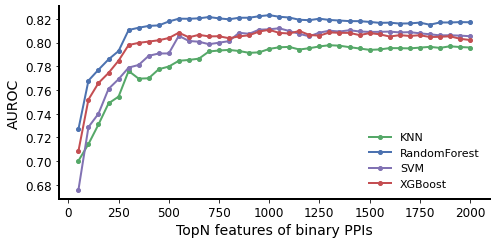

In [2]:
## Fig. 2E

import pandas as pd
import matplotlib.pyplot as plt
import os

def read_val_csv(infile):
    dt = pd.read_csv(infile, sep=",", header=0)
    return dt["auroc"].iloc[0]

def select_topN_features_on_mydataset():
    # 读取Excel文件
    ml_list = ["rf", "svm", "knn", "xgboost"]
    df = []
    for ml in ml_list:
        for topn in range(50, 2050, 50):
            auroc_value = read_val_csv(infile=f"../../mid_result_updated/val/ppi/{ml}_top{topn}_summary_val.csv")
            df.append([ml, topn, auroc_value])
    df = pd.DataFrame(df, columns=["ml","top","auc"])
    df_wide = (df.pivot(index="top", columns="ml", values="auc").reset_index().rename(columns={ml: f"{ml}_auc" for ml in ml_list}))
    df_wide.columns.name = None

    ## 返回每种方法对应的topN和AUC最大值
    for ml in ml_list:
        col = f"{ml}_auc"
        idx = df_wide[col].idxmax()
        top_val = df_wide.loc[idx, "top"]
        max_val = round(df_wide.loc[idx, col], 3)
        print(f"{ml}: top={top_val}, auc={max_val}")
    
    # 设置画布大小
    plt.figure(figsize=(7,3.5))
    
    # 图例映射字典
    label_map = {
        "RF": "RandomForest",
        "XGBOOST": "XGBoost",
        "KNN": "KNN",
        "SVM": "SVM"
    }
    
    # 科研 风格配色
    colors = {
        "RF": "#4C72B0",      # 蓝
        "XGBOOST": "#C44E52", # 红
        "KNN": "#55A868",     # 绿
        "SVM": "#8172B3"      # 紫
    }
    
    # 绘制每一列（除了top列）对应的折线图
    for col in df_wide.columns[1:]:
        name = col.replace('_auc', '').upper()
        label = label_map.get(name, name)
        plt.plot(
            df_wide['top'], df_wide[col], marker='o',
            label=label, markersize=4, linewidth=2,
            color=colors.get(name, None)  # 使用配色
        )
    
    # 设置坐标轴标签和标题
    plt.xlabel('TopN features of binary PPIs', fontsize=14)
    plt.ylabel('AUROC', fontsize=14)
    
    # 调大刻度字体
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # 去掉上方和右侧的框线，加粗左侧和下方
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    
    # 图例字体调大
    plt.legend(fontsize=11, frameon=False)  # 去掉图例边框
    
    plt.tight_layout()

    plt.savefig("../../tables_and_figs_updated/fig2e_update.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    select_topN_features_on_mydataset()


In [ ]:
## Fig.2F

def return_metric(infile, colname):
    import pandas as pd
    dt = pd.read_csv(infile, sep=",", header=0)
    dt_acc   = dt.loc[:, "accuracy"].copy()
    dt_auroc = dt.loc[:, "auroc"].copy()
    dt_auprc = dt.loc[:, "auprc"].copy()

    dt_res = pd.DataFrame({
        "Metric": ["Accuracy"]*dt.shape[0] + ["AUROC"]*dt.shape[0] + ["AUPRC"]*dt.shape[0],
        colname:  list(dt_acc.values) + list(dt_auroc.values) + list(dt_auprc.values),
    })
    return dt_res



def boxplot_multi_metrics():
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import ttest_ind
    import numpy as np
    
    dt_res_genome   = return_metric("../../mid_result_updated/test/genome/knn_result_3mer.csv",  "Genome-3mer-KNN")
    dt_res_proteome = return_metric("../../mid_result_updated/test/proteome/rf_result_esm2.csv", "Proteome-esm2-RF")
    dt_res_ppi = return_metric("../../mid_result_updated/test/ppi/rf_top1000_result_val.csv", "PPI-Top1000-RF")

    df = dt_res_genome.merge(dt_res_proteome,   on="Metric", how="left")
    df = df.merge(dt_res_ppi, on="Metric", how="left")
    print(df.head(3))

    metrics = ["Accuracy", "AUROC", "AUPRC"]
    methods = ["Genome-3mer-KNN", "Proteome-esm2-RF", "PPI-Top1000-RF"]

    print(df.groupby("Metric").mean())
    
    colors = {
        "Genome-3mer-KNN": "#4C72B0",
        "Proteome-esm2-RF": "#55A868",
        "PPI-Top1000-RF": "#C44E52"
    }

    df_long = df.melt(id_vars=["Metric"], value_vars=methods,
                      var_name="Method", value_name="Value")

    plt.figure(figsize=(6, 3.5))

    # ---------------- Boxplot ----------------
    sns.boxplot(
        data=df_long,
        x="Metric", y="Value",
        hue="Method", hue_order=methods,
        order=metrics,
        width=0.85,
        gap=0.5,
        dodge=True,
        showcaps=True,
        showfliers=False,
        boxprops=dict(edgecolor="black", facecolor="white", linewidth=2),
        whiskerprops=dict(color="black", linewidth=2),
        capprops=dict(color="black", linewidth=2),
        medianprops=dict(color="black", linewidth=2)
    )

    # ---------------- Stripplot ----------------
    scatter = sns.stripplot(
        data=df_long,
        x="Metric", y="Value",
        hue="Method", hue_order=methods,
        order=metrics,
        dodge=True,
        jitter=True,
        size=4,
        alpha=0.75,
        palette=colors
    )
    scatter.legend_.remove()

    # ---------------- Significance ----------------
    p_values = {}
    y_max = df_long["Value"].max()

    # 调整显著性整体下移
    ##height = (y_max - df_long["Value"].min()) * 0.06   # 原来 0.10 → 更接近箱线图
    ##line_gap = 0.025                                   # 原来 0.04 → 更紧凑
    ##star_shift = 0.002                                # 星号也向下移一点

    height     = (y_max - df_long["Value"].min()) * 0.03   # 0.06 → 0.03
    line_gap   = 0.02                                       # 略缩
    star_shift = 0.000                                      # 不再上抬

    offsets = {
        "Genome-3mer-KNN": -0.30,
        "Proteome-esm2-RF": 0.00,
        "PPI-Top1000-RF": 0.30
    }

    for j, metric in enumerate(metrics):
        sub = df[df["Metric"] == metric]

        vals_genome = sub["Genome-3mer-KNN"].dropna()
        vals_prot   = sub["Proteome-esm2-RF"].dropna()
        vals_ppi    = sub["PPI-Top1000-RF"].dropna()

        p1 = ttest_ind(vals_genome, vals_ppi)[1]
        p2 = ttest_ind(vals_prot, vals_ppi)[1]

        p_values[(metric, "Genome_vs_PPI")] = p1
        p_values[(metric, "Proteome_vs_PPI")] = p2

        x_genome = j + offsets["Genome-3mer-KNN"]
        x_prot   = j + offsets["Proteome-esm2-RF"]
        x_ppi    = j + offsets["PPI-Top1000-RF"]

        # ----- Genome vs PPI -----
        y1 = y_max + (j+1) * height        # 线整体更靠近箱线图
        plt.plot([x_genome, x_genome, x_ppi, x_ppi],
                 [y1, y1+0.002, y1+0.002, y1],
                 lw=2, color="black")

        star = "***" if p1 < 0.001 else ("**" if p1 < 0.01 else ("*" if p1 < 0.05 else "ns"))
        plt.text((x_genome + x_ppi) / 2, y1 + 0.0025 + star_shift,
                 star, ha="center", fontsize=10, fontweight="bold")

        # ----- Proteome vs PPI -----
        y2 = y1 + line_gap
        plt.plot([x_prot, x_prot, x_ppi, x_ppi],
                 [y2, y2+0.002, y2+0.002, y2],
                 lw=2, color="black")

        star2 = "***" if p2 < 0.001 else ("**" if p2 < 0.01 else ("*" if p2 < 0.05 else "ns"))
        plt.text((x_prot + x_ppi) / 2, y2 + 0.0025 + star_shift,
                 star2, ha="center", fontsize=10, fontweight="bold")

    # ---------------- Figure Style ----------------
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    plt.xlabel("")
    plt.ylabel("Value", fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # ---------------- Legend ----------------
    handles, labels = scatter.get_legend_handles_labels()
    plt.legend(
        handles[3:], labels[3:],
        title=None,
        fontsize=10,
        loc="lower right",
        ncol=1
    )

    plt.tight_layout()

    plt.savefig("../../tables_and_figs_updated/fig2f_update.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距

    plt.savefig("../../tables_and_figs_updated/fig2f_update.png",
            format="png", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()

    ## ---------------- p-values ----------------
    print("\n========== P-values ==========")
    for key, val in p_values.items():
        print(f"{key[0]}  |  {key[1]} = {val}")
    

if __name__ == "__main__":
    boxplot_multi_metrics()


     Metric  Genome-3mer-KNN  Proteome-esm2-RF  PPI-Top1000-RF
0  Accuracy         0.770053          0.759358        0.780749
1  Accuracy         0.770053          0.759358        0.770053
2  Accuracy         0.770053          0.759358        0.732620
          Genome-3mer-KNN  Proteome-esm2-RF  PPI-Top1000-RF
Metric                                                     
AUPRC            0.834931          0.816249        0.860675
AUROC            0.789310          0.781537        0.830245
Accuracy         0.723209          0.715989        0.748503


KeyboardInterrupt: 

     Metric  Genome-3mer-KNN  Proteome-esm2-RF  PPI-Top1000-RF
0  Accuracy         0.770053          0.759358        0.780749
1  Accuracy         0.770053          0.759358        0.770053
2  Accuracy         0.770053          0.759358        0.732620

========== Mean values ==========
          Genome-3mer-KNN  Proteome-esm2-RF  PPI-Top1000-RF
Metric                                                     
Accuracy         0.723209          0.715989        0.748503
AUROC            0.789310          0.781537        0.830245
AUPRC            0.834931          0.816249        0.860675


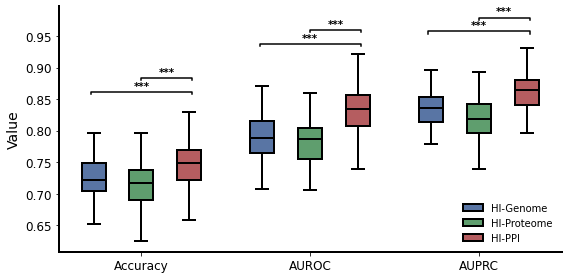

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Fig. 2F
# ============================================================

def return_metric(infile, colname):
    """
    Read model performance results and convert them into
    Accuracy, AUROC, and AUPRC format.
    """
    dt = pd.read_csv(infile, sep=",", header=0)

    dt_acc = dt.loc[:, "accuracy"].copy()
    dt_auroc = dt.loc[:, "auroc"].copy()
    dt_auprc = dt.loc[:, "auprc"].copy()

    dt_res = pd.DataFrame({
        "Metric":
            ["Accuracy"] * dt.shape[0]
            + ["AUROC"] * dt.shape[0]
            + ["AUPRC"] * dt.shape[0],

        colname:
            list(dt_acc.values)
            + list(dt_auroc.values)
            + list(dt_auprc.values),
    })

    return dt_res


def boxplot_multi_metrics():

    # ========================================================
    # 1. Read data
    # ========================================================

    dt_res_genome = return_metric(
        "../../mid_result_updated/test/genome/knn_result_3mer.csv",
        "Genome-3mer-KNN"
    )

    dt_res_proteome = return_metric(
        "../../mid_result_updated/test/proteome/rf_result_esm2.csv",
        "Proteome-esm2-RF"
    )

    dt_res_ppi = return_metric(
        "../../mid_result_updated/test/ppi/rf_top1000_result_val.csv",
        "PPI-Top1000-RF"
    )

    # ========================================================
    # 2. Merge data
    # ========================================================

    df = dt_res_genome.merge(
        dt_res_proteome,
        on="Metric",
        how="left"
    )

    df = df.merge(
        dt_res_ppi,
        on="Metric",
        how="left"
    )

    print(df.head(3))

    # ========================================================
    # 3. Define plotting order
    # ========================================================

    metrics = [
        "Accuracy",
        "AUROC",
        "AUPRC"
    ]

    methods = [
        "Genome-3mer-KNN",
        "Proteome-esm2-RF",
        "PPI-Top1000-RF"
    ]

    print("\n========== Mean values ==========")
    print(
        df.groupby("Metric")[methods]
        .mean()
        .reindex(metrics)
    )

    # ========================================================
    # 4. Colors
    # ========================================================

    colors = {
        "Genome-3mer-KNN": "#4C72B0",
        "Proteome-esm2-RF": "#55A868",
        "PPI-Top1000-RF": "#C44E52"
    }

    # ========================================================
    # 5. Convert to long format
    # ========================================================

    df_long = df.melt(
        id_vars=["Metric"],
        value_vars=methods,
        var_name="Method",
        value_name="Value"
    )

    # ========================================================
    # 6. Plot boxplots
    # ========================================================

    plt.figure(figsize=(8, 4))

    ax = sns.boxplot(
        data=df_long,
        x="Metric",
        y="Value",
        hue="Method",

        order=metrics,
        hue_order=methods,

        palette=colors,

        width=0.85,
        gap=0.5,
        dodge=True,

        showcaps=True,
        showfliers=False,

        boxprops=dict(
            edgecolor="black",
            linewidth=2
        ),

        whiskerprops=dict(
            color="black",
            linewidth=2
        ),

        capprops=dict(
            color="black",
            linewidth=2
        ),

        medianprops=dict(
            color="black",
            linewidth=2
        )
    )

    # ========================================================
    # 7. Add significance labels
    #    Genome vs PPI: ***
    #    Proteome vs PPI: ***
    # ========================================================

    # Three box positions within each metric
    offsets = {
        "Genome-3mer-KNN": -0.30,
        "Proteome-esm2-RF": 0.00,
        "PPI-Top1000-RF": 0.30
    }

    data_min = df_long["Value"].min()
    data_max = df_long["Value"].max()
    data_range = data_max - data_min

    # Distance above highest observed value
    first_gap = data_range * 0.04

    # Distance between the two significance bars
    line_gap = data_range * 0.07

    # Height of vertical ends of significance bars
    bracket_height = data_range * 0.012

    # Distance between *** and horizontal line
    star_gap = data_range * 0.005

    for j, metric in enumerate(metrics):

        # Use the maximum value of the current metric
        metric_max = df_long.loc[
            df_long["Metric"] == metric,
            "Value"
        ].max()

        x_genome = j + offsets["Genome-3mer-KNN"]
        x_proteome = j + offsets["Proteome-esm2-RF"]
        x_ppi = j + offsets["PPI-Top1000-RF"]

        # ----------------------------------------------------
        # Genome vs PPI
        # ----------------------------------------------------

        y1 = metric_max + first_gap

        ax.plot(
            [x_genome, x_genome, x_ppi, x_ppi],
            [
                y1,
                y1 + bracket_height,
                y1 + bracket_height,
                y1
            ],
            lw=1.5,
            color="black"
        )

        ax.text(
            (x_genome + x_ppi) / 2,
            y1 + bracket_height + star_gap,
            "***",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

        # ----------------------------------------------------
        # Proteome vs PPI
        # ----------------------------------------------------

        y2 = y1 + line_gap

        ax.plot(
            [x_proteome, x_proteome, x_ppi, x_ppi],
            [
                y2,
                y2 + bracket_height,
                y2 + bracket_height,
                y2
            ],
            lw=1.5,
            color="black"
        )

        ax.text(
            (x_proteome + x_ppi) / 2,
            y2 + bracket_height + star_gap,
            "***",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    # ========================================================
    # 8. Figure style
    # ========================================================

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.set_xlabel("")
    ax.set_ylabel(
        "Value",
        fontsize=14
    )

    ax.tick_params(
        axis="x",
        labelsize=12
    )

    ax.tick_params(
        axis="y",
        labelsize=12
    )

    # ========================================================
    # 9. Adjust y-axis to leave room for significance labels
    # ========================================================

    current_bottom, current_top = ax.get_ylim()

    required_top = (
        data_max
        + first_gap
        + line_gap
        + bracket_height
        + star_gap
        + data_range * 0.04
    )

    ax.set_ylim(
        current_bottom,
        max(current_top, required_top)
    )

    # ========================================================
    # 10. Legend
    # ========================================================

    handles, labels = ax.get_legend_handles_labels()

    legend_labels = {
        "Genome-3mer-KNN": "HI-Genome",
        "Proteome-esm2-RF": "HI-Proteome",
        "PPI-Top1000-RF": "HI-PPI"
    }

    new_labels = [legend_labels[label] for label in labels]

    ax.legend(
        handles,
        new_labels,
        title=None,
        fontsize=10,
        loc="lower right",
        ncol=1,
        frameon=False
    )

    # ========================================================
    # 11. Layout
    # ========================================================

    plt.tight_layout()

    # ========================================================
    # 12. Save figure
    # ========================================================

    plt.savefig(
        "../../tables_and_figs_updated/fig2f_update.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.1
    )
    
    plt.show()


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    boxplot_multi_metrics()

In [14]:
def return_metric(infile, colname):
    import pandas as pd
    dt = pd.read_csv(infile, sep=",", header=0)
    dt_acc   = dt.loc[:, "accuracy"].copy()
    dt_prec  = dt.loc[:, "precision"].copy()
    dt_recal = dt.loc[:, "recall"].copy()
    dt_f1s   = dt.loc[:, "f1"].copy()
    dt_auroc = dt.loc[:, "auroc"].copy()
    dt_auprc = dt.loc[:, "auprc"].copy()

    dt_res = pd.DataFrame({
        "Metric": ["Accuracy"]*dt.shape[0] + ["Precision"]*dt.shape[0] + ["Recall"]*dt.shape[0] + ["F1-Score"]*dt.shape[0] + ["AUROC"]*dt.shape[0] + ["AUPRC"]*dt.shape[0],
        colname:  list(dt_acc.values) + list(dt_prec.values) + list(dt_recal.values) + list(dt_f1s.values) + list(dt_auroc.values) + list(dt_auprc.values),
    })
    return dt_res



def table_multi_metrics():
    import pandas as pd
    
    dt_res_genome   = return_metric("../../mid_result_updated/test/genome/knn_result_3mer.csv",  "Genome-3mer-KNN")
    dt_res_proteome = return_metric("../../mid_result_updated/test/proteome/rf_result_esm2.csv", "Proteome-esm2-RF")
    dt_res_ppi = return_metric("../../mid_result_updated/test/ppi/rf_top1000_result_val.csv", "PPI-Top1000-RF")

    df = dt_res_genome.merge(dt_res_proteome,   on="Metric", how="left")
    df = df.merge(dt_res_ppi, on="Metric", how="left")
    print(df.groupby("Metric").mean().round(3))
    



if __name__ == "__main__":
    table_multi_metrics()

           Genome-3mer-KNN  Proteome-esm2-RF  PPI-Top1000-RF
Metric                                                      
AUPRC                0.835             0.816           0.861
AUROC                0.789             0.782           0.830
Accuracy             0.723             0.716           0.749
F1-Score             0.753             0.744           0.771
Precision            0.734             0.732           0.767
Recall               0.774             0.758           0.776


In [6]:
import pandas as pd


def topK_important_genes():

    # 读取100次划分下的特征重要性
    importance = pd.read_csv("../../mid_result_updated/val/rf_feature_importances_100_for_ppi.csv")

    # 计算每个特征在100次划分中的平均重要性
    mean_importance = importance.mean()

    # 取重要性最高的1000个基因
    dt_topK_genes = (
        mean_importance
        .sort_values(ascending=False)
        .head(1000)
        .reset_index()
    )

    # 设置列名
    dt_topK_genes.columns = ["unid", "shap_value"]

    # 保存
    dt_topK_genes.to_csv(
        "../../data_updated/top1000_genes_for_enrichment.csv",
        index=False
    )

    print(dt_topK_genes.head(3))


if __name__ == "__main__":
    topK_important_genes()

     unid  shap_value
0  P15880    0.003948
1  P0CG47    0.003587
2  P68431    0.003139


In [ ]:
##====== Fig. 2G,H GO-BP term clusters related to viral processes (G) OR immune processes (H) among the top 450 human proteins contributing to infectivity prediction ======##

## see codeForFig2EF.R

## Fig. 3 Comparison of PPI- and Sequence-based models for predicting transmissibility, transmission route, and tissue tropism of RNA viruses.

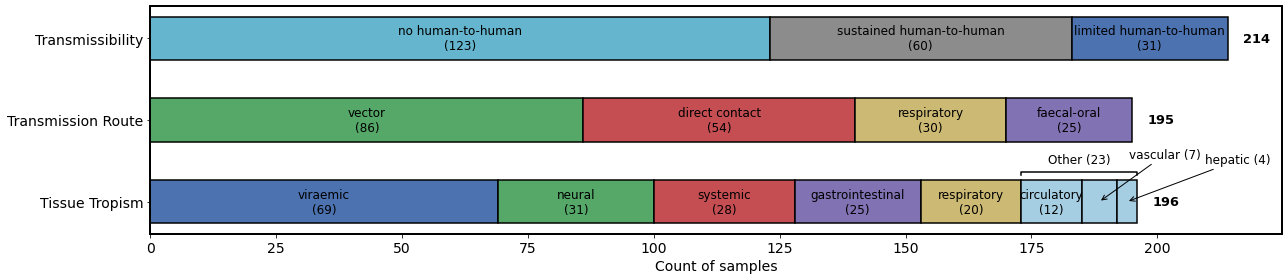

In [ ]:
## Fig.3A

import pandas as pd
import matplotlib.pyplot as plt
import textwrap

def show_data_components():
    # 读取数据
    dt = pd.read_excel("../../data/data_components.xlsx", sheet_name="data_components", header=0)
    dt = dt[dt["Group"]!="Virulence"].reset_index(drop=True)

    # 替换 Infectivity → Transmissibility
    dt["Group"] = dt["Group"].replace({"Infectivity": "Transmissibility"})

    # Group 内部 Count 从大到小
    dt = dt.sort_values(by=["Group", "Count"], ascending=[True, False])

    # 计算每个 Group 的总数
    group_totals = dt.groupby("Group")["Count"].sum()
    
    # ========== 颜色设置（Nature风格） ==========
    nature_colors = [
        "#4C72B0",  # 蓝
        "#55A868",  # 绿
        "#C44E52",  # 红
        "#8172B3",  # 紫
        "#CCB974",  # 黄褐
        "#64B5CD",  # 青蓝
        "#8C8C8C"   # 灰
    ]

    label_colors = {}
    color_idx = 0
    for _, row in dt.iterrows():
        group = row["Group"]
        label = row["Label"]
        if group == "Tissue Tropism" and label in ["circulatory", "vascular", "hepatic"]:
            label_colors[label] = "#a6cee3"  # 特殊浅蓝色
        else:
            if label not in label_colors:
                label_colors[label] = nature_colors[color_idx % len(nature_colors)]
                color_idx += 1

    # ========== 绘图 ==========
    fig, ax = plt.subplots(figsize=(18, 4))

    # 固定顺序
    groups_order = ["Tissue Tropism", "Transmission Route", "Transmissibility"]
    groups = [g for g in groups_order if g in dt["Group"].unique()]
    y_positions = {g: i*1.5 for i, g in enumerate(groups)}
    bottoms = {g: 0 for g in groups}

    # 保存 circulatory/vascular/hepatic 的区间范围
    special_xmin, special_xmax, special_sum = None, None, 0

    for _, row in dt.iterrows():
        group = row["Group"]
        label = row["Label"]
        count = row["Count"]

        ax.barh(y_positions[group], count, left=bottoms[group],
                edgecolor="black", linewidth=1.5, color=label_colors[label])

        # circulatory 保留在柱子内部显示
        if not (group == "Tissue Tropism" and label in ["vascular", "hepatic"]):
            wrapped_label = "\n".join(textwrap.wrap(label, width=30))
            ax.text(
                bottoms[group] + count / 2,
                y_positions[group],
                f"{wrapped_label}\n({count})",
                ha="center", va="center", fontsize=12, color="black"
            )

        if group == "Tissue Tropism" and label in ["circulatory", "vascular", "hepatic"]:
            if special_xmin is None:
                special_xmin = bottoms[group]
            special_xmax = bottoms[group] + count
            special_sum += count

        bottoms[group] += count

    # 在柱子顶端写总数
    for group, total in group_totals.items():
        ax.text(
            total + 3, y_positions[group], str(total),
            ha="left", va="center", fontsize=13, fontweight="bold"
        )

    # ========== 特殊 annotation ==========
    vascular_row = dt[(dt["Group"]=="Tissue Tropism") & (dt["Label"]=="vascular")].iloc[0]
    hepatic_row = dt[(dt["Group"]=="Tissue Tropism") & (dt["Label"]=="hepatic")].iloc[0]

    vascular_x = group_totals["Tissue Tropism"] - hepatic_row["Count"] - vascular_row["Count"]/2
    hepatic_x = group_totals["Tissue Tropism"] - hepatic_row["Count"]/2
    y_tissue = y_positions["Tissue Tropism"]

    ax.annotate(
        f"vascular ({vascular_row['Count']})",
        xy=(vascular_x, y_tissue),
        xytext=(vascular_x+13, (y_positions["Tissue Tropism"]+y_positions["Transmissibility"])/2-0.7),
        ha="center", fontsize=12,
        arrowprops=dict(arrowstyle="->", lw=1)
    )

    ax.annotate(
        f"hepatic ({hepatic_row['Count']})",
        xy=(hepatic_x, y_tissue),
        xytext=(hepatic_x+22, (y_positions["Tissue Tropism"]+y_positions["Transmissibility"])/2-0.8),
        ha="center", fontsize=12,
        arrowprops=dict(arrowstyle="->", lw=1)
    )

    # ========== 括号 + Other ==========
    if special_xmin is not None and special_xmax is not None:
        y_mid = (y_positions["Transmission Route"] + y_positions["Tissue Tropism"]) / 2-0.25
        y_offset = 0.1

        ax.plot([special_xmin, special_xmin, special_xmax, special_xmax],
                [y_mid, y_mid + y_offset-0.05, y_mid + y_offset-0.05, y_mid],
                color="black", lw=1.5)

        ax.text((special_xmin + special_xmax)/2, y_mid + y_offset+0.29,
                f"Other ({special_sum})",
                ha="center", va="top", fontsize=12)

    # 美化
    ax.set_xlabel("Count of samples", fontsize=14)
    ax.tick_params(axis='x', labelsize=14)
    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()), fontsize=14)

    # 坐标轴线加粗
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    plt.tight_layout()

    plt.savefig("../../fig_in_paper/Fig3A.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()



if __name__ == "__main__":
    show_data_components()


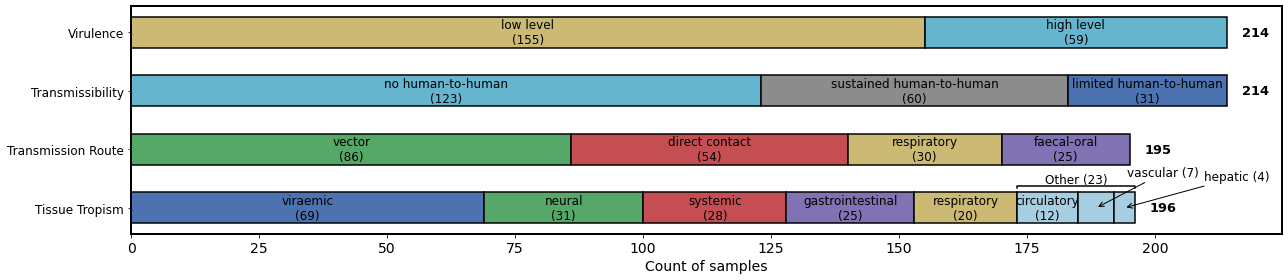

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

def show_data_components():
    # 读取数据
    dt = pd.read_excel("../../data/data_components.xlsx", sheet_name="data_components", header=0)

    # 替换 Infectivity → Transmissibility
    dt["Group"] = dt["Group"].replace({"Infectivity": "Transmissibility"})

    # Group 内部 Count 从大到小
    dt = dt.sort_values(by=["Group", "Count"], ascending=[True, False])

    # 计算每个 Group 的总数
    group_totals = dt.groupby("Group")["Count"].sum()
    
    # ========== 颜色设置（Nature风格） ==========
    nature_colors = [
        "#4C72B0",  # 蓝
        "#55A868",  # 绿
        "#C44E52",  # 红
        "#8172B3",  # 紫
        "#CCB974",  # 黄褐
        "#64B5CD",  # 青蓝
        "#8C8C8C"   # 灰
    ]

    label_colors = {}
    color_idx = 0
    for _, row in dt.iterrows():
        group = row["Group"]
        label = row["Label"]
        if group == "Tissue Tropism" and label in ["circulatory", "vascular", "hepatic"]:
            label_colors[label] = "#a6cee3"  # 特殊浅蓝色
        else:
            if label not in label_colors:
                label_colors[label] = nature_colors[color_idx % len(nature_colors)]
                color_idx += 1

    # ========== 绘图 ==========
    fig, ax = plt.subplots(figsize=(18, 4))

    # 固定顺序
    groups_order = ["Virulence", "Transmissibility", "Transmission Route", "Tissue Tropism"]
    groups_order = ["Tissue Tropism", "Transmission Route", "Transmissibility", "Virulence"]
    #groups_order = ["Transmissibility", "Tissue Tropism", "Transmission Route", "Virulence"]
    groups = [g for g in groups_order if g in dt["Group"].unique()]
    y_positions = {g: i*1.5 for i, g in enumerate(groups)}
    bottoms = {g: 0 for g in groups}

    # 保存 circulatory/vascular/hepatic 的区间范围
    special_xmin, special_xmax, special_sum = None, None, 0

    for _, row in dt.iterrows():
        group = row["Group"]
        label = row["Label"]
        count = row["Count"]

        ax.barh(y_positions[group], count, left=bottoms[group],
                edgecolor="black", linewidth=1.5, color=label_colors[label])

        # circulatory 保留在柱子内部显示
        if not (group == "Tissue Tropism" and label in ["vascular", "hepatic"]):
            wrapped_label = "\n".join(textwrap.wrap(label, width=30))
            ax.text(
                bottoms[group] + count / 2,
                y_positions[group],
                f"{wrapped_label}\n({count})",
                ha="center", va="center", fontsize=12, color="black"
            )

        if group == "Tissue Tropism" and label in ["circulatory", "vascular", "hepatic"]:
            if special_xmin is None:
                special_xmin = bottoms[group]
            special_xmax = bottoms[group] + count
            special_sum += count

        bottoms[group] += count

    # 在柱子顶端写总数
    for group, total in group_totals.items():
        ax.text(
            total + 3, y_positions[group], str(total),
            ha="left", va="center", fontsize=13, fontweight="bold"
        )

    # ========== 特殊 annotation ==========
    vascular_row = dt[(dt["Group"]=="Tissue Tropism") & (dt["Label"]=="vascular")].iloc[0]
    hepatic_row = dt[(dt["Group"]=="Tissue Tropism") & (dt["Label"]=="hepatic")].iloc[0]

    vascular_x = group_totals["Tissue Tropism"] - hepatic_row["Count"] - vascular_row["Count"]/2
    hepatic_x = group_totals["Tissue Tropism"] - hepatic_row["Count"]/2
    y_tissue = y_positions["Tissue Tropism"]

    ax.annotate(
        f"vascular ({vascular_row['Count']})",
        xy=(vascular_x, y_tissue),
        xytext=(vascular_x+13, (y_positions["Tissue Tropism"]+y_positions["Transmissibility"])/2-0.7),
        ha="center", fontsize=12,
        arrowprops=dict(arrowstyle="->", lw=1)
    )

    ax.annotate(
        f"hepatic ({hepatic_row['Count']})",
        xy=(hepatic_x, y_tissue),
        xytext=(hepatic_x+22, (y_positions["Tissue Tropism"]+y_positions["Transmissibility"])/2-0.8),
        ha="center", fontsize=12,
        arrowprops=dict(arrowstyle="->", lw=1)
    )

    # ========== 括号 + Other ==========
    if special_xmin is not None and special_xmax is not None:
        y_mid = (y_positions["Transmission Route"] + y_positions["Tissue Tropism"]) / 2-0.25
        y_offset = 0.1

        ax.plot([special_xmin, special_xmin, special_xmax, special_xmax],
                [y_mid, y_mid + y_offset-0.05, y_mid + y_offset-0.05, y_mid],
                color="black", lw=1.5)

        ax.text((special_xmin + special_xmax)/2, y_mid + y_offset+0.29,
                f"Other ({special_sum})",
                ha="center", va="top", fontsize=12)

    # 美化
    ax.set_xlabel("Count of samples", fontsize=14)
    ax.tick_params(axis='x', labelsize=14)
    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels(list(y_positions.keys()), fontsize=12)

    # 坐标轴线加粗
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    plt.tight_layout()

    #plt.savefig("./fig_saved/Fig3A_phenotypes_pred_data_component.pdf",
    #        format="pdf", 
    #        dpi=300,  # 高分辨率
    #        bbox_inches="tight", # 防止内容被裁剪
    #        pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    show_data_components()


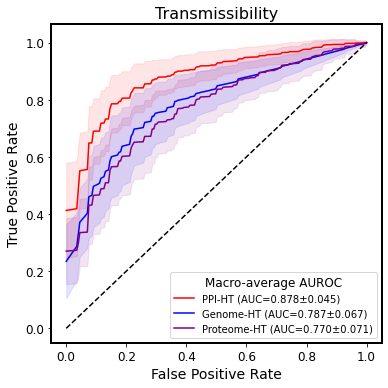

In [ ]:
## Fig. 3B

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import glob


def compute_macro_roc(file, classes, prob_cols, fpr_grid):
    df = pd.read_csv(file)
    
    # one-hot 编码
    y_true = label_binarize(df["true"], classes=classes)
    y_score = df[prob_cols].values
    
    # 每个类别算 ROC
    tprs = []
    aucs = []
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        # 插值到统一的 fpr_grid
        tprs.append(np.interp(fpr_grid, fpr, tpr))
    # 取类别平均
    mean_tpr = np.mean(tprs, axis=0)
    macro_auc = np.mean(aucs)
    return mean_tpr, macro_auc



def compute_group_curves(file_list, classes, prob_cols, fpr_grid):
    tpr_list, auc_list = [], []
    for file in file_list:
        mean_tpr, macro_auc = compute_macro_roc(file, classes, prob_cols, fpr_grid)
        tpr_list.append(mean_tpr)
        auc_list.append(macro_auc)
    # 计算平均和方差
    mean_tpr = np.mean(tpr_list, axis=0)
    std_tpr = np.std(tpr_list, axis=0)
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    return mean_tpr, std_tpr, mean_auc, std_auc


def macro_auc_infectivity():
    # ========= 参数 =========
    classes = [2,3,4]
    prob_cols = ["prob_2","prob_3","prob_4"]
    
    fpr_grid = np.linspace(0, 1, 200)
    
    # ========= 文件列表 =========
    exp_files = glob.glob("../../data/transmissibility/ppibased/top200_probs_split*.csv")   # 实验组100个文件
    ctrl_files = glob.glob("../../data/transmissibility/genomebased/probs_split*.csv")     # 对照组100个文件
    ctrl_files2 = glob.glob("../../data/transmissibility/proteomebased/probs_split*.csv")     # 对照组100个文件
    
    # ========= 计算 =========
    exp_mean_tpr, exp_std_tpr, exp_mean_auc, exp_std_auc = compute_group_curves(exp_files, classes, prob_cols, fpr_grid)
    ctrl_mean_tpr, ctrl_std_tpr, ctrl_mean_auc, ctrl_std_auc = compute_group_curves(ctrl_files, classes, prob_cols, fpr_grid)
    ctrl_mean_tpr2, ctrl_std_tpr2, ctrl_mean_auc2, ctrl_std_auc2 = compute_group_curves(ctrl_files2, classes, prob_cols, fpr_grid)
    
    # ========= 绘图 =========
    plt.figure(figsize=(5.5,5.5))
    # 实验组
    plt.plot(fpr_grid, exp_mean_tpr, color="red", label=f"PPI-HT (AUC={exp_mean_auc:.3f}±{exp_std_auc:.3f})")
    plt.fill_between(fpr_grid, exp_mean_tpr-exp_std_tpr, exp_mean_tpr+exp_std_tpr, color="red", alpha=0.1)
    # 对照组 (基因组)
    plt.plot(fpr_grid, ctrl_mean_tpr, color="blue", label=f"Genome-HT (AUC={ctrl_mean_auc:.3f}±{ctrl_std_auc:.3f})")
    plt.fill_between(fpr_grid, ctrl_mean_tpr-ctrl_std_tpr, ctrl_mean_tpr+ctrl_std_tpr, color="blue", alpha=0.1)
    # 对照组 (蛋白组)
    plt.plot(fpr_grid, ctrl_mean_tpr2, color="purple", label=f"Proteome-HT (AUC={ctrl_mean_auc2:.3f}±{ctrl_std_auc2:.3f})")
    plt.fill_between(fpr_grid, ctrl_mean_tpr2-ctrl_std_tpr2, ctrl_mean_tpr2+ctrl_std_tpr2, color="purple", alpha=0.1)
    
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc="lower right", title="Macro-average AUROC", fontsize=10, title_fontsize=12)
    
    plt.title("Transmissibility", fontsize=16)

    ax = plt.gca()    
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)  
    ax.spines['top'].set_linewidth(2)   
    ax.spines['right'].set_linewidth(2) 
    
    plt.tight_layout()
    
    plt.savefig("../../fig_in_paper/Fig3B.pdf",
        format="pdf", 
        dpi=300,  # 高分辨率
        bbox_inches="tight", # 防止内容被裁剪
        pad_inches=0.1)  # 添加少许边距
    
    plt.show()

    


if __name__ == "__main__":
    macro_auc_infectivity()


In [ ]:
## Fig. 3B，E PPI-HT 与 Genome-HT 和 Proteome 之间在AUROC上是否显著
"""
Fig. 3B
Statistical comparison of macro-average AUROC
PPI-HT vs Genome-HT
PPI-HT vs Proteome-HT

Method:
Paired Wilcoxon signed-rank test across matched splits
"""

import glob
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.stats import wilcoxon


# =====================================================
# 1. Compute macro-average ROC for one split
# =====================================================
def compute_macro_roc(file, classes, prob_cols, fpr_grid):
    df = pd.read_csv(file)

    # one-hot encode true labels
    y_true = label_binarize(df["true"], classes=classes)
    y_score = df[prob_cols].values

    tprs = []
    aucs = []

    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)

        # interpolate TPR to common FPR grid
        tprs.append(np.interp(fpr_grid, fpr, tpr))

    mean_tpr = np.mean(tprs, axis=0)
    macro_auc = np.mean(aucs)

    return mean_tpr, macro_auc


# =====================================================
# 2. Collect AUROC list across splits
# =====================================================
def collect_auc_list(file_list, classes, prob_cols):
    aucs = []
    fpr_grid = np.linspace(0, 1, 200)

    for file in file_list:
        _, macro_auc = compute_macro_roc(
            file,
            classes=classes,
            prob_cols=prob_cols,
            fpr_grid=fpr_grid
        )
        aucs.append(macro_auc)

    return np.array(aucs)


# =====================================================
# 3. Main statistical test
# =====================================================
def macro_auc_statistical_test():

    # ---------- parameters ----------
    classes = [2, 3, 4]
    prob_cols = ["prob_2", "prob_3", "prob_4"]

    # ---------- input files ----------
    ppi_files = sorted(
        glob.glob("../../data/transmissibility/ppibased/top200_probs_split*.csv")
    )
    genome_files = sorted(
        glob.glob("../../data/transmissibility/genomebased/probs_split*.csv")
    )
    proteome_files = sorted(
        glob.glob("../../data/transmissibility/proteomebased/probs_split*.csv")
    )

    # sanity check
    assert len(ppi_files) == len(genome_files) == len(proteome_files), \
        "Split numbers do not match!"

    n_splits = len(ppi_files)
    print(f"Detected {n_splits} matched splits\n")

    # ---------- collect AUROCs ----------
    auc_ppi = collect_auc_list(ppi_files, classes, prob_cols)
    auc_genome = collect_auc_list(genome_files, classes, prob_cols)
    auc_proteome = collect_auc_list(proteome_files, classes, prob_cols)

    # ---------- paired Wilcoxon tests ----------
    stat_pg, p_pg = wilcoxon(auc_ppi, auc_genome)
    stat_pp, p_pp = wilcoxon(auc_ppi, auc_proteome)

    # ---------- summary ----------
    print("========= Macro-average AUROC (mean ± SD) =========")
    print(f"PPI-HT       : {auc_ppi.mean():.3f} ± {auc_ppi.std():.3f}")
    print(f"Genome-HT    : {auc_genome.mean():.3f} ± {auc_genome.std():.3f}")
    print(f"Proteome-HT  : {auc_proteome.mean():.3f} ± {auc_proteome.std():.3f}")

    print("\n========= Paired Wilcoxon signed-rank tests =========")
    print("PPI-HT vs Genome-HT:")
    print(f"  statistic = {stat_pg:.3f}")
    print(f"  p-value   = {p_pg:.3e}")

    print("\nPPI-HT vs Proteome-HT:")
    print(f"  statistic = {stat_pp:.3f}")
    print(f"  p-value   = {p_pp:.3e}")

    # ---------- effect size (median ΔAUROC) ----------
    print("\n========= Effect size (ΔAUROC) =========")
    print(f"Median (PPI - Genome): {np.median(auc_ppi - auc_genome):.4f}")
    print(f"Median (PPI - Proteome): {np.median(auc_ppi - auc_proteome):.4f}")


# =====================================================
# 4. Run
# =====================================================
if __name__ == "__main__":
    macro_auc_statistical_test()


Detected 100 matched splits

========= Macro-average AUROC (mean ± SD) =========
PPI-HT       : 0.878 ± 0.045
Genome-HT    : 0.787 ± 0.067
Proteome-HT  : 0.770 ± 0.071

========= Paired Wilcoxon signed-rank tests =========
PPI-HT vs Genome-HT:
  statistic = 246.000
  p-value   = 4.653e-15

PPI-HT vs Proteome-HT:
  statistic = 179.000
  p-value   = 7.245e-16

========= Effect size (ΔAUROC) =========
Median (PPI - Genome): 0.0941
Median (PPI - Proteome): 0.0986


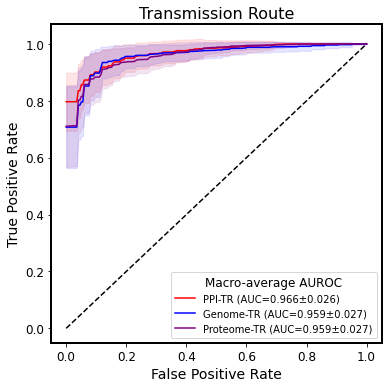

In [ ]:
## Fig. 3C

import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import glob


def compute_macro_roc(file, classes, prob_cols, fpr_grid):
    df = pd.read_csv(file)
    
    # one-hot 编码
    y_true = label_binarize(df["true"], classes=classes)
    y_score = df[prob_cols].values
    
    # 每个类别算 ROC
    tprs = []
    aucs = []
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        # 插值到统一的 fpr_grid
        tprs.append(np.interp(fpr_grid, fpr, tpr))
    # 取类别平均
    mean_tpr = np.mean(tprs, axis=0)
    macro_auc = np.mean(aucs)
    return mean_tpr, macro_auc

def compute_group_curves(file_list, classes, prob_cols, fpr_grid):
    tpr_list, auc_list = [], []
    for file in file_list:
        mean_tpr, macro_auc = compute_macro_roc(file, classes, prob_cols, fpr_grid)
        tpr_list.append(mean_tpr)
        auc_list.append(macro_auc)
    # 计算平均和方差
    mean_tpr = np.mean(tpr_list, axis=0)
    std_tpr = np.std(tpr_list, axis=0)
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    return mean_tpr, std_tpr, mean_auc, std_auc


def macro_auc_transmission_route():
    # ========= 参数 =========
    classes = ["direct contact", "faecal-oral", "respiratory", "vector"]
    prob_cols = ["prob_direct contact", "prob_faecal-oral", "prob_respiratory", "prob_vector"]
    
    fpr_grid = np.linspace(0, 1, 200)
    
    # ========= 文件列表 =========
    exp_files = glob.glob("../../data/transmission_route/ppibased/top350_probs_split*.csv")   # 实验组100个文件
    ctrl_files = glob.glob("../../data/transmission_route/genomebased/probs_split*.csv")     # 对照组100个文件
    ctrl_files2 = glob.glob("../../data/transmission_route/proteomebased/probs_split*.csv") # 对照组100个文件
    # ========= 计算 =========
    exp_mean_tpr, exp_std_tpr, exp_mean_auc, exp_std_auc = compute_group_curves(exp_files, classes, prob_cols, fpr_grid)
    ctrl_mean_tpr, ctrl_std_tpr, ctrl_mean_auc, ctrl_std_auc = compute_group_curves(ctrl_files, classes, prob_cols, fpr_grid)
    ctrl_mean_tpr2, ctrl_std_tpr2, ctrl_mean_auc2, ctrl_std_auc2 = compute_group_curves(ctrl_files2, classes, prob_cols, fpr_grid)
    
    # ========= 绘图 =========
    plt.figure(figsize=(5.5,5.5))
    # 实验组
    plt.plot(fpr_grid, exp_mean_tpr, color="red", label=f"PPI-TR (AUC={exp_mean_auc:.3f}±{exp_std_auc:.3f})")
    plt.fill_between(fpr_grid, exp_mean_tpr-exp_std_tpr, exp_mean_tpr+exp_std_tpr, color="red", alpha=0.1)
    
    # 对照组
    plt.plot(fpr_grid, ctrl_mean_tpr, color="blue", label=f"Genome-TR (AUC={ctrl_mean_auc:.3f}±{ctrl_std_auc:.3f})")
    plt.fill_between(fpr_grid, ctrl_mean_tpr-ctrl_std_tpr, ctrl_mean_tpr+ctrl_std_tpr, color="blue", alpha=0.1)

    # 对照组 (蛋白组)
    plt.plot(fpr_grid, ctrl_mean_tpr2, color="purple", label=f"Proteome-TR (AUC={ctrl_mean_auc2:.3f}±{ctrl_std_auc2:.3f})")
    plt.fill_between(fpr_grid, ctrl_mean_tpr2-ctrl_std_tpr2, ctrl_mean_tpr2+ctrl_std_tpr2, color="purple", alpha=0.1)
    
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc="lower right", title="Macro-average AUROC", fontsize=10, title_fontsize=12)
    
    plt.title("Transmission Route", fontsize=16)

    ax = plt.gca()    
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)  
    ax.spines['top'].set_linewidth(2)   
    ax.spines['right'].set_linewidth(2) 
    
    plt.tight_layout()

    plt.savefig("../../fig_in_paper/Fig3C.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    macro_auc_transmission_route()


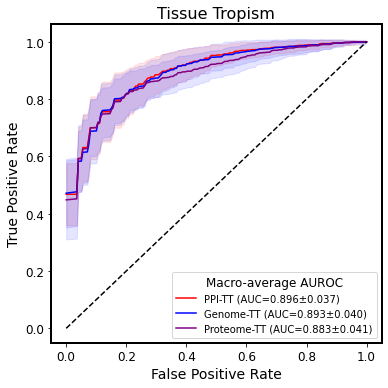

In [ ]:
## Fig.3D
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import glob
from scipy import interp
import time

def compute_macro_roc(file, classes, prob_cols, fpr_grid):
    df = pd.read_csv(file)
    
    # one-hot 编码
    y_true = label_binarize(df["true"], classes=classes)
    y_score = df[prob_cols].values
    
    # 每个类别算 ROC
    tprs = []
    aucs = []
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        # 插值到统一的 fpr_grid
        tprs.append(np.interp(fpr_grid, fpr, tpr))
    # 取类别平均
    mean_tpr = np.mean(tprs, axis=0)
    macro_auc = np.mean(aucs)
    return mean_tpr, macro_auc

def compute_group_curves(file_list, classes, prob_cols, fpr_grid):
    tpr_list, auc_list = [], []
    for file in file_list:
        mean_tpr, macro_auc = compute_macro_roc(file, classes, prob_cols, fpr_grid)
        tpr_list.append(mean_tpr)
        auc_list.append(macro_auc)
    # 计算平均和方差
    mean_tpr = np.mean(tpr_list, axis=0)
    std_tpr = np.std(tpr_list, axis=0)
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    return mean_tpr, std_tpr, mean_auc, std_auc


def macro_auc_tissue_tropism():
    # ========= 参数 =========
    classes = [0,1,2,3,4,5]
    prob_cols = ["prob_gastrointestinal", "prob_neural", "prob_other", "prob_respiratory", "prob_systemic", "prob_viraemic"]
    
    fpr_grid = np.linspace(0, 1, 200)
    
    # ========= 文件列表 =========
    exp_files = glob.glob("../../data/tissue_tropism/ppibased/top1250_probs_split*.csv")   # 实验组100个文件
    ctrl_files = glob.glob("../../data/tissue_tropism/genomebased/probs_split*.csv")     # 对照组100个文件
    ctrl_files2 = glob.glob("../../data/tissue_tropism/proteomebased/probs_split*.csv")    # 对照组100个文件
    
    # ========= 计算 =========
    exp_mean_tpr, exp_std_tpr, exp_mean_auc, exp_std_auc = compute_group_curves(exp_files, classes, prob_cols, fpr_grid)
    ctrl_mean_tpr, ctrl_std_tpr, ctrl_mean_auc, ctrl_std_auc = compute_group_curves(ctrl_files, classes, prob_cols, fpr_grid)
    ctrl_mean_tpr2, ctrl_std_tpr2, ctrl_mean_auc2, ctrl_std_auc2 = compute_group_curves(ctrl_files2, classes, prob_cols, fpr_grid)
    
    # ========= 绘图 =========
    plt.figure(figsize=(5.5,5.5))
    # 实验组
    plt.plot(fpr_grid, exp_mean_tpr, color="red", label=f"PPI-TT (AUC={exp_mean_auc:.3f}±{exp_std_auc:.3f})")
    plt.fill_between(fpr_grid, exp_mean_tpr-exp_std_tpr, exp_mean_tpr+exp_std_tpr, color="red", alpha=0.1)
    # 对照组
    plt.plot(fpr_grid, ctrl_mean_tpr, color="blue", label=f"Genome-TT (AUC={ctrl_mean_auc:.3f}±{ctrl_std_auc:.3f})")
    plt.fill_between(fpr_grid, ctrl_mean_tpr-ctrl_std_tpr, ctrl_mean_tpr+ctrl_std_tpr, color="blue", alpha=0.1)

    # 对照组 (蛋白组)
    plt.plot(fpr_grid, ctrl_mean_tpr2, color="purple", label=f"Proteome-TT (AUC={ctrl_mean_auc2:.3f}±{ctrl_std_auc2:.3f})")
    plt.fill_between(fpr_grid, ctrl_mean_tpr2-ctrl_std_tpr2, ctrl_mean_tpr2+ctrl_std_tpr2, color="blue", alpha=0.1)

    
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc="lower right", title="Macro-average AUROC", fontsize=10, title_fontsize=12)
    
    plt.title("Tissue Tropism", fontsize=16)

    ax = plt.gca()    
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)  
    ax.spines['top'].set_linewidth(2)   
    ax.spines['right'].set_linewidth(2) 
    
    plt.tight_layout()

    plt.savefig("../../fig_in_paper/Fig3D.pdf",
        format="pdf", 
        dpi=300,  # 高分辨率
        bbox_inches="tight", # 防止内容被裁剪
        pad_inches=0.1)  # 添加少许边距
    
    plt.show()

    


if __name__ == "__main__":
    macro_auc_tissue_tropism()


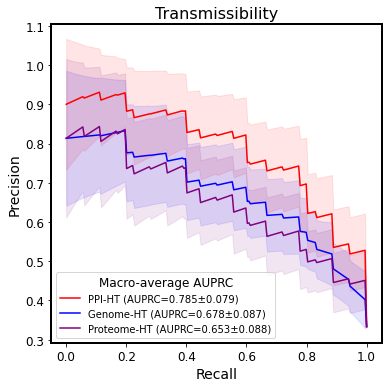

In [ ]:
## Fig. 3E
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import glob

def compute_macro_pr(file, classes, prob_cols, recall_grid):
    df = pd.read_csv(file)

    # one-hot 编码
    y_true = label_binarize(df["true"], classes=classes)
    y_score = df[prob_cols].values

    # 每个类别算 PR
    precisions = []
    aucs = []
    for i in range(len(classes)):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_score[:, i])
        pr_auc = auc(recall, precision)
        aucs.append(pr_auc)
        # recall 递增，反转后插值
        precision_interp = np.interp(recall_grid, recall[::-1], precision[::-1])
        precisions.append(precision_interp)

    # 取类别平均
    mean_prec = np.mean(precisions, axis=0)
    macro_auc = np.mean(aucs)
    return mean_prec, macro_auc

def compute_group_curves(file_list, classes, prob_cols, recall_grid):
    prec_list, auc_list = [], []
    for file in file_list:
        mean_prec, macro_auc = compute_macro_pr(file, classes, prob_cols, recall_grid)
        prec_list.append(mean_prec)
        auc_list.append(macro_auc)
    # 计算平均和方差
    mean_prec = np.mean(prec_list, axis=0)
    std_prec = np.std(prec_list, axis=0)
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    return mean_prec, std_prec, mean_auc, std_auc

def macro_auprc_infectivity():
    # ========= 参数 =========
    classes = [2,3,4]
    prob_cols = ["prob_2","prob_3","prob_4"]

    recall_grid = np.linspace(0, 1, 200)

    # ========= 文件列表 =========
    exp_files = glob.glob("../../data/transmissibility/ppibased/top200_probs_split*.csv")   # 实验组100个文件
    ctrl_files = glob.glob("../../data/transmissibility/genomebased/probs_split*.csv")     # 对照组100个文件
    ctrl_files2 = glob.glob("../../data/transmissibility/proteomebased/probs_split*.csv")     # 对照组100个文件

    # ========= 计算 =========
    exp_mean_prec, exp_std_prec, exp_mean_auc, exp_std_auc = compute_group_curves(exp_files, classes, prob_cols, recall_grid)
    ctrl_mean_prec, ctrl_std_prec, ctrl_mean_auc, ctrl_std_auc = compute_group_curves(ctrl_files, classes, prob_cols, recall_grid)
    ctrl_mean_prec2, ctrl_std_prec2, ctrl_mean_auc2, ctrl_std_auc2 = compute_group_curves(ctrl_files2, classes, prob_cols, recall_grid)

    # ========= 绘图 =========
    plt.figure(figsize=(5.5,5.5))
    # 实验组
    plt.plot(recall_grid, exp_mean_prec, color="red", label=f"PPI-HT (AUPRC={exp_mean_auc:.3f}±{exp_std_auc:.3f})")
    plt.fill_between(recall_grid, exp_mean_prec-exp_std_prec, exp_mean_prec+exp_std_prec, color="red", alpha=0.1)
    # 对照组
    plt.plot(recall_grid, ctrl_mean_prec, color="blue", label=f"Genome-HT (AUPRC={ctrl_mean_auc:.3f}±{ctrl_std_auc:.3f})")
    plt.fill_between(recall_grid, ctrl_mean_prec-ctrl_std_prec, ctrl_mean_prec+ctrl_std_prec, color="blue", alpha=0.1)
    # 对照组 (蛋白组)
    plt.plot(recall_grid, ctrl_mean_prec2, color="purple", label=f"Proteome-HT (AUPRC={ctrl_mean_auc2:.3f}±{ctrl_std_auc2:.3f})")
    plt.fill_between(recall_grid, ctrl_mean_prec2-ctrl_std_prec2, ctrl_mean_prec2+ctrl_std_prec2, color="purple", alpha=0.1)

    plt.xlabel("Recall", fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel("Precision", fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc="lower left", title="Macro-average AUPRC", fontsize=10, title_fontsize=12)

    plt.title("Transmissibility", fontsize=16)

    ax = plt.gca()    
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    plt.tight_layout()

    plt.savefig("../../fig_in_paper/Fig3E.pdf",
        format="pdf", 
        dpi=300,  # 高分辨率
        bbox_inches="tight", # 防止内容被裁剪
        pad_inches=0.1)  # 添加少许边距
    
    plt.show()

if __name__ == "__main__":
    macro_auprc_infectivity()


In [ ]:
## Fig. 3E 判断 PPI-HT 与 Genome-HT, Proteome-HT 在AUPRC上是否显著

"""
Fig. 3E
Statistical comparison of macro-average AUPRC
PPI-HT vs Genome-HT
PPI-HT vs Proteome-HT

Method:
Paired Wilcoxon signed-rank test across matched splits
"""

import glob
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
from scipy.stats import wilcoxon


# =====================================================
# 1. Compute macro-average PR for one split
# =====================================================
def compute_macro_pr(file, classes, prob_cols, recall_grid):
    df = pd.read_csv(file)

    y_true = label_binarize(df["true"], classes=classes)
    y_score = df[prob_cols].values

    precisions = []
    aucs = []

    for i in range(len(classes)):
        precision, recall, _ = precision_recall_curve(
            y_true[:, i], y_score[:, i]
        )
        pr_auc = auc(recall, precision)
        aucs.append(pr_auc)

        # recall is increasing, reverse for interpolation
        precision_interp = np.interp(
            recall_grid, recall[::-1], precision[::-1]
        )
        precisions.append(precision_interp)

    mean_precision = np.mean(precisions, axis=0)
    macro_auprc = np.mean(aucs)

    return mean_precision, macro_auprc


# =====================================================
# 2. Collect AUPRC list across splits
# =====================================================
def collect_auprc_list(file_list, classes, prob_cols):
    auprcs = []
    recall_grid = np.linspace(0, 1, 200)

    for file in file_list:
        _, macro_auprc = compute_macro_pr(
            file,
            classes=classes,
            prob_cols=prob_cols,
            recall_grid=recall_grid
        )
        auprcs.append(macro_auprc)

    return np.array(auprcs)


# =====================================================
# 3. Main statistical test
# =====================================================
def macro_auprc_statistical_test():

    # ---------- parameters ----------
    classes = [2, 3, 4]
    prob_cols = ["prob_2", "prob_3", "prob_4"]

    # ---------- input files ----------
    ppi_files = sorted(
        glob.glob("../../data/transmissibility/ppibased/top200_probs_split*.csv")
    )
    genome_files = sorted(
        glob.glob("../../data/transmissibility/genomebased/probs_split*.csv")
    )
    proteome_files = sorted(
        glob.glob("../../data/transmissibility/proteomebased/probs_split*.csv")
    )

    # sanity check
    assert len(ppi_files) == len(genome_files) == len(proteome_files), \
        "Split numbers do not match!"

    n_splits = len(ppi_files)
    print(f"Detected {n_splits} matched splits\n")

    # ---------- collect AUPRCs ----------
    auprc_ppi = collect_auprc_list(ppi_files, classes, prob_cols)
    auprc_genome = collect_auprc_list(genome_files, classes, prob_cols)
    auprc_proteome = collect_auprc_list(proteome_files, classes, prob_cols)

    # ---------- paired Wilcoxon tests ----------
    stat_pg, p_pg = wilcoxon(auprc_ppi, auprc_genome)
    stat_pp, p_pp = wilcoxon(auprc_ppi, auprc_proteome)

    # ---------- summary ----------
    print("========= Macro-average AUPRC (mean ± SD) =========")
    print(f"PPI-HT       : {auprc_ppi.mean():.3f} ± {auprc_ppi.std():.3f}")
    print(f"Genome-HT    : {auprc_genome.mean():.3f} ± {auprc_genome.std():.3f}")
    print(f"Proteome-HT  : {auprc_proteome.mean():.3f} ± {auprc_proteome.std():.3f}")

    print("\n========= Paired Wilcoxon signed-rank tests =========")
    print("PPI-HT vs Genome-HT:")
    print(f"  statistic = {stat_pg:.3f}")
    print(f"  p-value   = {p_pg:.3e}")

    print("\nPPI-HT vs Proteome-HT:")
    print(f"  statistic = {stat_pp:.3f}")
    print(f"  p-value   = {p_pp:.3e}")

    # ---------- effect size ----------
    print("\n========= Effect size (ΔAUPRC) =========")
    print(f"Median (PPI - Genome): {np.median(auprc_ppi - auprc_genome):.4f}")
    print(f"Median (PPI - Proteome): {np.median(auprc_ppi - auprc_proteome):.4f}")


# =====================================================
# 4. Run
# =====================================================
if __name__ == "__main__":
    macro_auprc_statistical_test()


Detected 100 matched splits

========= Macro-average AUPRC (mean ± SD) =========
PPI-HT       : 0.785 ± 0.079
Genome-HT    : 0.678 ± 0.087
Proteome-HT  : 0.653 ± 0.088

========= Paired Wilcoxon signed-rank tests =========
PPI-HT vs Genome-HT:
  statistic = 417.000
  p-value   = 4.230e-13

PPI-HT vs Proteome-HT:
  statistic = 409.000
  p-value   = 3.452e-13

========= Effect size (ΔAUPRC) =========
Median (PPI - Genome): 0.1155
Median (PPI - Proteome): 0.1395


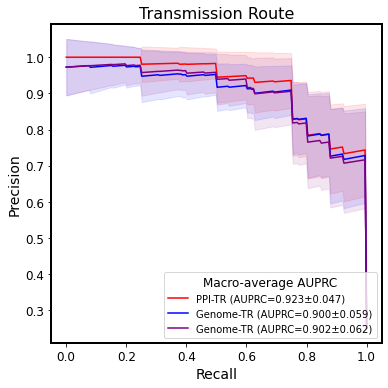

In [ ]:
## Fig.3F
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import glob


def compute_macro_pr(file, classes, prob_cols, recall_grid):
    df = pd.read_csv(file)

    # one-hot 编码
    y_true = label_binarize(df["true"], classes=classes)
    y_score = df[prob_cols].values

    # 每个类别算 PR
    precisions = []
    aucs = []
    for i in range(len(classes)):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_score[:, i])
        pr_auc = auc(recall, precision)
        aucs.append(pr_auc)
        # 注意 recall 要递增，反转后插值
        precision_interp = np.interp(recall_grid, recall[::-1], precision[::-1])
        precisions.append(precision_interp)

    # 取类别平均
    mean_prec = np.mean(precisions, axis=0)
    macro_auc = np.mean(aucs)
    return mean_prec, macro_auc

def compute_group_curves(file_list, classes, prob_cols, recall_grid):
    prec_list, auc_list = [], []
    for file in file_list:
        mean_prec, macro_auc = compute_macro_pr(file, classes, prob_cols, recall_grid)
        prec_list.append(mean_prec)
        auc_list.append(macro_auc)

    # 计算平均和方差
    mean_prec = np.mean(prec_list, axis=0)
    std_prec = np.std(prec_list, axis=0)
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    return mean_prec, std_prec, mean_auc, std_auc

def macro_auprc_transmission_route():
    # ========= 参数 =========
    classes = ["direct contact", "faecal-oral", "respiratory", "vector"]
    prob_cols = ["prob_direct contact", "prob_faecal-oral", "prob_respiratory", "prob_vector"]

    recall_grid = np.linspace(0, 1, 200)

    # ========= 文件列表 =========
    exp_files = glob.glob("../../data/transmission_route/ppibased/top350_probs_split*.csv")   # 实验组100个文件
    ctrl_files = glob.glob("../../data/transmission_route/genomebased/probs_split*.csv") # 对照组100个文件
    ctrl_files2 = glob.glob("../../data/transmission_route/proteomebased/probs_split*.csv") # 对照组100个文件

    # ========= 计算 =========
    exp_mean_prec, exp_std_prec, exp_mean_auc, exp_std_auc = compute_group_curves(exp_files, classes, prob_cols, recall_grid)
    ctrl_mean_prec, ctrl_std_prec, ctrl_mean_auc, ctrl_std_auc = compute_group_curves(ctrl_files, classes, prob_cols, recall_grid)
    ctrl_mean_prec2, ctrl_std_prec2, ctrl_mean_auc2, ctrl_std_auc2 = compute_group_curves(ctrl_files2, classes, prob_cols, recall_grid)

    # ========= 绘图 =========
    plt.figure(figsize=(5.5, 5.5))

    # 实验组
    plt.plot(recall_grid, exp_mean_prec, color="red",label=f"PPI-TR (AUPRC={exp_mean_auc:.3f}±{exp_std_auc:.3f})")
    plt.fill_between(recall_grid, exp_mean_prec - exp_std_prec, exp_mean_prec + exp_std_prec,color="red", alpha=0.1)

    # 对照组
    plt.plot(recall_grid, ctrl_mean_prec, color="blue",label=f"Genome-TR (AUPRC={ctrl_mean_auc:.3f}±{ctrl_std_auc:.3f})")
    plt.fill_between(recall_grid, ctrl_mean_prec - ctrl_std_prec, ctrl_mean_prec + ctrl_std_prec,color="blue", alpha=0.1)
    
    # 对照组 (蛋白组)
    plt.plot(recall_grid, ctrl_mean_prec2, color="purple",label=f"Genome-TR (AUPRC={ctrl_mean_auc2:.3f}±{ctrl_std_auc2:.3f})")
    plt.fill_between(recall_grid, ctrl_mean_prec2 - ctrl_std_prec2, ctrl_mean_prec2 + ctrl_std_prec2, color="purple", alpha=0.1)
    

    plt.xlabel("Recall", fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel("Precision", fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc="lower right", title="Macro-average AUPRC", fontsize=10, title_fontsize=12)

    plt.title("Transmission Route", fontsize=16)

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    plt.tight_layout()

    plt.savefig("../../fig_in_paper/Fig3F.pdf",
        format="pdf", 
        dpi=300,  # 高分辨率
        bbox_inches="tight", # 防止内容被裁剪
        pad_inches=0.1)  # 添加少许边距
        
    plt.show()

if __name__ == "__main__":
    macro_auprc_transmission_route()


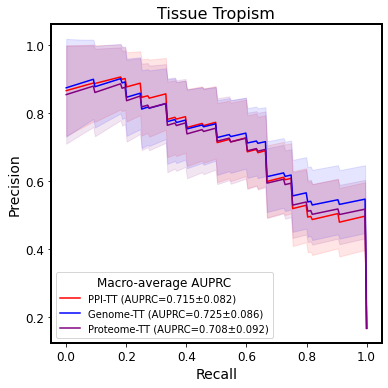

In [ ]:
## Fig. 3G

import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import glob


def compute_macro_pr(file, classes, prob_cols, recall_grid):
    df = pd.read_csv(file)

    # one-hot 编码
    y_true = label_binarize(df["true"], classes=classes)
    y_score = df[prob_cols].values

    # 每个类别算 PR
    precisions = []
    aucs = []
    for i in range(len(classes)):
        precision, recall, _ = precision_recall_curve(y_true[:, i], y_score[:, i])
        pr_auc = auc(recall, precision)
        aucs.append(pr_auc)
        # recall 递增，反转后插值
        precision_interp = np.interp(recall_grid, recall[::-1], precision[::-1])
        precisions.append(precision_interp)

    # 取类别平均
    mean_prec = np.mean(precisions, axis=0)
    macro_auc = np.mean(aucs)
    return mean_prec, macro_auc

def compute_group_curves(file_list, classes, prob_cols, recall_grid):
    prec_list, auc_list = [], []
    for file in file_list:
        mean_prec, macro_auc = compute_macro_pr(file, classes, prob_cols, recall_grid)
        prec_list.append(mean_prec)
        auc_list.append(macro_auc)
    # 计算平均和方差
    mean_prec = np.mean(prec_list, axis=0)
    std_prec = np.std(prec_list, axis=0)
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    return mean_prec, std_prec, mean_auc, std_auc

def macro_auprc_tissue_tropism():
    # ========= 参数 =========
    classes = [0,1,2,3,4,5]
    prob_cols = ["prob_gastrointestinal", "prob_neural", "prob_other", 
                 "prob_respiratory", "prob_systemic", "prob_viraemic"]

    recall_grid = np.linspace(0, 1, 200)

    # ========= 文件列表 =========
    exp_files = glob.glob("../../data/tissue_tropism/ppibased/top1250_probs_split*.csv")   # 实验组100个文件
    ctrl_files = glob.glob("../../data/tissue_tropism/genomebased/probs_split*.csv")     # 对照组100个文件
    ctrl_files2 = glob.glob("../../data/tissue_tropism/proteomebased/probs_split*.csv")    # 对照组100个文件

    # ========= 计算 =========
    exp_mean_prec, exp_std_prec, exp_mean_auc, exp_std_auc = compute_group_curves(exp_files, classes, prob_cols, recall_grid)
    ctrl_mean_prec, ctrl_std_prec, ctrl_mean_auc, ctrl_std_auc = compute_group_curves(ctrl_files, classes, prob_cols, recall_grid)
    ctrl_mean_prec2, ctrl_std_prec2, ctrl_mean_auc2, ctrl_std_auc2 = compute_group_curves(ctrl_files2, classes, prob_cols, recall_grid)

    # ========= 绘图 =========
    plt.figure(figsize=(5.5,5.5))

    # 实验组
    plt.plot(recall_grid, exp_mean_prec, color="red", label=f"PPI-TT (AUPRC={exp_mean_auc:.3f}±{exp_std_auc:.3f})")
    plt.fill_between(recall_grid, exp_mean_prec-exp_std_prec, exp_mean_prec+exp_std_prec, color="red", alpha=0.1)

    # 对照组
    plt.plot(recall_grid, ctrl_mean_prec, color="blue", label=f"Genome-TT (AUPRC={ctrl_mean_auc:.3f}±{ctrl_std_auc:.3f})")
    plt.fill_between(recall_grid, ctrl_mean_prec-ctrl_std_prec, ctrl_mean_prec+ctrl_std_prec, color="blue", alpha=0.1)

    # 对照组 (蛋白组)
    plt.plot(recall_grid, ctrl_mean_prec2, color="purple", label=f"Proteome-TT (AUPRC={ctrl_mean_auc2:.3f}±{ctrl_std_auc2:.3f})")
    plt.fill_between(recall_grid, ctrl_mean_prec2-ctrl_std_prec2, ctrl_mean_prec2+ctrl_std_prec2, color="purple", alpha=0.1)
    
    
    plt.xlabel("Recall", fontsize=14)
    plt.xticks(fontsize=12)
    plt.ylabel("Precision", fontsize=14)
    plt.yticks(fontsize=12)
    plt.legend(loc="lower left", title="Macro-average AUPRC", fontsize=10, title_fontsize=12)

    plt.title("Tissue Tropism", fontsize=16)

    ax = plt.gca()    
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    plt.tight_layout()

    plt.savefig("../../fig_in_paper/Fig3G.pdf",
        format="pdf", 
        dpi=300,  # 高分辨率
        bbox_inches="tight", # 防止内容被裁剪
        pad_inches=0.1)  # 添加少许边距
    
    plt.show()

if __name__ == "__main__":
    macro_auprc_tissue_tropism()


         group  class      mean       std
0    Genome-HT      2  0.743437  0.067842
1    Genome-HT      3  0.819688  0.049432
2    Genome-HT      4  0.853750  0.057379
3       PPI-HT      2  0.788125  0.058181
4       PPI-HT      3  0.875313  0.040097
5       PPI-HT      4  0.880938  0.053613
6  Proteome-HT      2  0.712187  0.071108
7  Proteome-HT      3  0.843125  0.036890
8  Proteome-HT      4  0.835313  0.056333


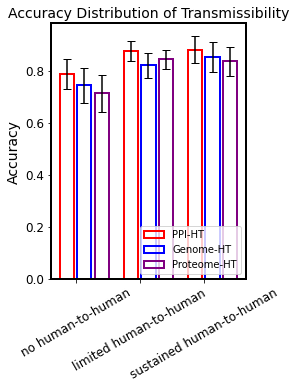

In [ ]:
## Fig.3H

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import glob

# ========= 计算单个文件的 per-class Accuracy =========
def compute_class_accuracy(file, classes):
    df = pd.read_csv(file)
    y_true = df["true"].values
    y_pred = df["pred"].values

    accs = {}
    for cls in classes:
        y_true_bin = (y_true == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        if np.sum(y_true_bin) == 0:
            accs[cls] = np.nan
        else:
            accs[cls] = accuracy_score(y_true_bin, y_pred_bin)
    return accs


# ========= 通用计算函数 =========
def compute_group_metric(file_list, group_name, classes, metric_func):
    records = []
    for file in file_list:
        metrics = metric_func(file, classes)
        for cls, val in metrics.items():
            records.append({"group": group_name, "class": cls, "value": val})
    return pd.DataFrame(records)


# ========= 通用绘图函数 =========
def barplot_metric(df_all, classes, ylabel, title, savepath):
    plt.figure(figsize=(4,5.5))
    ax = plt.gca()

    df_stats = df_all.groupby(["group", "class"])["value"].agg(["mean", "std"]).reset_index()
    print(df_stats)

    groups = df_all["group"].unique()
    bar_width = 0.22
    gap = 0.05
    x = np.arange(len(classes))
    colors = {"PPI-HT":"red", "Genome-HT":"blue", "Proteome-HT":"purple"}  # Nature风格配色

    for i, group in enumerate(groups):
        stats_group = df_stats[df_stats["group"] == group]
        means = stats_group["mean"].values
        stds = stats_group["std"].values
        offset = (i - 0.5) * (bar_width + gap)
        ax.bar(
            x + offset, means, yerr=stds,
            width=bar_width, facecolor="none",
            edgecolor=colors[group],
            capsize=4, linewidth=2
        )

    # 图例
    handles = [plt.Rectangle((0,0),1,1, facecolor="none", edgecolor=colors[g], linewidth=2) for g in groups]
    plt.legend(handles, groups, fontsize=10, loc="lower right")

    x_labels = ["no human-to-human","limited human-to-human","sustained human-to-human"]
    plt.xticks(ticks=range(len(x_labels)), labels=x_labels, fontsize=12, rotation=30)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=14)
    plt.yticks(fontsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)  
    ax.spines['top'].set_linewidth(2)
    ax.spines['right'].set_linewidth(2)
    plt.tight_layout()

    plt.savefig(savepath, format="pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()


# ========= Accuracy 图 =========
def barplot_accuracy_infectivity():
    classes = [2, 3, 4]
    exp_files = glob.glob("../../data/transmissibility/ppibased/top200_probs_split*.csv")
    ctrl_files = glob.glob("../../data/transmissibility/genomebased/probs_split*.csv")
    ctrl_files2 = glob.glob("../../data/transmissibility/proteomebased/probs_split*.csv")     # 对照组100个文件
    

    df_exp = compute_group_metric(exp_files, "PPI-HT", classes, compute_class_accuracy)
    df_ctrl = compute_group_metric(ctrl_files, "Genome-HT", classes, compute_class_accuracy)
    df_ctrl2 = compute_group_metric(ctrl_files2, "Proteome-HT", classes, compute_class_accuracy)
    df_all = pd.concat([df_exp, df_ctrl], ignore_index=True)
    df_all = pd.concat([df_all, df_ctrl2], ignore_index=True)

    barplot_metric(df_all, classes, "Accuracy", "Accuracy Distribution of Transmissibility",
                   "../../fig_in_paper/Fig3H.pdf")


if __name__ == "__main__":
    barplot_accuracy_infectivity()


In [ ]:
"""
Fig.3H (PPI-HT, Genome-HT和Proteome-HT在Accuracy上是否具有显著差异)

Statistical significance test of per-class Accuracy

Comparison:
PPI-HT vs Genome-HT
PPI-HT vs Proteome-HT

Method:
Paired Wilcoxon signed-rank test across matched splits
"""

import glob
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from scipy.stats import wilcoxon


# =====================================================
# 1. Per-class Accuracy for ONE file
# =====================================================
def compute_class_accuracy(file, classes):
    df = pd.read_csv(file)
    y_true = df["true"].values
    y_pred = df["pred"].values

    accs = {}
    for cls in classes:
        y_true_bin = (y_true == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)

        if np.sum(y_true_bin) == 0:
            accs[cls] = np.nan
        else:
            accs[cls] = accuracy_score(y_true_bin, y_pred_bin)

    return accs


# =====================================================
# 2. Collect Accuracy across splits
# =====================================================
def collect_accuracy(file_list, classes):
    records = []

    for idx, file in enumerate(sorted(file_list)):
        accs = compute_class_accuracy(file, classes)
        for cls, val in accs.items():
            records.append({
                "split": idx,
                "class": cls,
                "accuracy": val
            })

    return pd.DataFrame(records)


# =====================================================
# 3. Main statistical test
# =====================================================
def main():

    classes = [2, 3, 4]
    class_map = {
        2: "no human-to-human",
        3: "limited human-to-human",
        4: "sustained human-to-human"
    }

    # ---------- files ----------
    ppi_files = sorted(
        glob.glob("../../data/transmissibility/ppibased/top200_probs_split*.csv")
    )
    genome_files = sorted(
        glob.glob("../../data/transmissibility/genomebased/probs_split*.csv")
    )
    proteome_files = sorted(
        glob.glob("../../data/transmissibility/proteomebased/probs_split*.csv")
    )

    assert len(ppi_files) == len(genome_files) == len(proteome_files), \
        "Split numbers do not match!"

    print(f"Detected {len(ppi_files)} matched splits\n")

    # ---------- collect ----------
    df_ppi = collect_accuracy(ppi_files, classes)
    df_genome = collect_accuracy(genome_files, classes)
    df_proteome = collect_accuracy(proteome_files, classes)

    # ---------- statistical test ----------
    print("========= Paired Wilcoxon signed-rank tests (Accuracy) =========\n")

    for cls in classes:
        name = class_map[cls]

        acc_ppi = df_ppi[df_ppi["class"] == cls]["accuracy"].values
        acc_genome = df_genome[df_genome["class"] == cls]["accuracy"].values
        acc_proteome = df_proteome[df_proteome["class"] == cls]["accuracy"].values

        # 去掉 NaN（某些 split 可能没有该类）
        mask_pg = ~np.isnan(acc_ppi) & ~np.isnan(acc_genome)
        mask_pp = ~np.isnan(acc_ppi) & ~np.isnan(acc_proteome)

        stat_pg, p_pg = wilcoxon(acc_ppi[mask_pg], acc_genome[mask_pg])
        stat_pp, p_pp = wilcoxon(acc_ppi[mask_pp], acc_proteome[mask_pp])

        print(f"Class: {name}")
        print(f"  PPI-HT vs Genome-HT:")
        print(f"    mean = {acc_ppi.mean():.3f} vs {acc_genome.mean():.3f}")
        print(f"    Wilcoxon p = {p_pg:.3e}")

        print(f"  PPI-HT vs Proteome-HT:")
        print(f"    mean = {acc_ppi.mean():.3f} vs {acc_proteome.mean():.3f}")
        print(f"    Wilcoxon p = {p_pp:.3e}\n")


# =====================================================
# 4. Run
# =====================================================
if __name__ == "__main__":
    main()


Detected 100 matched splits

========= Paired Wilcoxon signed-rank tests (Accuracy) =========

Class: no human-to-human
  PPI-HT vs Genome-HT:
    mean = 0.788 vs 0.743
    Wilcoxon p = 1.521e-05
  PPI-HT vs Proteome-HT:
    mean = 0.788 vs 0.712
    Wilcoxon p = 2.061e-10

Class: limited human-to-human
  PPI-HT vs Genome-HT:
    mean = 0.875 vs 0.820
    Wilcoxon p = 3.553e-12
  PPI-HT vs Proteome-HT:
    mean = 0.875 vs 0.843
    Wilcoxon p = 1.550e-06

Class: sustained human-to-human
  PPI-HT vs Genome-HT:
    mean = 0.881 vs 0.854
    Wilcoxon p = 6.911e-04
  PPI-HT vs Proteome-HT:
    mean = 0.881 vs 0.835
    Wilcoxon p = 3.438e-08



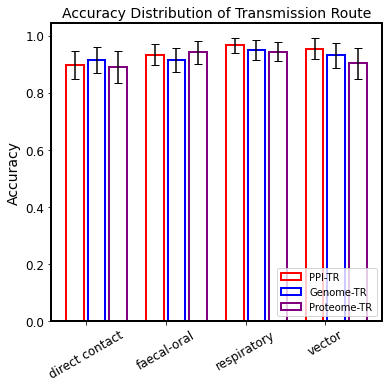

In [ ]:
## Fig. 3I

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import glob


# ========= 计算单个文件的 per-class Accuracy =========
def compute_class_accuracy(file, classes):
    df = pd.read_csv(file)
    y_true = df["true"].values
    y_pred = df["pred"].values

    accs = {}
    for cls in classes:
        y_true_bin = (y_true == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        if np.sum(y_true_bin) == 0:
            accs[cls] = np.nan
        else:
            accs[cls] = accuracy_score(y_true_bin, y_pred_bin)
    return accs


# ========= 通用计算函数 =========
def compute_group_metric(file_list, group_name, classes, metric_func):
    records = []
    for file in file_list:
        metrics = metric_func(file, classes)
        for cls, val in metrics.items():
            records.append({"group": group_name, "class": cls, "value": val})
    return pd.DataFrame(records)


# ========= 通用绘图函数 =========
def barplot_metric(df_all, classes, ylabel, title, savepath):
    plt.figure(figsize=(5.5, 5.5))
    ax = plt.gca()

    df_stats = df_all.groupby(["group", "class"])["value"].agg(["mean", "std"]).reset_index()

    groups = df_all["group"].unique()
    bar_width = 0.22
    gap = 0.05
    x = np.arange(len(classes))
    colors = {"PPI-TR": "red", "Genome-TR": "blue", "Proteome-TR":"purple"}  # Nature风格配色

    for i, group in enumerate(groups):
        stats_group = df_stats[df_stats["group"] == group]
        means = stats_group["mean"].values
        stds = stats_group["std"].values
        offset = (i - 0.5) * (bar_width + gap)
        ax.bar(
            x + offset,
            means,
            yerr=stds,
            width=bar_width,
            facecolor="none",
            edgecolor=colors[group],
            capsize=4,
            linewidth=2,
        )

    # 图例
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor="none", edgecolor=colors[g], linewidth=2) for g in groups]
    plt.legend(handles, groups, fontsize=10, loc="lower right")

    x_labels = ["direct contact", "faecal-oral", "respiratory", "vector"]
    plt.xticks(ticks=range(len(x_labels)), labels=x_labels, fontsize=12, rotation=30)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=14)
    plt.yticks(fontsize=12)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_linewidth(2)
    ax.spines["right"].set_linewidth(2)
    plt.tight_layout()

    plt.savefig(savepath, format="pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()


# ========= Accuracy 图 =========
def barplot_accuracy_transmission_route():
    #### 传播方式
    classes = ["direct contact", "faecal-oral", "respiratory", "vector"]
    exp_files = glob.glob("../../data/transmission_route/ppibased/top350_probs_split*.csv")   # 实验组100个文件
    ctrl_files = glob.glob("../../data/transmission_route/genomebased/probs_split*.csv") # 对照组100个文件
    ctrl_files2 = glob.glob("../../data/transmission_route/proteomebased/probs_split*.csv") # 对照组100个文件

    df_exp = compute_group_metric(exp_files, "PPI-TR", classes, compute_class_accuracy)
    df_ctrl = compute_group_metric(ctrl_files, "Genome-TR", classes, compute_class_accuracy)
    df_ctrl2 = compute_group_metric(ctrl_files2, "Proteome-TR", classes, compute_class_accuracy)
    df_all = pd.concat([df_exp, df_ctrl], ignore_index=True)
    df_all = pd.concat([df_all, df_ctrl2], ignore_index=True)

    barplot_metric(
        df_all,
        classes,
        "Accuracy",
        "Accuracy Distribution of Transmission Route",
        "../../fig_in_paper/Fig3I.pdf",
    )


if __name__ == "__main__":
    barplot_accuracy_transmission_route()


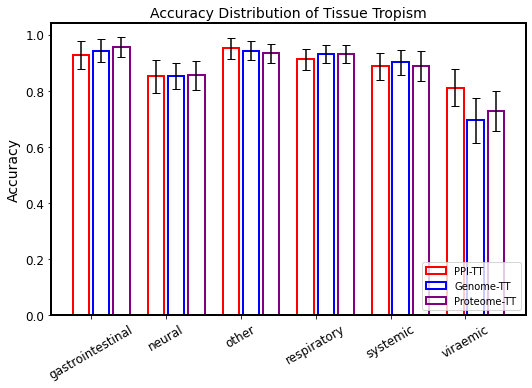

In [ ]:
## Fig. 3J Tissue Tropism Accuracy


import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import glob


# ========= 计算单个文件的 per-class Accuracy =========
def compute_class_accuracy(file, classes):
    df = pd.read_csv(file)
    y_true = df["true"].values
    y_pred = df["pred"].values

    accs = {}
    for cls in classes:
        y_true_bin = (y_true == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        if np.sum(y_true_bin) == 0:
            accs[cls] = np.nan
        else:
            accs[cls] = accuracy_score(y_true_bin, y_pred_bin)
    return accs


# ========= 通用计算函数 =========
def compute_group_metric(file_list, group_name, classes, metric_func):
    records = []
    for file in file_list:
        metrics = metric_func(file, classes)
        for cls, val in metrics.items():
            records.append({"group": group_name, "class": cls, "value": val})
    return pd.DataFrame(records)


# ========= 通用绘图函数 =========
def barplot_metric(df_all, classes, ylabel, title, savepath):
    plt.figure(figsize=(7.5, 5.5))
    ax = plt.gca()

    df_stats = df_all.groupby(["group", "class"])["value"].agg(["mean", "std"]).reset_index()

    groups = df_all["group"].unique()
    bar_width = 0.22
    gap = 0.05
    x = np.arange(len(classes))
    colors = {"PPI-TT": "red", "Genome-TT": "blue", "Proteome-TT":"purple"}  # Nature风格配色

    for i, group in enumerate(groups):
        stats_group = df_stats[df_stats["group"] == group]
        means = stats_group["mean"].values
        stds = stats_group["std"].values
        offset = (i - 0.5) * (bar_width + gap)
        ax.bar(
            x + offset,
            means,
            yerr=stds,
            width=bar_width,
            facecolor="none",
            edgecolor=colors[group],
            capsize=4,
            linewidth=2,
        )

    # 图例
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor="none", edgecolor=colors[g], linewidth=2) for g in groups]
    plt.legend(handles, groups, fontsize=10, loc="lower right")

    x_labels = ["gastrointestinal", "neural", "other", "respiratory", "systemic", "viraemic"]
    plt.xticks(ticks=range(len(x_labels)), labels=x_labels, fontsize=12, rotation=30)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=14)
    plt.yticks(fontsize=12)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_linewidth(2)
    ax.spines["right"].set_linewidth(2)
    plt.tight_layout()

    plt.savefig(savepath, format="pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()


# ========= Accuracy 图 =========
def barplot_accuracy_tissue_tropism():
    #### 组织嗜性
    classes = [0, 1, 2, 3, 4, 5]
    exp_files = glob.glob("../../data/tissue_tropism/ppibased/top1250_probs_split*.csv")
    ctrl_files = glob.glob("../../data/tissue_tropism/genomebased/probs_split*.csv")
    ctrl_files2 = glob.glob("../../data/tissue_tropism/proteomebased/probs_split*.csv")    # 对照组100个文件

    df_exp = compute_group_metric(exp_files, "PPI-TT", classes, compute_class_accuracy)
    df_ctrl = compute_group_metric(ctrl_files, "Genome-TT", classes, compute_class_accuracy)
    df_ctrl2 = compute_group_metric(ctrl_files2, "Proteome-TT", classes, compute_class_accuracy)
    df_all = pd.concat([df_exp, df_ctrl], ignore_index=True)
    df_all = pd.concat([df_all, df_ctrl2], ignore_index=True)

    barplot_metric(
        df_all,
        classes,
        "Accuracy",
        "Accuracy Distribution of Tissue Tropism",
        "../../fig_in_paper/Fig3J.pdf",
    )


if __name__ == "__main__":
    barplot_accuracy_tissue_tropism()


## Fig. 4 Phenotype predictions of potentially human-infecting viruses using PPI-based models.

Known viruses: 677
Low-confidence viruses: 792

Family statistics:
                  vfam  count_pred  num_pos  num_ictv
0       Picornaviridae         432       37       159
1         unclassified          53       10         0
2         Hantaviridae          44       16        55
3         Circoviridae          38       33       160
4         Adenoviridae          36       15       145
5        Caliciviridae          25        7        12
6       Sedoreoviridae          25       11        45
7         Astroviridae          16       14        31
8     Peribunyaviridae          16       38       152
9         Parvoviridae          14       20       281
10        Flaviviridae          11       45        61
11        Retroviridae          10       24        65
12       Phenuiviridae           8       25       223
13    Papillomaviridae           7       73       133
14    Picobirnaviridae           7        1         3
15          Poxviridae           6       15        56
16        Nairo

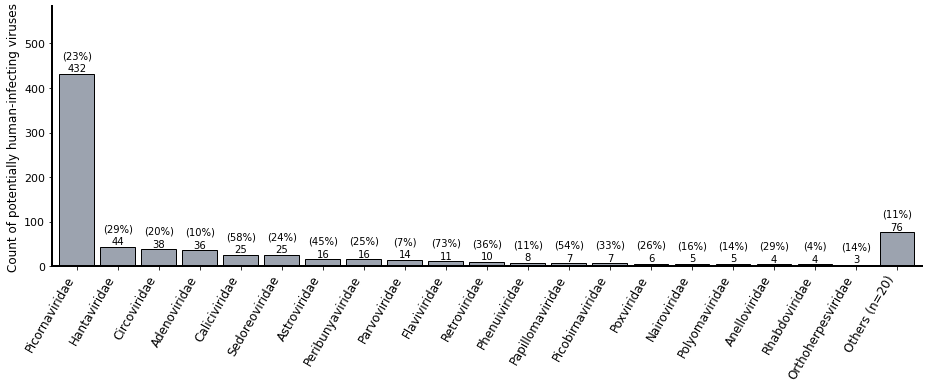

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def virus_taxonomy_distribution():

    # ===============================
    # 1. 读取与预处理
    # ===============================
    df_all = pd.read_excel(
        "../../tables_and_figs_updated/Table S2_update.xlsx",
        sheet_name="Table S2",
        header=1, dtype=str
    )

    # 已知高/中可信度病毒
    df_known = df_all[df_all["Evidence level"] != "low"].reset_index(drop=True)

    # 低可信度病毒
    df_low = df_all[df_all["Evidence level"] == "low"].reset_index(drop=True)

    print("Known viruses:", df_known.shape[0])
    print("Low-confidence viruses:", df_low.shape[0])


    # ===============================
    # 2. Low-confidence病毒：
    #    统计每个family中的数量
    # ===============================
    family_pred = (
        df_low.groupby("Family")
        .size()
        .reset_index(name="count_pred")
        .rename(columns={"Family": "vfam"})
    )


    # ===============================
    # 3. 已知人类感染病毒：
    #    统计每个family中的数量
    # ===============================
    family_known = (
        df_known.groupby("Family")
        .size()
        .reset_index(name="num_pos")
        .rename(columns={"Family": "vfam"})
    )


    # ===============================
    # 4. ICTV：
    #    统计每个family的全部病毒物种数
    # ===============================
    dt_ictv = pd.read_excel(
        "../../data/ICTV_Master_Species_List_2025_MSL41.v1.xlsx",
        sheet_name="MSL"
    )

    family_ictv = (
        dt_ictv.groupby("Family")
        .size()
        .reset_index(name="num_ictv")
        .rename(columns={"Family": "vfam"})
    )


    # ===============================
    # 5. 合并family统计结果
    # ===============================
    family_counts = pd.merge(family_pred, family_known, on="vfam", how="left")
    family_counts = pd.merge(family_counts, family_ictv, on="vfam", how="left")

    family_counts["num_pos"] = family_counts["num_pos"].fillna(0).astype(int)
    family_counts["num_ictv"] = family_counts["num_ictv"].fillna(0).astype(int)

    family_counts = family_counts.sort_values(
        "count_pred",
        ascending=False
    ).reset_index(drop=True)

    family_counts.to_csv("./xx.txt", sep="\t", index=False)

    print("\nFamily statistics:")
    print(family_counts.head(25))


    # ===============================
    # 6. 将 unclassified 单独取出
    # ===============================
    unclassified_mask = (
        family_counts["vfam"]
        .astype(str)
        .str.strip()
        .str.lower()
        == "unclassified"
    )

    df_unclassified = family_counts[unclassified_mask].copy()

    # 删除unclassified，使后面的family自动前移
    family_classified = (
        family_counts[~unclassified_mask]
        .copy()
        .reset_index(drop=True)
    )

    print("\nUnclassified:")
    print(df_unclassified)


    # ===============================
    # 7. Top 20 + Others
    #    Others包括：
    #    1. unclassified
    #    2. Top 20之外的family
    # ===============================
    top20 = family_classified.iloc[:20].copy()
    others = family_classified.iloc[20:].copy()

    plot_df = top20[
        ["vfam", "count_pred", "num_pos", "num_ictv"]
    ].copy()


    # 合并 unclassified 和其他非Top20 family
    others_all = pd.concat(
        [df_unclassified, others],
        ignore_index=True
    )


    if len(others_all) > 0:

        others_row = pd.DataFrame({
            "vfam": [f"Others (n={others_all.shape[0]})"],
            "count_pred": [others_all["count_pred"].sum()],
            "num_pos": [others_all["num_pos"].sum()],
            "num_ictv": [others_all["num_ictv"].sum()]
        })

        plot_df = pd.concat(
            [plot_df, others_row],
            ignore_index=True
        )


    print("\nFinal plot data:")
    print(plot_df)


    # ===============================
    # 8. 绘图
    # ===============================
    fig, ax = plt.subplots(figsize=(13, 5.5))

    x = np.arange(plot_df.shape[0])

    ax.bar(
        x,
        plot_df["count_pred"],
        width=0.85,
        color="#9ca3af",
        edgecolor="black",
        linewidth=1
    )


    # ===============================
    # 9. 标注：数量 + 百分比
    # ===============================
    ymax = plot_df["count_pred"].max()

    for i in range(plot_df.shape[0]):

        cnt = plot_df.loc[i, "count_pred"]
        num_pos = plot_df.loc[i, "num_pos"]
        num_ictv = plot_df.loc[i, "num_ictv"]

        # 数量
        ax.text(
            i,
            cnt + 0.8,
            f"{int(cnt)}",
            ha="center",
            va="bottom",
            fontsize=10
        )

        # 百分比
        if num_ictv > 0:

            perc = int(num_pos / num_ictv * 100)

            ax.text(
                i,
                cnt + 30,
                f"({perc}%)",
                ha="center",
                va="bottom",
                fontsize=10
            )


    # ===============================
    # 10. 坐标轴
    # ===============================
    ax.set_xticks(x)

    ax.set_xticklabels(
        plot_df["vfam"],
        rotation=60,
        ha="right",
        fontsize=12
    )

    ax.set_ylabel(
        "Count of potentially human-infecting viruses",
        fontsize=12
    )

    ax.set_xlim(-0.6, len(x) - 0.4)
    ax.set_ylim(0, ymax * 1.35)


    # ===============================
    # 11. Figure style
    # ===============================
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="y", labelsize=11)

    plt.tight_layout()

    plt.savefig(
        "../../tables_and_figs_updated/fig4a_update.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.1
    )

    plt.show()


if __name__ == "__main__":
    virus_taxonomy_distribution()

Known viruses: 677
Low-confidence viruses: 792
Low-confidence viruses (pred_score > 0.5): 450

Family statistics:
                vfam  count_pred  num_pos  num_ictv
0     Picornaviridae         160       37       159
1       unclassified          46       10         0
2       Circoviridae          35       33       160
3       Hantaviridae          33       16        55
4       Adenoviridae          33       15       145
5      Caliciviridae          23        7        12
6     Sedoreoviridae          22       11        45
7   Peribunyaviridae          15       38       152
8       Astroviridae          14       14        31
9       Parvoviridae          11       20       281
10      Flaviviridae           9       45        61
11  Picobirnaviridae           7        1         3
12     Phenuiviridae           5       25       223
13        Poxviridae           5       15        56
14  Papillomaviridae           5       73       133
15    Polyomaviridae           5       18       122
16

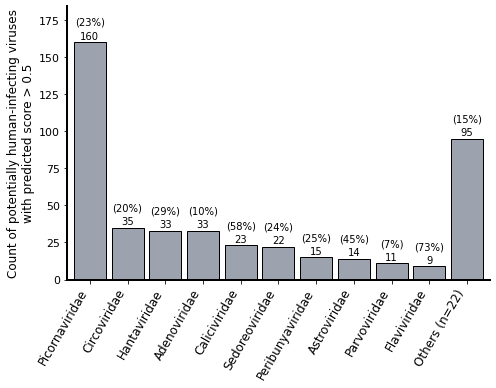

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def virus_taxonomy_distribution():

    dt_pred_score = pd.read_csv("../../mid_result_updated/low_confidience_predict/human_infectivity/rf_top1000_low_confidence_prediction_score.csv")
    dt_pred_score["Taxid"] = dt_pred_score["Taxid"].astype(str)
    dt_pred_score.columns = ["Taxid", "pred_label", "pred_score"]
    dt_pred_score = dt_pred_score[dt_pred_score["pred_score"]>0.5].reset_index(drop=True)
    target_virus_taxid = dt_pred_score["Taxid"].tolist()

    # ===============================
    # 1. 读取与预处理
    # ===============================
    df_all = pd.read_excel(
        "../../tables_and_figs_updated/Table S2_update.xlsx",
        sheet_name="Table S2",
        header=1, dtype=str
    )

    # 已知高/中可信度病毒
    df_known = df_all[df_all["Evidence level"] != "low"].reset_index(drop=True)

    # 低可信度病毒
    df_low = df_all[df_all["Evidence level"] == "low"].reset_index(drop=True)

    print("Known viruses:", df_known.shape[0])
    print("Low-confidence viruses:", df_low.shape[0])
    df_low = df_low[df_low["Taxid"].isin(target_virus_taxid)].reset_index(drop=True)
    print("Low-confidence viruses (pred_score > 0.5):", df_low.shape[0])

    # ===============================
    # 2. Low-confidence病毒：
    #    统计每个family中的数量
    # ===============================
    family_pred = (
        df_low.groupby("Family")
        .size()
        .reset_index(name="count_pred")
        .rename(columns={"Family": "vfam"})
    )


    # ===============================
    # 3. 已知人类感染病毒：
    #    统计每个family中的数量
    # ===============================
    family_known = (
        df_known.groupby("Family")
        .size()
        .reset_index(name="num_pos")
        .rename(columns={"Family": "vfam"})
    )


    # ===============================
    # 4. ICTV：
    #    统计每个family的全部病毒物种数
    # ===============================
    dt_ictv = pd.read_excel(
        "../../data/ICTV_Master_Species_List_2025_MSL41.v1.xlsx",
        sheet_name="MSL"
    )

    family_ictv = (
        dt_ictv.groupby("Family")
        .size()
        .reset_index(name="num_ictv")
        .rename(columns={"Family": "vfam"})
    )


    # ===============================
    # 5. 合并family统计结果
    # ===============================
    family_counts = pd.merge(family_pred, family_known, on="vfam", how="left")
    family_counts = pd.merge(family_counts, family_ictv, on="vfam", how="left")

    family_counts["num_pos"] = family_counts["num_pos"].fillna(0).astype(int)
    family_counts["num_ictv"] = family_counts["num_ictv"].fillna(0).astype(int)

    family_counts = family_counts.sort_values(
        "count_pred",
        ascending=False
    ).reset_index(drop=True)

    family_counts.to_csv("./xx.txt", sep="\t", index=False)

    print("\nFamily statistics:")
    print(family_counts.head(25))


    # ===============================
    # 6. 将 unclassified 单独取出
    # ===============================
    unclassified_mask = (
        family_counts["vfam"]
        .astype(str)
        .str.strip()
        .str.lower()
        == "unclassified"
    )

    df_unclassified = family_counts[unclassified_mask].copy()

    # 删除unclassified，使后面的family自动前移
    family_classified = (
        family_counts[~unclassified_mask]
        .copy()
        .reset_index(drop=True)
    )

    print("\nUnclassified:")
    print(df_unclassified)


    # ===============================
    # 7. Top 20 + Others
    #    Others包括：
    #    1. unclassified
    #    2. Top 20之外的family
    # ===============================
    top20 = family_classified.iloc[:10].copy()
    others = family_classified.iloc[10:].copy()

    plot_df = top20[
        ["vfam", "count_pred", "num_pos", "num_ictv"]
    ].copy()


    # 合并 unclassified 和其他非Top20 family
    others_all = pd.concat(
        [df_unclassified, others],
        ignore_index=True
    )


    if len(others_all) > 0:

        others_row = pd.DataFrame({
            "vfam": [f"Others (n={others_all.shape[0]})"],
            "count_pred": [others_all["count_pred"].sum()],
            "num_pos": [others_all["num_pos"].sum()],
            "num_ictv": [others_all["num_ictv"].sum()]
        })

        plot_df = pd.concat(
            [plot_df, others_row],
            ignore_index=True
        )


    print("\nFinal plot data:")
    print(plot_df)


    # ===============================
    # 8. 绘图
    # ===============================
    fig, ax = plt.subplots(figsize=(7, 5.5))

    x = np.arange(plot_df.shape[0])

    ax.bar(
        x,
        plot_df["count_pred"],
        width=0.85,
        color="#9ca3af",
        edgecolor="black",
        linewidth=1
    )


    # ===============================
    # 9. 标注：数量 + 百分比
    # ===============================
    ymax = plot_df["count_pred"].max()

    for i in range(plot_df.shape[0]):

        cnt = plot_df.loc[i, "count_pred"]
        num_pos = plot_df.loc[i, "num_pos"]
        num_ictv = plot_df.loc[i, "num_ictv"]

        # 数量
        ax.text(
            i,
            cnt + 0.8,
            f"{int(cnt)}",
            ha="center",
            va="bottom",
            fontsize=10
        )

        # 百分比
        if num_ictv > 0:

            perc = int(num_pos / num_ictv * 100)

            ax.text(
                i,
                cnt + 10,
                f"({perc}%)",
                ha="center",
                va="bottom",
                fontsize=10
            )


    # ===============================
    # 10. 坐标轴
    # ===============================
    ax.set_xticks(x)

    ax.set_xticklabels(
        plot_df["vfam"],
        rotation=60,
        ha="right",
        fontsize=12
    )

    ax.set_ylabel(
        "Count of potentially human-infecting viruses\nwith predicted score > 0.5",
        fontsize=12
    )

    ax.set_xlim(-0.6, len(x) - 0.4)
    ax.set_ylim(0, ymax * 1.15)


    # ===============================
    # 11. Figure style
    # ===============================
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="y", labelsize=11)

    plt.tight_layout()

    plt.savefig(
        "../../tables_and_figs_updated/fig4a_update.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.1
    )

    plt.show()


if __name__ == "__main__":
    virus_taxonomy_distribution()

In [1]:
import pandas as pd


def data_prepare_for_fig4B():

    # 读取病毒基本信息
    dt_info = pd.read_excel(
        "../../tables_and_figs_updated/Table S2_update.xlsx",
        sheet_name="Table S2",
        header=1,
        dtype=str
    )
    dt_info = dt_info.loc[:, ["Taxid", "NucleicAcid Type", "Species"]]
    dt_info.columns = ["Taxid", "Genome Type", "Species"]

    # Virulence
    dt_virulence = pd.read_csv(
        "../../mid_result_updated/low_confidience_predict/virulence/svm_top250_low_confidence_prediction_score_virulence.csv",
        dtype=str
    )
    dt_virulence = dt_virulence.loc[:, ["vtaxid", "pred_label"]]
    dt_virulence.columns = ["Taxid", "Virulence"]

    # Transmissibility
    dt_transmissibility = pd.read_csv(
        "../../mid_result_updated/low_confidience_predict/transmissibility/svm_top200_low_confidence_prediction_score_transmissibility.csv",
        dtype=str
    )
    dt_transmissibility = dt_transmissibility.loc[:, ["vtaxid", "pred_label"]]
    dt_transmissibility.columns = ["Taxid", "Transmissibility"]

    # Tissue tropism
    dt_tissue_tropism = pd.read_csv(
        "../../mid_result_updated/low_confidience_predict/tissue_tropism/svm_top1250_low_confidence_prediction_score_tissuetropism.csv",
        dtype=str
    )
    dt_tissue_tropism = dt_tissue_tropism.loc[:, ["vtaxid", "pred_label"]]
    dt_tissue_tropism.columns = ["Taxid", "Tissue Tropism"]

    # Transmission route
    dt_transmission_route = pd.read_csv(
        "../../mid_result_updated/low_confidience_predict/transmission_route/svm_top350_low_confidence_prediction_score_transroute.csv",
        dtype=str
    )
    dt_transmission_route = dt_transmission_route.loc[:, ["vtaxid", "pred_label"]]
    dt_transmission_route.columns = ["Taxid", "Transmission Route"]

    # ============================================================
    # 合并
    # ============================================================

    dt_result = dt_virulence.merge(dt_info, on="Taxid", how="left")
    dt_result = dt_result.merge(dt_transmissibility, on="Taxid", how="left")
    dt_result = dt_result.merge(dt_tissue_tropism, on="Taxid", how="left")
    dt_result = dt_result.merge(dt_transmission_route, on="Taxid", how="left")

    # 查看结果
    print(dt_result.shape)

    # 选择 pred_score > 0.5 (human infectivity)
    dt_pred_score = pd.read_csv("../../mid_result_updated/low_confidience_predict/human_infectivity/rf_top1000_low_confidence_prediction_score.csv")
    dt_pred_score["Taxid"] = dt_pred_score["Taxid"].astype(str)
    dt_pred_score.columns = ["Taxid", "pred_label", "pred_score"]
    dt_pred_score = dt_pred_score[dt_pred_score["pred_score"]>0.5].reset_index(drop=True)
    target_virus_taxid = dt_pred_score["Taxid"].tolist()

    dt_result = dt_result[dt_result["Taxid"].isin(target_virus_taxid)]
    print(dt_result.shape)

    # 选出 RNA viruses
    dt_result = dt_result[dt_result["Genome Type"].str.contains("RNA", case=False, na=False)].reset_index(drop=True)
    print(dt_result.shape)
    dt_result.to_csv("../../mid_result_updated/low_confidience_predict/low_pred_res.txt", index=False)
    

if __name__ == "__main__":
    data_prepare_for_fig4B()

(792, 7)
(450, 7)
(319, 7)


In [ ]:
##====== Fig. 4B Predicted transmission route, tissue tropism, virulence, and transmissibility of potentially human-infecting RNA viruses ======##

## see ./codeForFig4B.R

In [ ]:
import pandas as pd
import re


def data_prepare_for_fig4C():

    # ===============================
    # 1. 读取预测结果
    # ===============================
    dt_info = pd.read_excel("../../tables_and_figs_updated/Table S2_update.xlsx", sheet_name="Table S2", header=1, dtype=str)
    dict_vfam = dict(zip(dt_info["Taxid"], dt_info["Family"]))
    dict_vgenome = dict(zip(dt_info["Taxid"], dt_info["NucleicAcid Type"]))
    dt_human_infectivity = pd.read_csv("../../mid_result_updated/low_confidience_predict/human_infectivity/rf_top1000_low_confidence_prediction_score.csv", dtype={"Taxid": str})
    dt_virulence = pd.read_csv("../../mid_result_updated/low_confidience_predict/virulence/svm_top250_low_confidence_prediction_score_virulence.csv", dtype={"vtaxid": str})
    dt_transmissibility = pd.read_csv("../../mid_result_updated/low_confidience_predict/transmissibility/svm_top200_low_confidence_prediction_score_transmissibility.csv", dtype={"vtaxid": str})
    dt_tissue_tropism = pd.read_csv("../../mid_result_updated/low_confidience_predict/tissue_tropism/svm_top1250_low_confidence_prediction_score_tissuetropism.csv", dtype={"vtaxid": str})
    dt_transmission_route = pd.read_csv("../../mid_result_updated/low_confidience_predict/transmission_route/svm_top350_low_confidence_prediction_score_transroute.csv", dtype={"vtaxid": str})

    # ===============================
    # 2. Human infectivity
    # ===============================
    dt_human_infectivity = dt_human_infectivity[["Taxid", "prediction_score"]].copy()
    dt_human_infectivity.columns = ["vtaxid", "infecting-human"]

    # ===============================
    # 3. Virulence
    # ===============================
    dt_virulence = dt_virulence[["vtaxid", "pred"]].copy()
    dt_virulence.columns = ["vtaxid", "virulence"]

    # ===============================
    # 4. Transmissibility
    # ===============================
    dt_transmissibility = dt_transmissibility[["vtaxid", "sustained human-to-human", "limited human-to-human", "no human-to-human"]].copy()

    # ===============================
    # 5. Tissue tropism
    # ===============================
    dt_tissue_tropism = dt_tissue_tropism[["vtaxid", "prob_gastrointestinal", "prob_neural", "prob_respiratory", "prob_systemic", "prob_viraemic", "prob_other"]].copy()
    dt_tissue_tropism.columns = ["vtaxid", "gastrointestinal", "neural", "respiratory (tissue tropism)", "systemic", "viraemic", "other"]

    # ===============================
    # 6. Transmission route
    # ===============================
    dt_transmission_route = dt_transmission_route[["vtaxid", "prob_direct contact", "prob_faecal-oral", "prob_respiratory", "prob_vector"]].copy()
    dt_transmission_route.columns = ["vtaxid", "direct contact", "faecal-oral", "respiratory (transmission route)", "vector"]

    # ===============================
    # 7. 读取病毒名称
    # ===============================
    dt_info = pd.read_excel("../../tables_and_figs_updated/Table S2_update.xlsx", sheet_name="Table S2", header=1, dtype=str)

    # 如果Table S2中的病毒名称列叫Species
    dt_info = dt_info[["Taxid", "Species"]].copy()
    dt_info.columns = ["vtaxid", "virus name"]

    # 去掉virus name末尾的(Taxid)
    # 例如：
    # Orthohantavirus prospectense (3052492)
    # ->
    # Orthohantavirus prospectense
    dt_info["virus name"] = dt_info["virus name"].str.replace(r"\s*\(\d+\)\s*$", "", regex=True).str.strip()

    # ===============================
    # 8. 确保所有Taxid均为字符串
    # ===============================
    dt_human_infectivity["vtaxid"] = dt_human_infectivity["vtaxid"].astype(str)
    dt_virulence["vtaxid"] = dt_virulence["vtaxid"].astype(str)
    dt_transmissibility["vtaxid"] = dt_transmissibility["vtaxid"].astype(str)
    dt_tissue_tropism["vtaxid"] = dt_tissue_tropism["vtaxid"].astype(str)
    dt_transmission_route["vtaxid"] = dt_transmission_route["vtaxid"].astype(str)
    dt_info["vtaxid"] = dt_info["vtaxid"].astype(str)

    # ===============================
    # 9. 合并
    # 以human infectivity预测结果为主表
    # ===============================
    dt_result = dt_human_infectivity.merge(dt_virulence, on="vtaxid", how="left")
    dt_result = dt_result.merge(dt_transmissibility, on="vtaxid", how="left")
    dt_result = dt_result.merge(dt_tissue_tropism, on="vtaxid", how="left")
    dt_result = dt_result.merge(dt_transmission_route, on="vtaxid", how="left")
    dt_result = dt_result.merge(dt_info, on="vtaxid", how="left")

    # ===============================
    # 10. 最终列顺序
    # ===============================
    final_columns = [
        "vtaxid",
        "infecting-human",
        "virulence",
        "sustained human-to-human",
        "limited human-to-human",
        "no human-to-human",
        "gastrointestinal",
        "neural",
        "respiratory (tissue tropism)",
        "systemic",
        "viraemic",
        "other",
        "direct contact",
        "faecal-oral",
        "respiratory (transmission route)",
        "vector",
        "virus name"
    ]

    dt_result = dt_result[final_columns]
    dt_result["virus family"] = dt_result["vtaxid"].map(dict_vfam)
    dt_result["Genome Type"] = dt_result["vtaxid"].map(dict_vgenome)


    # 选择 pred_score > 0.5 (human infectivity)
    dt_pred_score = pd.read_csv("../../mid_result_updated/low_confidience_predict/human_infectivity/rf_top1000_low_confidence_prediction_score.csv")
    dt_pred_score["Taxid"] = dt_pred_score["Taxid"].astype(str)
    dt_pred_score.columns = ["Taxid", "pred_label", "pred_score"]
    dt_pred_score = dt_pred_score[dt_pred_score["pred_score"]>0.5].reset_index(drop=True)
    target_virus_taxid = dt_pred_score["Taxid"].tolist()

    dt_result = dt_result[dt_result["vtaxid"].isin(target_virus_taxid)]
    print(dt_result.shape)

    # 选出 RNA viruses
    dt_result = dt_result[dt_result["Genome Type"].str.contains("RNA", case=False, na=False)].reset_index(drop=True)

    # ===============================
    # 11. 检查结果
    # ===============================
    print("Final shape:", dt_result.shape)
    print(dt_result.head())

    # ===============================
    # 12. 保存
    # ===============================
    dt_result.to_csv("../../mid_result_updated/low_confidience_predict/data_for_fig4c.csv", index=False)


if __name__ == "__main__":
    data_prepare_for_fig4C()

(450, 19)
Final shape: (319, 19)
    vtaxid  infecting-human  virulence  sustained human-to-human  \
0  1076281         0.603824   0.222813                  0.382860   
1  1076282         0.603824   0.222813                  0.382860   
2  1076283         0.603824   0.222813                  0.382860   
3  1076284         0.535000   0.174849                  0.332514   
4  1076285         0.603824   0.222813                  0.382860   

   limited human-to-human  no human-to-human  gastrointestinal    neural  \
0                0.162029           0.455111          0.084458  0.171610   
1                0.162029           0.455111          0.084458  0.171610   
2                0.162029           0.455111          0.084458  0.171610   
3                0.119291           0.548195          0.070971  0.162291   
4                0.162029           0.455111          0.084458  0.171610   

   respiratory (tissue tropism)  systemic  viraemic     other  direct contact  \
0                   


Virus families:
Sedoreoviridae: #1F77B4
Picornaviridae: #AEC7E8
Coronaviridae: #2F4B7C


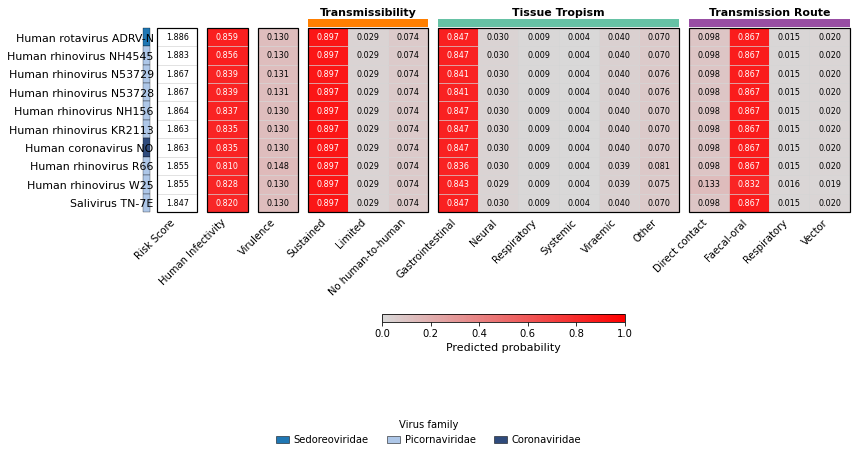

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as patches


def heatmap_phenotypes_binary():

    # ============================================================
    # 1. Read data
    # ============================================================
    dt_value = pd.read_csv("../../mid_result_updated/low_confidience_predict/data_for_fig4c.csv", sep=",", header=0)

    dt_value["virus name"] = dt_value["virus name"].str.replace(r"\s*\(\d+\)\s*$", "", regex=True).str.strip()
    dt_value["virus family"] = dt_value["virus family"].fillna("Unknown").astype(str)

    # ============================================================
    # 2. Calculate Risk Score
    # ============================================================
    dt_value["Risk Score"] = dt_value["virulence"] + dt_value["infecting-human"] + dt_value["sustained human-to-human"]

    # 按Risk Score排序并取Top 10
    dt_sorted = dt_value.sort_values(by="Risk Score", ascending=False).reset_index(drop=True).head(10).copy()

    virus_families = dt_sorted["virus family"].tolist()

    # ============================================================
    # 3. Define heatmap columns
    # ============================================================
    columns = [
        "Risk Score",
        "infecting-human",
        "virulence",
        "sustained human-to-human",
        "limited human-to-human",
        "no human-to-human",
        "gastrointestinal",
        "neural",
        "respiratory (tissue tropism)",
        "systemic",
        "viraemic",
        "other",
        "direct contact",
        "faecal-oral",
        "respiratory (transmission route)",
        "vector"
    ]

    heatmap_df = dt_sorted.set_index("virus name")[columns].copy()

    # ============================================================
    # 4. X-axis display names
    # ============================================================
    display_names = [
        "Risk Score",
        "Human Infectivity",
        "Virulence",
        "Sustained",
        "Limited",
        "No human-to-human",
        "Gastrointestinal",
        "Neural",
        "Respiratory",
        "Systemic",
        "Viraemic",
        "Other",
        "Direct contact",
        "Faecal-oral",
        "Respiratory",
        "Vector"
    ]

    # ============================================================
    # 5. Define column positions
    # ============================================================
    gap = 0.25
    x_positions = []
    current_x = 0

    x_positions.append(current_x)
    current_x += 1 + gap

    x_positions.append(current_x)
    current_x += 1 + gap

    x_positions.append(current_x)
    current_x += 1 + gap

    for _ in range(3):
        x_positions.append(current_x)
        current_x += 1
    current_x += gap

    for _ in range(6):
        x_positions.append(current_x)
        current_x += 1
    current_x += gap

    for _ in range(4):
        x_positions.append(current_x)
        current_x += 1

    x_positions = np.array(x_positions)

    # ============================================================
    # 6. Heatmap color map
    # ============================================================
    cmap = LinearSegmentedColormap.from_list("gray_red", ["#d9d9d9", "#ff0000"])
    norm = Normalize(vmin=0, vmax=1)

    # ============================================================
    # 7. Virus family colors
    #
    # 尽量避开：
    # red/orange      -> heatmap + transmissibility
    # cyan/green      -> tissue tropism
    # purple          -> transmission route
    #
    # 主要使用蓝、靛蓝、黄褐、粉、橄榄、棕、灰等
    # ============================================================
    family_palette = [
        "#1F77B4",   # blue
        "#AEC7E8",   # light blue
        "#2F4B7C",   # dark indigo blue
        "#76A5AF",   # muted blue-grey
        "#D4A72C",   # ochre
        "#EDC948",   # muted yellow
        "#B07AA1",   # muted mauve
        "#FF9DA7",   # soft pink
        "#8C6D31",   # brown
        "#7F7F7F"    # dark grey
    ]

    unique_families = list(dict.fromkeys(virus_families))

    if len(unique_families) > len(family_palette):
        raise ValueError(f"Too many virus families ({len(unique_families)}); only {len(family_palette)} colors are defined.")

    family_colors = {family: family_palette[i] for i, family in enumerate(unique_families)}

    print("\nVirus families:")
    for family in unique_families:
        print(f"{family}: {family_colors[family]}")

    # ============================================================
    # 8. Figure
    # ============================================================
    fig, ax = plt.subplots(figsize=(12, 6))

    n_rows = heatmap_df.shape[0]
    n_cols = heatmap_df.shape[1]

    # ============================================================
    # 9. Draw heatmap
    # ============================================================
    for i in range(n_rows):
        for j in range(n_cols):
            value = heatmap_df.iloc[i, j]
            x = x_positions[j]

            if j == 0:
                facecolor = "white"
                text_color = "black"
            else:
                facecolor = cmap(norm(value))
                text_color = "black" if value < 0.5 else "white"

            ax.add_patch(patches.Rectangle((x, i), 1, 1, facecolor=facecolor, edgecolor="lightgrey", linewidth=0.5))
            ax.text(x + 0.5, i + 0.5, f"{value:.3f}", ha="center", va="center", fontsize=8, color=text_color)

    # ============================================================
    # 10. Y-axis
    # ============================================================
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(heatmap_df.index, fontsize=11)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)

    # ============================================================
    # 11. Virus family annotation strip
    # ============================================================
    family_x = -0.35
    family_width = 0.18

    for i, family in enumerate(virus_families):
        ax.add_patch(patches.Rectangle((family_x, i), family_width, 1, facecolor=family_colors[family], edgecolor="black", linewidth=0.3, clip_on=False))

    # ============================================================
    # 12. X-axis labels
    # ============================================================
    ax.set_xticks(x_positions + 0.5)
    ax.set_xticklabels(display_names, rotation=45, ha="right", fontsize=10)
    ax.xaxis.tick_bottom()
    ax.tick_params(axis="x", length=0, pad=5)

    # ============================================================
    # 13. Top group labels
    # ============================================================
    groups = {
        "Transmissibility": (3, 5),
        "Tissue Tropism": (6, 11),
        "Transmission Route": (12, 15)
    }

    group_colors = {
        "Transmissibility": "#FF7F00",
        "Tissue Tropism": "#66C2A5",
        "Transmission Route": "#984EA3"
    }

    for label, (start, end) in groups.items():
        x_start = x_positions[start]
        x_end = x_positions[end] + 1
        x_center = (x_start + x_end) / 2

        ax.plot([x_start, x_end], [-0.25, -0.25], color=group_colors[label], linewidth=8, solid_capstyle="butt", clip_on=False)
        ax.text(x_center, -0.55, label, ha="center", va="bottom", fontsize=11, fontweight="bold", clip_on=False)

    # ============================================================
    # 14. Borders
    # ============================================================
    ax.add_patch(patches.Rectangle((x_positions[0], 0), 1, n_rows, fill=False, edgecolor="black", linewidth=1.2, clip_on=False))
    ax.add_patch(patches.Rectangle((x_positions[1], 0), 1, n_rows, fill=False, edgecolor="black", linewidth=1.2, clip_on=False))
    ax.add_patch(patches.Rectangle((x_positions[2], 0), 1, n_rows, fill=False, edgecolor="black", linewidth=1.2, clip_on=False))

    for label, (start, end) in groups.items():
        x_start = x_positions[start]
        x_end = x_positions[end] + 1
        ax.add_patch(patches.Rectangle((x_start, 0), x_end - x_start, n_rows, fill=False, edgecolor="black", linewidth=1.2, clip_on=False))

    # ============================================================
    # 15. Probability colorbar
    #     Horizontal colorbar below x-axis
    # ============================================================
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="horizontal",
        fraction=0.035,
        pad=0.32,
        shrink=0.35,
        aspect=30
    )

    cbar.set_label("Predicted probability", fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    # ============================================================
    # 16. Virus family legend
    #
    # 使用figure-level legend，避免被ax/tight_layout裁掉
    # ============================================================
    family_handles = [
        patches.Patch(
            facecolor=family_colors[family],
            edgecolor="black",
            linewidth=0.5,
            label=family
        )
        for family in unique_families
    ]

    fig.legend(
        handles=family_handles,
        title="Virus family",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.06),
        ncol=min(3, len(unique_families)),
        frameon=False,
        fontsize=10,
        title_fontsize=10,
        columnspacing=1.8,
        handletextpad=0.5,
        handlelength=1.3
    )

    # ============================================================
    # 17. Axis limits and style
    # ============================================================
    ax.set_xlim(0, x_positions[-1] + 1)
    ax.set_ylim(n_rows, -1.15)

    ax.set_xlabel("")
    ax.set_ylabel("")

    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_visible(False)

    # ============================================================
    # 18. Layout
    #
    # bottom留空间给Virus family legend
    # ============================================================
    plt.tight_layout(rect=[0, 0.15, 1, 1])

    # ============================================================
    # 19. Save
    # ============================================================
    plt.savefig(
        "../../tables_and_figs_updated/fig4c_update.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.15
    )

    plt.show()


if __name__ == "__main__":
    heatmap_phenotypes_binary()

Number of RNA viruses: 636

Genome Type distribution:
Genome Type
ssRNA(+)      508
ssRNA(-)       73
dsRNA          35
ssRNA(-/+)     10
ssRNA-RT       10
Name: count, dtype: int64

Top 10 RNA viruses:
                virus name Genome Type    virus family  Risk Score
0   Human rotavirus ADRV-N       dsRNA  Sedoreoviridae    1.886116
1  Human rhinovirus NH4545    ssRNA(+)  Picornaviridae    1.882978
2  Human rhinovirus N53729    ssRNA(+)  Picornaviridae    1.867350
3  Human rhinovirus N53728    ssRNA(+)  Picornaviridae    1.867350
4   Human rhinovirus NH156    ssRNA(+)  Picornaviridae    1.864002
5  Human rhinovirus KR2113    ssRNA(+)  Picornaviridae    1.862682
6     Human coronavirus NO    ssRNA(+)   Coronaviridae    1.862629
7     Human rhinovirus R66    ssRNA(+)  Picornaviridae    1.855360
8     Human rhinovirus W25    ssRNA(+)  Picornaviridae    1.855147
9          Salivirus TN-7E    ssRNA(+)  Picornaviridae    1.847227

Virus families:
Sedoreoviridae: #1F77B4
Picornaviridae: #AE

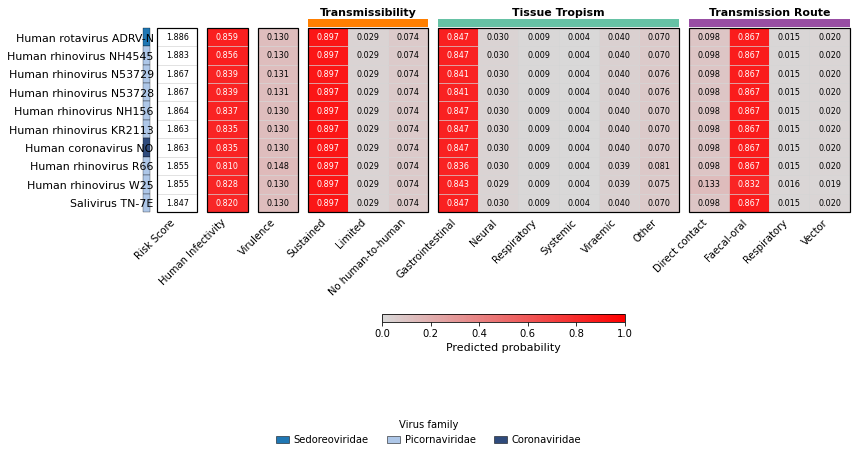

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as patches


def heatmap_phenotypes_binary():

    # ============================================================
    # 1. Read data
    # ============================================================
    dt_value = pd.read_csv("../../mid_result_updated/low_confidience_predict/data_for_fig4c.csv", sep=",", header=0)

    dt_value["virus name"] = dt_value["virus name"].str.replace(r"\s*\(\d+\)\s*$", "", regex=True).str.strip()
    dt_value["virus family"] = dt_value["virus family"].fillna("Unknown").astype(str)

    # ============================================================
    # 2. Only retain RNA viruses
    #    Genome Type字符串中包含RNA即可
    # ============================================================
    dt_value = dt_value[dt_value["Genome Type"].astype(str).str.contains("RNA", case=False, na=False)].reset_index(drop=True)

    print("Number of RNA viruses:", dt_value.shape[0])
    print("\nGenome Type distribution:")
    print(dt_value["Genome Type"].value_counts())

    # ============================================================
    # 3. Calculate Risk Score
    # ============================================================
    dt_value["Risk Score"] = dt_value["virulence"] + dt_value["infecting-human"] + dt_value["sustained human-to-human"]

    # 仅在RNA病毒中按Risk Score排序并取Top 10
    dt_sorted = dt_value.sort_values(by="Risk Score", ascending=False).reset_index(drop=True).head(10).copy()

    virus_families = dt_sorted["virus family"].tolist()

    print("\nTop 10 RNA viruses:")
    print(dt_sorted[["virus name", "Genome Type", "virus family", "Risk Score"]])

    # ============================================================
    # 4. Define heatmap columns
    # ============================================================
    columns = [
        "Risk Score",
        "infecting-human",
        "virulence",
        "sustained human-to-human",
        "limited human-to-human",
        "no human-to-human",
        "gastrointestinal",
        "neural",
        "respiratory (tissue tropism)",
        "systemic",
        "viraemic",
        "other",
        "direct contact",
        "faecal-oral",
        "respiratory (transmission route)",
        "vector"
    ]

    heatmap_df = dt_sorted.set_index("virus name")[columns].copy()

    # ============================================================
    # 5. X-axis display names
    # ============================================================
    display_names = [
        "Risk Score",
        "Human Infectivity",
        "Virulence",
        "Sustained",
        "Limited",
        "No human-to-human",
        "Gastrointestinal",
        "Neural",
        "Respiratory",
        "Systemic",
        "Viraemic",
        "Other",
        "Direct contact",
        "Faecal-oral",
        "Respiratory",
        "Vector"
    ]

    # ============================================================
    # 6. Define column positions
    # ============================================================
    gap = 0.25
    x_positions = []
    current_x = 0

    x_positions.append(current_x)
    current_x += 1 + gap

    x_positions.append(current_x)
    current_x += 1 + gap

    x_positions.append(current_x)
    current_x += 1 + gap

    for _ in range(3):
        x_positions.append(current_x)
        current_x += 1
    current_x += gap

    for _ in range(6):
        x_positions.append(current_x)
        current_x += 1
    current_x += gap

    for _ in range(4):
        x_positions.append(current_x)
        current_x += 1

    x_positions = np.array(x_positions)

    # ============================================================
    # 7. Heatmap color map
    # ============================================================
    cmap = LinearSegmentedColormap.from_list("gray_red", ["#d9d9d9", "#ff0000"])
    norm = Normalize(vmin=0, vmax=1)

    # ============================================================
    # 8. Virus family colors
    # ============================================================
    family_palette = [
        "#1F77B4",
        "#AEC7E8",
        "#2F4B7C",
        "#76A5AF",
        "#D4A72C",
        "#EDC948",
        "#B07AA1",
        "#FF9DA7",
        "#8C6D31",
        "#7F7F7F"
    ]

    unique_families = list(dict.fromkeys(virus_families))

    if len(unique_families) > len(family_palette):
        raise ValueError(f"Too many virus families ({len(unique_families)}); only {len(family_palette)} colors are defined.")

    family_colors = {family: family_palette[i] for i, family in enumerate(unique_families)}

    print("\nVirus families:")
    for family in unique_families:
        print(f"{family}: {family_colors[family]}")

    # ============================================================
    # 9. Figure
    # ============================================================
    fig, ax = plt.subplots(figsize=(12, 6))

    n_rows = heatmap_df.shape[0]
    n_cols = heatmap_df.shape[1]

    # ============================================================
    # 10. Draw heatmap
    # ============================================================
    for i in range(n_rows):
        for j in range(n_cols):
            value = heatmap_df.iloc[i, j]
            x = x_positions[j]

            if j == 0:
                facecolor = "white"
                text_color = "black"
            else:
                facecolor = cmap(norm(value))
                text_color = "black" if value < 0.5 else "white"

            ax.add_patch(patches.Rectangle((x, i), 1, 1, facecolor=facecolor, edgecolor="lightgrey", linewidth=0.5))
            ax.text(x + 0.5, i + 0.5, f"{value:.3f}", ha="center", va="center", fontsize=8, color=text_color)

    # ============================================================
    # 11. Y-axis
    # ============================================================
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(heatmap_df.index, fontsize=11)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)

    # ============================================================
    # 12. Virus family annotation strip
    # ============================================================
    family_x = -0.35
    family_width = 0.18

    for i, family in enumerate(virus_families):
        ax.add_patch(patches.Rectangle((family_x, i), family_width, 1, facecolor=family_colors[family], edgecolor="black", linewidth=0.3, clip_on=False))

    # ============================================================
    # 13. X-axis labels
    # ============================================================
    ax.set_xticks(x_positions + 0.5)
    ax.set_xticklabels(display_names, rotation=45, ha="right", fontsize=10)
    ax.xaxis.tick_bottom()
    ax.tick_params(axis="x", length=0, pad=5)

    # ============================================================
    # 14. Top group labels
    # ============================================================
    groups = {
        "Transmissibility": (3, 5),
        "Tissue Tropism": (6, 11),
        "Transmission Route": (12, 15)
    }

    group_colors = {
        "Transmissibility": "#FF7F00",
        "Tissue Tropism": "#66C2A5",
        "Transmission Route": "#984EA3"
    }

    for label, (start, end) in groups.items():
        x_start = x_positions[start]
        x_end = x_positions[end] + 1
        x_center = (x_start + x_end) / 2

        ax.plot([x_start, x_end], [-0.25, -0.25], color=group_colors[label], linewidth=8, solid_capstyle="butt", clip_on=False)
        ax.text(x_center, -0.55, label, ha="center", va="bottom", fontsize=11, fontweight="bold", clip_on=False)

    # ============================================================
    # 15. Borders
    # ============================================================
    ax.add_patch(patches.Rectangle((x_positions[0], 0), 1, n_rows, fill=False, edgecolor="black", linewidth=1.2, clip_on=False))
    ax.add_patch(patches.Rectangle((x_positions[1], 0), 1, n_rows, fill=False, edgecolor="black", linewidth=1.2, clip_on=False))
    ax.add_patch(patches.Rectangle((x_positions[2], 0), 1, n_rows, fill=False, edgecolor="black", linewidth=1.2, clip_on=False))

    for label, (start, end) in groups.items():
        x_start = x_positions[start]
        x_end = x_positions[end] + 1
        ax.add_patch(patches.Rectangle((x_start, 0), x_end - x_start, n_rows, fill=False, edgecolor="black", linewidth=1.2, clip_on=False))

    # ============================================================
    # 16. Probability colorbar
    # ============================================================
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.035, pad=0.32, shrink=0.35, aspect=30)
    cbar.set_label("Predicted probability", fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    # ============================================================
    # 17. Virus family legend
    # ============================================================
    family_handles = [patches.Patch(facecolor=family_colors[family], edgecolor="black", linewidth=0.5, label=family) for family in unique_families]

    fig.legend(
        handles=family_handles,
        title="Virus family",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.06),
        ncol=min(3, len(unique_families)),
        frameon=False,
        fontsize=10,
        title_fontsize=10,
        columnspacing=1.8,
        handletextpad=0.5,
        handlelength=1.3
    )

    # ============================================================
    # 18. Axis limits and style
    # ============================================================
    ax.set_xlim(0, x_positions[-1] + 1)
    ax.set_ylim(n_rows, -1.15)
    ax.set_xlabel("")
    ax.set_ylabel("")

    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_visible(False)

    # ============================================================
    # 19. Layout
    # ============================================================
    plt.tight_layout(rect=[0, 0.15, 1, 1])

    # ============================================================
    # 20. Save
    # ============================================================
    plt.savefig(
        "../../tables_and_figs_updated/fig4c_update.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.15
    )

    plt.show()


if __name__ == "__main__":
    heatmap_phenotypes_binary()

**⚠️ Codes for predicting virulence of low evidence viruses were applicable at `./predict_virulence_via_vhPPIpredAndGNN/`**

## Fig. 5 Classification of HPV based on virus-human PPIs

**参考文献**：2019 Cell (https://pmc.ncbi.nlm.nih.gov/articles/PMC6736651/)

**数据集构成：**

一共 38 个 HPV 样本，包括 12 个高风险HPV和 26 个低风险HPV

HR-HPV: 69, 16, 82, 53, 59, 62, 18, 68a, 97, 68b, 39, 68

LR-HPV: 114, 57, 67, 84, 86, 106, 54, 10, 27, 87, 94, 57c, 27b, 3, 72b, 102, 83, XS2, 13, 6b, 6, 125, 90, 81, 2, 43

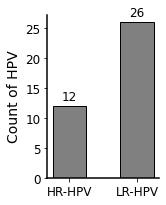

In [ ]:
##====== Fig. 5A Number of high-risk (HR) and low-risk (LR) HPVs used for classification ======##

import matplotlib.pyplot as plt
import numpy as np

def data_components():
    # 数据
    sources = ["HR-HPV", "LR-HPV"]
    counts = [12, 26]

    plt.figure(figsize=(2,3))
    x = np.arange(len(sources))
    # 柱子设置窄一些（width=0.4）
    bars = plt.bar(x, counts, color="gray", edgecolor="black", width=0.5)

    # 设置x轴刻度
    plt.xticks(x, sources, size=12)
    plt.ylabel("Count of HPV", size=14)
    plt.yticks(size=12)
    #plt.title("Data Sources", size=16)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    # 在柱子顶部加上数值
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2,
                 count + 0.5,
                 str(count),
                 ha='center', va='bottom', fontsize=12)

    # 调整 x 轴范围，让柱子之间紧凑
    #plt.xlim(-0.2, len(sources)-0.8)

    plt.savefig("../../fig_in_paper/Fig5A.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距

    # 显示图形
    plt.show()


if __name__ == "__main__":
    data_components()


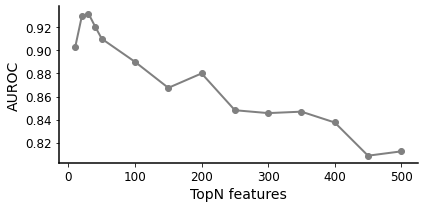

In [ ]:
##====== Fig. 5B Validation AUROC across top N important features during feature selection ======##
import os
import matplotlib.pyplot as plt


def fig_feature_importance_auroc():
    fList = ["../../data/hpv_classification/feature_importance/"+f for f in os.listdir("../../data/hpv_classification/feature_importance/") if f.endswith("summary_val.csv")]
    dt_fig = []
    for f in fList:
        dt_tmp = pd.read_csv(f)
        auc = list(dt_tmp["auc"])[0]
        topN = int(f.split("/")[-1].split("_")[2][3:])
        dt_fig.append([topN, auc])
    dt_fig = pd.DataFrame(dt_fig, columns=["TopN","AUROC"])

    # ========= 2. 按 TopN 排序 =========
    dt_fig.sort_values(by="TopN", inplace=True)
    dt_fig = dt_fig[dt_fig["TopN"]<=500].reset_index(drop=True)

    # ========= 3. 绘制折线图 =========
    plt.figure(figsize=(6,3))
    plt.plot(
        dt_fig["TopN"], dt_fig["AUROC"], 
        marker="o", linestyle="-", linewidth=2, markersize=6, color="gray"
    )
    
    # 设置坐标轴标签和标题，字体调大
    plt.xlabel('TopN features', fontsize=14)
    plt.ylabel('AUROC', fontsize=14)
    
    # 调大刻度字体
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # 去掉上方和右侧的框线，加粗左侧和下方
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    plt.tight_layout()

    plt.savefig("../../fig_in_paper/Fig5B.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()



if __name__ == "__main__":
    fig_feature_importance_auroc()

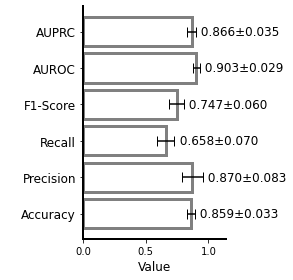

In [ ]:
##====== Fig. 5C Performance metrics (accuracy, precision, recall, F1-Score, AUROC, and AUPRC) of combining the top 30 features with Random Forest classifier on test set

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def metric_barplot():
    # 读取数据
    dt = pd.read_csv("../../data/hpv_classification/result_ppibased/rf_top30_summary_val.csv", sep=",", index_col=0)
    
    # 提取均值和标准差
    mean_vals = dt.loc["mean"]
    std_vals = dt.loc["std"]
    
    # y轴标签（指标名称）
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUROC", "AUPRC"]
    
    # 确保数据长度与指标数量匹配
    if len(mean_vals) != len(metrics):
        print(f"警告: 数据有 {len(mean_vals)} 个值，但提供了 {len(metrics)} 个指标名称")
        # 如果数据长度不匹配，只使用前n个指标
        metrics = metrics[:len(mean_vals)]
    
    y = np.arange(len(metrics))
    
    # 绘制横向柱状图（带误差棒）
    fig, ax = plt.subplots(figsize=(4, 4))
    bars = ax.barh(y, mean_vals, xerr=std_vals, capsize=5, color="none", edgecolor="gray", linewidth=3)
    
    # 在柱状图右侧加上均值 ± 标准差
    for i, (mean, std) in enumerate(zip(mean_vals, std_vals)):
        ax.text(mean + std + 0.01, i, f"{mean: .3f}±{std:.3f}", 
                ha="left", va="center", fontsize=12)
    
    # 设置坐标轴标签
    ax.set_xlabel("Value", fontsize=12)
    ax.set_ylabel(" ")
    
    # 设置y轴刻度标签
    ax.set_yticks(y)
    ax.set_yticklabels(metrics, fontsize=12)
    
    
    # 设置x轴范围，确保文本显示完整
    ax.set_xlim(0, max(mean_vals + std_vals) * 1.2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    
    
    # 调整布局
    plt.tight_layout()

    plt.savefig("../../fig_in_paper/Fig5C.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    metric_barplot()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


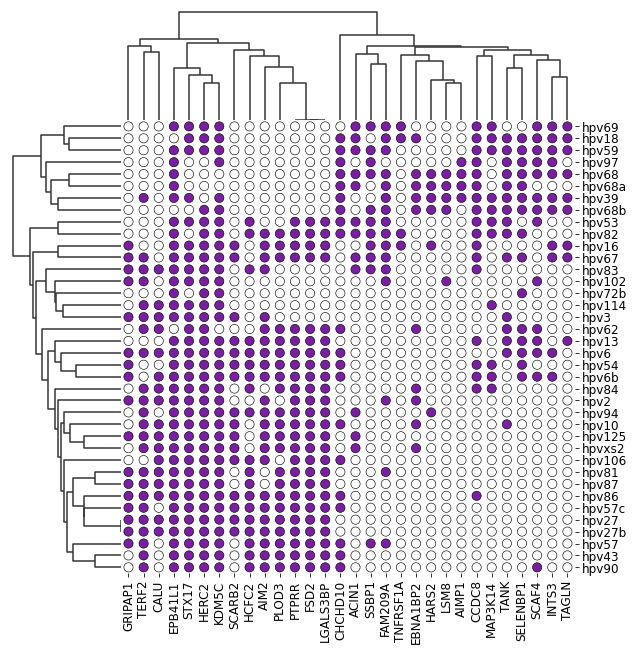

In [ ]:
##====== Fig. 5D Visualization of interactions between HPVs and the top30 human genes ======##

def figshow_difference_human_gene_bubble():
    import pandas as pd
    import numpy as np
    import mygene
    import seaborn as sns
    import matplotlib.pyplot as plt

    known_gene_of_hpv_infection = [
        "CCNB1","SMAD3","PCNA","HNRNPDL","TP53","RB1","RBL1","RBL2",
        "NCL","U2AF2","PABPC1","HNRNPA2B1","SRSF5","PCBP2"
    ]  # 已知与HPV相关基因
    
    # ========= 1. 读取数据 =========
    df = pd.read_csv('../../data/hpv_classification/ppi_binary_matrix.csv').rename(
        columns={'Unnamed: 0': 'Taxid', 'risk_label': 'Label'}
    )

    # 读取100次划分下的特征重要性，选Top30基因
    feature_importances_df = pd.read_csv("../../data/hpv_classification/feature_importance/rf_feature_importances_ppibinary.csv")
    mean_importance = feature_importances_df.mean()
    top_n_features = mean_importance.sort_values(ascending=False).head(30).index.tolist()
    dt_ppi_binary = df.loc[:, top_n_features + ["Taxid", "Label"]]
    humanprotein_list = dt_ppi_binary.columns.tolist()[0:-2]

    # ========= 2. UniProt → Gene Symbol =========
    mg = mygene.MyGeneInfo()
    out = mg.querymany(humanprotein_list, scopes="uniprot", fields="symbol", species="human")
    df_map = pd.DataFrame(out)
    df_map["symbol"].fillna("NoGene", inplace=True)
    dict_unid2gene = {df_map["query"][i]: df_map["symbol"][i] for i in range(df_map.shape[0])}

    colnames_gene = []
    for p in dt_ppi_binary.columns.tolist():
        try:
            genename = dict_unid2gene[p]
            colnames_gene.append(genename if genename != "NoGene" else p)
        except Exception:
            colnames_gene.append(p)
    dt_ppi_binary.columns = colnames_gene

    # ========= 3. 设置 Taxid 为行索引 =========
    mat = dt_ppi_binary.set_index("Taxid")
    taxid_labels = mat["Label"]
    mat = mat.drop(columns=["Label"])  # 仅保留0/1矩阵（行=Taxid，列=基因）

    # ========= 4. 聚类，但把底图格子全部遮掉 =========
    g = sns.clustermap(
        mat,
        method="average",
        metric="euclidean",
        figsize=(9, 9),
        tree_kws={"linewidths": 1.5},   # 树状图线条加粗
        cbar_pos=None,
        mask=np.ones_like(mat, dtype=bool),  # 关键：遮掉所有方格
        linewidths=0
    )
    ax = g.ax_heatmap
    ax.set_facecolor("white")  # 背景纯白

    # ========= 5. 按聚类后的顺序叠加圆圈（颜色代表0/1，大小一致） =========
    row_idx = g.dendrogram_row.reordered_ind
    col_idx = g.dendrogram_col.reordered_ind
    mat_re = mat.iloc[row_idx, col_idx]           # 重新排序后的矩阵
    vals = mat_re.values

    # 坐标（注意clustermap的像素格中心在+0.5处）
    y_pos = np.arange(vals.shape[0]) + 0.5
    x_pos = np.arange(vals.shape[1]) + 0.5
    X, Y = np.meshgrid(x_pos, y_pos)

    colors = np.where(vals.ravel() == 1, "#7A1FA2", "white")  # 1=紫色, 0=白色
    ax.scatter(
        X.ravel(), Y.ravel(),
        s=85, c=colors, edgecolors="black", linewidths=0.6
    )

    # ========= 6. 坐标轴标签 =========
    # x轴：基因名（已排序）
    ax.set_xticks(x_pos)
    ax.set_xticklabels(mat_re.columns, rotation=90, fontsize=12)

    # y轴：Taxid 并按 Label 上色
    ax.set_yticks(y_pos)
    ax.set_yticklabels(mat_re.index, rotation=0, fontsize=12)
    for tick, taxid in zip(ax.get_yticklabels(), mat_re.index):
        #tick.set_color("blue" if taxid_labels.loc[taxid] == 0 else "red")
        tick.set_color("black" if taxid_labels.loc[taxid] == 0 else "black")

    # ========= 7. x轴基因染色：已知与HPV相关的标红 =========
    for tick, gene in zip(ax.get_xticklabels(), mat_re.columns):
        if gene in known_gene_of_hpv_infection:
            tick.set_color("red")
            tick.set_fontweight("bold")

    # 去掉轴标题
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.savefig("../../fig_in_paper/Fig5D.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距

    plt.show()


if __name__ == "__main__":
    figshow_difference_human_gene_bubble()


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


High cluster genes: ['TANK', 'CCDC8', 'INTS3', 'SSBP1', 'FAM209A', 'SCAF4', 'TAGLN', 'SELENBP1', 'HARS2', 'CHCHD10', 'ACIN1', 'MAP3K14', 'TNFRSF1A', 'LSM8', 'EBNA1BP2', 'AIMP1']
Low cluster genes: ['TERF2', 'STX17', 'AIM2', 'GRIPAP1', 'HERC2', 'HCFC2', 'KDM5C', 'FSD2', 'CALU', 'PLOD3', 'LGALS3BP', 'PTPRR', 'EPB41L1', 'SCARB2']


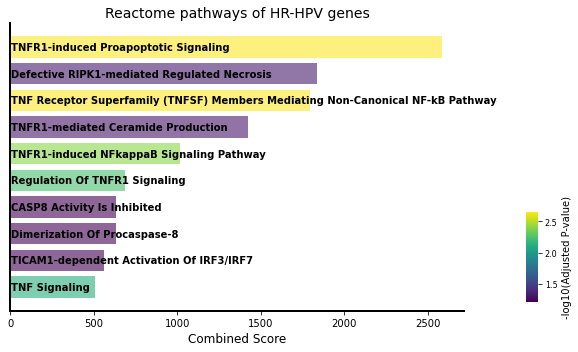

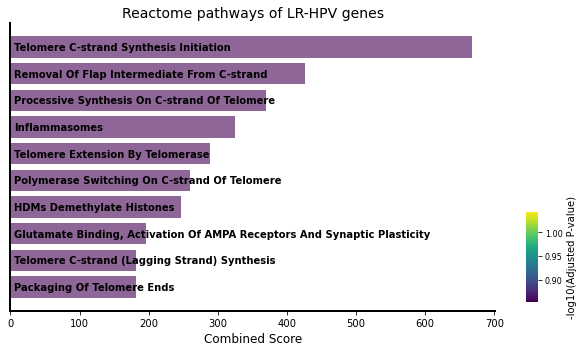

In [ ]:
def figshow_human_gene_cluster_barplot():
    import pandas as pd
    import mygene
    import matplotlib.pyplot as plt
    import seaborn as sns
    import gseapy as gp
    from scipy.cluster.hierarchy import linkage, fcluster
    import numpy as np
    import re

    # ========= 1. 读取数据 =========
    df = pd.read_csv('../../data/hpv_classification/ppi_binary_matrix.csv').rename(
        columns={'Unnamed: 0': 'Taxid', 'risk_label': 'Label'}
    )

    # 读取特征重要性，选Top30基因
    feature_importances_df = pd.read_csv("../../data/hpv_classification/feature_importance/rf_feature_importances_ppibinary.csv")
    mean_importance = feature_importances_df.mean()
    top_n_features = mean_importance.sort_values(ascending=False).head(30).index.tolist()

    # 保留这 30 个蛋白 + 标签
    dt_ppi_binary = df.loc[:, top_n_features + ["Taxid", "Label"]]

    # 蛋白列表
    humanprotein_list = dt_ppi_binary.columns.tolist()[0:-2]

    # UniProt → Gene Symbol
    mg = mygene.MyGeneInfo()
    out = mg.querymany(humanprotein_list, scopes="uniprot", fields="symbol", species="human")
    df_map = pd.DataFrame(out)
    id2symbol = df_map.set_index("query")["symbol"].dropna().to_dict()

    # 把 PPI 矩阵转为 Symbol
    dt_ppi_binary = dt_ppi_binary.rename(columns=id2symbol)

    # ========= 2. 对基因做层次聚类，分成两大类 =========
    X = dt_ppi_binary.drop(columns=["Taxid","Label"]).T
    Z = linkage(X, method="ward")
    cluster_labels = fcluster(Z, t=2, criterion='maxclust')

    gene_cluster = pd.DataFrame({"Gene": X.index, "Cluster": cluster_labels})
    high_gene_list = gene_cluster[gene_cluster["Cluster"] == 1]["Gene"].tolist()
    low_gene_list  = gene_cluster[gene_cluster["Cluster"] == 2]["Gene"].tolist()

    print("High cluster genes:", high_gene_list)
    print("Low cluster genes:", low_gene_list)

    # ========= 3. 富集 + 绘图函数 =========
    def run_enrich_and_barplot(gene_list, title, outfile):
        if len(gene_list) < 3:
            print(f"{title}: 基因数太少，跳过")
            return
    
        enr = gp.enrichr(
            gene_list=gene_list,
            gene_sets=["Reactome_2022"],
            organism="Human",
            outdir=None,
            cutoff=1
        )
        
        df_res = enr.res2d.copy()
        if df_res.empty:
            print(f"{title}: 无富集结果")
            return
    
        # 去掉 R-HSA 编号
        df_res["Term"] = df_res["Term"].apply(lambda x: re.sub(r"R-HSA-\d+", "", x).strip())
    
        # 显著性
        df_res["log10FDR"] = -np.log10(df_res["Adjusted P-value"])
        df_res.to_csv("./linshi.csv")
        # 取前10个term，按 Combined Score 排序
        df_plot = df_res.nlargest(10, "Combined Score").sort_values("Combined Score", ascending=True)
    
        # 绘制条形图
        fig, ax = plt.subplots(figsize=(8, 5))
        bars = ax.barh(
            y=range(len(df_plot)),
            width=df_plot["Combined Score"],
            color=sns.color_palette("viridis", as_cmap=True)(
                (df_plot["log10FDR"] - df_plot["log10FDR"].min()) /
                (df_plot["log10FDR"].max() - df_plot["log10FDR"].min() + 1e-9)
            ),
            alpha=0.6
        )
    
        # 在条形上加 pathway 标签（左对齐，不换行）
        for i, (bar, term) in enumerate(zip(bars, df_plot["Term"])):
            ax.text(
                x=5,   # 稍微留点空白
                y=bar.get_y() + bar.get_height()/2,
                s=term,
                ha="left", va="center",
                fontsize=10, color="black", fontweight="bold"
            )
    
        ax.set_xlabel("Combined Score", fontsize=12)
        ax.set_ylabel("")
        ax.set_title(title, fontsize=14)
        ax.set_yticks([])   # 去掉 y 轴刻度
    
        # 调整主图边框
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)

        plt.tight_layout(rect=[0,0,0.9,1])  # 给右侧留空间放颜色条
    
        # 显著性颜色条 → 缩小宽度 & 高度，放右下角
        sm = plt.cm.ScalarMappable(
            cmap="viridis",
            norm=plt.Normalize(vmin=df_plot["log10FDR"].min(), vmax=df_plot["log10FDR"].max())
        )
        sm.set_array([])
    
        # [left, bottom, width, height]，相对 figure 大小
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.25])
        cbar = plt.colorbar(sm, cax=cax)
        cbar.set_label("-log10(Adjusted P-value)", fontsize=10)
        cbar.ax.tick_params(labelsize=8)
        cbar.outline.set_visible(False)   # 去掉颜色条边框

        plt.savefig("../../fig_in_paper/"+outfile,
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
        plt.show()


    # ========= 4. 绘制高低风险簇的富集结果 =========
    run_enrich_and_barplot(high_gene_list, "Reactome pathways of HR-HPV genes",
                           "Fig5E.pdf")
    run_enrich_and_barplot(low_gene_list, "Reactome pathways of LR-HPV genes",
                           "Fig5F.pdf")


if __name__ == "__main__":
    figshow_human_gene_cluster_barplot()


## Code For Supplementary Figures

### Fig.S1

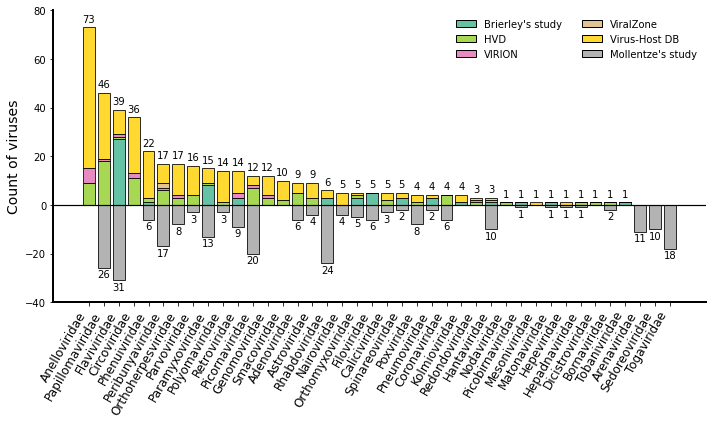

In [ ]:
## Fig.S1

def stacked_bar_data_if_infect_human_symmetric():
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.patches import Patch

    # ===== 读取数据 =====
    dt = pd.read_excel(
        "../../data/dt_for_human_infectivity_baltimore_new.xlsx",
        sheet_name="dt_for_human_infectivity"
    )
    dt_inf = dt[dt["Label_text"] == "infecting human"].copy()

    # ===== 汇总：每个病毒科 × 数据来源 =====
    df = (
        dt_inf.groupby(["vfam", "data_source_db_brief"])
        .size()
        .reset_index(name="count")
    )

    # ===== 计算排序顺序：除Mollentze's study外的来源总数 =====
    df_sum = (
        df[df["data_source_db_brief"] != "Mollentze's study"]
        .groupby("vfam")["count"]
        .sum()
        .sort_values(ascending=False)
    )
    vfam_order = df_sum.index.tolist()
    # 若有只出现在 Mollentze 的家族，也加到末尾
    others = [v for v in df["vfam"].unique() if v not in vfam_order]
    vfam_order = vfam_order + sorted(others)

    # ===== 透视表（堆积柱状图格式） =====
    df_pivot = df.pivot(index="vfam", columns="data_source_db_brief", values="count").fillna(0)
    df_pivot = df_pivot.loc[vfam_order]

    # ===== 上下分层：Mollentze 向下，其余来源向上 =====
    neg_col = "Mollentze's study"
    if neg_col not in df_pivot.columns:
        df_pivot[neg_col] = 0
    positive_sources = [c for c in df_pivot.columns if c != neg_col]
    negative_source = neg_col

    # ===== 颜色定义 =====
    color_map = {
        "Brierley's study":"#66C2A5", "HVD":"#A6D854", "VIRION":"#E78AC3",
        "Virus-Host DB":"#FFD92F", "ViralZone":"#E5C494", "Mollentze's study":"#B3B3B3"
    }

   
    # ===== x 轴刻度颜色：按 genome_type_brief 上色 =====
    fam2genome = (
        dt_inf.groupby("vfam")["genome_type_brief"]
        .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
        .to_dict()
    )
    #genome2color = {"RNA viruses": "#B2182B", "DNA viruses": "#F46D43"}
    genome2color = {"RNA viruses":"black", "DNA viruses": "black"}

    # ===== 绘图 =====
    plt.figure(figsize=(10, 6))
    ax = plt.gca()
    x = np.arange(len(df_pivot))

    # 上半部（正向）：其他来源堆积
    bottom_pos = np.zeros(len(df_pivot))
    for src in positive_sources:
        ax.bar(
            x,
            df_pivot[src].values,
            bottom=bottom_pos,
            color=color_map.get(src, "#bdbdbd"),
            edgecolor="black",
            linewidth=0.8,
            label=src
        )
        bottom_pos += df_pivot[src].values

    # 下半部（负向）：Mollentze
    ax.bar(
        x,
        -df_pivot[negative_source].values,
        bottom=np.zeros(len(df_pivot)),
        color=color_map.get(negative_source, "#bdbdbd"),
        edgecolor="black",
        linewidth=0.8,
        label=negative_source
    )

    # ===== x轴刻度与颜色 =====
    ticklabels = list(df_pivot.index)
    ax.set_xticks(x, ticklabels, rotation=60, ha="right", fontsize=12)
    for ticklabel in ax.get_xticklabels():
        fam = ticklabel.get_text()
        gt = fam2genome.get(fam, None)
        if gt in genome2color:
            ticklabel.set_color(genome2color[gt])

    # ===== y=0 轴线与刻度格式 =====
    ax.axhline(0, color="black", linewidth=1.2)
    """
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: f"{int(abs(y))}" if abs(y - int(y)) < 1e-6 else f"{abs(y):.1f}")
    )
    """
    ax.set_ylabel("Count of viruses", fontsize=14)

    # ===== 分别标注：上方=正向总数；下方=负向(Mollentze)数 =====
    pos_sum = df_pivot[positive_sources].sum(axis=1).values if positive_sources else np.zeros(len(df_pivot))
    neg_sum = df_pivot[negative_source].values

    max_pos = pos_sum.max() if len(pos_sum) else 0
    max_neg = neg_sum.max() if len(neg_sum) else 0
    ypad_pos = max(0.02 * max(1, max_pos), 0.6)
    ypad_neg = max(0.02 * max(1, max_neg), 0.6)

    for i in range(len(df_pivot)):
        # 上方只标注“除 Mollentze 外”的总数
        if pos_sum[i] > 0:
            ax.text(
                x[i], pos_sum[i] + ypad_pos, f"{int(pos_sum[i])}",
                ha="center", va="bottom", fontsize=10, fontweight="normal"
            )
        # 下方标注 Mollentze 的数
        if neg_sum[i] > 0:
            ax.text(
                x[i], -neg_sum[i] - ypad_neg, f"{int(neg_sum[i])}",
                ha="center", va="top", fontsize=10, fontweight="normal"
            )
    
    # ===== 图例（右上角，两列，先正向后负向） =====
    handles = [Patch(facecolor=color_map.get(src, "#bdbdbd"), edgecolor="black", label=src)
               for src in positive_sources + [negative_source]]
    ax.legend(
        handles=handles,
        title=None,
        loc="upper right",
        ncol=2,
        fontsize=10,
        frameon=False
    )

    ax.set_ylim(-40, 80)

    plt.tight_layout()

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    
    plt.savefig(
        "../fig_in_paper/FigS1.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.1
    )
    plt.show()



if __name__ == "__main__":
    stacked_bar_data_if_infect_human_symmetric()


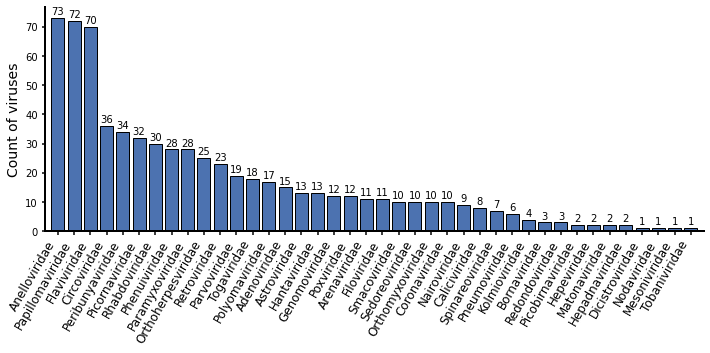

In [ ]:
def barplot_human_infecting_virus_family():
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

    # ===== 读取数据 =====
    dt = pd.read_excel(
        "../../data/dt_for_human_infectivity_baltimore_new.xlsx",
        sheet_name="dt_for_human_infectivity"
    )

    # 仅保留 infecting human
    dt_inf = dt[dt["Label_text"] == "infecting human"].copy()

    # ===== 病毒科水平统计 =====
    df_count = (
        dt_inf.groupby("vfam")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    # ===== 绘图 =====
    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    x = np.arange(len(df_count))

    ax.bar(
        x,
        df_count["count"].values,
        color="#4C72B0",        # 蓝色填充
        edgecolor="black",      # 黑色边框
        linewidth=1.0
    )

    # ===== x 轴刻度 =====
    ax.set_xticks(
        x,
        df_count["vfam"],
        rotation=60,
        ha="right",
        fontsize=12
    )

    # ===== y 轴 =====
    ax.set_ylabel("Count of viruses", fontsize=14)

    # ===== 数值标注（可选，但 Fig.S 常用）=====
    for i, v in enumerate(df_count["count"].values):
        ax.text(
            x[i],
            v + 0.5,
            str(int(v)),
            ha="center",
            va="bottom",
            fontsize=10
        )

    # ===== 坐标轴样式 =====
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(axis="both", width=1.5)
    ax.set_xlim(-0.8, len(set(dt_inf["vfam"])) - 0.2)

    plt.tight_layout()

    ## ===== 保存 =====
    plt.savefig(
        "../fig_in_paper/FigS1.pdf",
        format="pdf",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.1
    )

    plt.show()


if __name__ == "__main__":
    barplot_human_infecting_virus_family()


### Fig.S2 Comparison of the number of predicted virus-human PPIs used in human infectivity prediction

943.0 1076.0
36 33
27711 29926

[Before feature selection]
Human-infecting     n = 643
Non-human-infecting n = 543
Welch t-test: t = -1.9209, p = 5.4984e-02



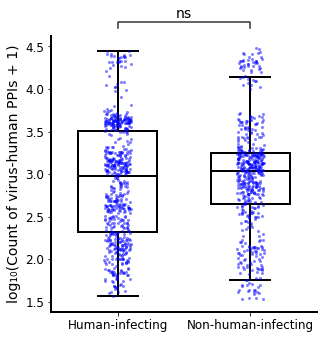

In [59]:
## Fig.S2A
def main_suppl_fig_ppi_distribution_of_humaninfecting_nonhumaninfecting_viruses(before_or_after):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    from statannotations.Annotator import Annotator
    from scipy.stats import ttest_ind

    # ===== 参数定义 =====
    if before_or_after == "before":
        title_str = "Before feature selection"
        color_points = "blue"
        save_img = "../../tables_and_figs_updated/figS1a_update.pdf"
        y_label_str = "ppi_count"          # 聚合后每病毒 PPI 数
        log_label_str = "log10_ppi_count"  # log 变换后的列名
    else:
        raise ValueError("目前只实现了 before 分支，after 请自行补充数据源")

    # ======== 读取数据（明细：每条 PPI 一行） ========
    df = pd.read_csv("../../data_updated/all_pred_ppis_final.csv",
                     sep="\t", header=0, dtype=str)

    # ======== 读取标签文件 ========
    dt3 = pd.read_excel("../../tables_and_figs_updated/Table S3_update.xlsx",
                        sheet_name="Table S3", header=1, dtype=str)
    dt3["Taxid"] = dt3["Taxid"].astype(str).str.strip()

    # 只保留标签表里有的 Taxid
    df = df[df["Taxid"].isin(set(dt3["Taxid"]))].reset_index(drop=True)

    # ======== 每个病毒的 PPI 计数 ========
    taxid_label_map = dict(zip(dt3["Taxid"], dt3["Label_text"]))
    df["group"] = df["Taxid"].map(taxid_label_map)

    df_counts = (
        df.groupby(["Taxid", "group"])
          .size()
          .reset_index(name=y_label_str)   # 关键：生成 ppi_count 列
    )
    df_counts = df_counts.dropna(subset=["group"]).reset_index(drop=True)
    df_counts = df_counts[df_counts["ppi_count"]>=30].reset_index(drop=True)
    df_counts["Taxid"].to_csv("./xx.csv", index=False)
    df_hv_tmp = df_counts[df_counts["group"]=="human-infecting"]
    df_nhv_tmp = df_counts[df_counts["group"]=="non-human-infecting"]
    print(df_hv_tmp["ppi_count"].median(), df_nhv_tmp["ppi_count"].median())
    print(df_hv_tmp["ppi_count"].min(), df_nhv_tmp["ppi_count"].min())
    print(df_hv_tmp["ppi_count"].max(), df_nhv_tmp["ppi_count"].max())

    # ===== log10(PPI + 1) =====
    df_counts[log_label_str] = np.log10(df_counts[y_label_str].astype(float) + 1)

    # ===== 显式统计检验并打印 p 值 =====
    # 注意：group 里的值是小写 human-infecting / non-human-infecting
    vals_pos = df_counts[df_counts["group"] == "human-infecting"][log_label_str]
    vals_neg = df_counts[df_counts["group"] == "non-human-infecting"][log_label_str]

    t_stat, p_value = ttest_ind(vals_pos, vals_neg, equal_var=False)

    print("\n==============================================")
    print(f"[{title_str}]")
    print(f"Human-infecting     n = {len(vals_pos)}")
    print(f"Non-human-infecting n = {len(vals_neg)}")
    print(f"Welch t-test: t = {t_stat:.4f}, p = {p_value:.4e}")
    print("==============================================\n")

    # ===== 画图用的数据：把 group 名改成带大写 H/N 的展示名（可选） =====
    plot_df = df_counts.copy()
    plot_df["group"] = plot_df["group"].map({
        "human-infecting": "Human-infecting",
        "non-human-infecting": "Non-human-infecting",
    })
    plot_df = plot_df.dropna(subset=["group"])

    # ===== 绘图 =====
    plt.figure(figsize=(4.6, 4.8))
    ax = sns.boxplot(
        data=plot_df,
        x="group",
        y=log_label_str,
        palette=["white", "white"],
        width=0.6,
        showfliers=False,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=2),
        whiskerprops=dict(linewidth=2, color="black"),
        capprops=dict(linewidth=2, color="black"),
        medianprops=dict(color="black", linewidth=2),
        order=["Human-infecting", "Non-human-infecting"],
    )

    sns.stripplot(
        data=plot_df,
        x="group",
        y=log_label_str,
        color=color_points,
        alpha=0.5,
        size=3,
        jitter=True,
        order=["Human-infecting", "Non-human-infecting"],
    )

    # ===== 显著性标注 =====
    pairs = [("Human-infecting", "Non-human-infecting")]
    annotator = Annotator(
        ax, pairs,
        data=plot_df,
        x="group", y=log_label_str,
        order=["Human-infecting", "Non-human-infecting"],
    )
    annotator.configure(
        test='t-test_ind',
        text_format='star',
        loc='outside',
        verbose=0,
        fontsize=14,
    )
    annotator.apply_and_annotate()

    # ===== 图形美化 =====
    ax.set_xlabel("")
    ax.set_ylabel("log₁₀(Count of virus-human PPIs + 1)", fontsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    sns.despine()
    plt.tight_layout()

    plt.savefig(save_img, format="pdf", dpi=300,
                bbox_inches="tight", pad_inches=0.1)
    plt.show()


if __name__ == "__main__":
    main_suppl_fig_ppi_distribution_of_humaninfecting_nonhumaninfecting_viruses(before_or_after="before")

35 5538
       Taxid  hp_count       Label_text            group
105  2017081        35  human-infecting  Human-infecting
202  2955925        36  human-infecting  Human-infecting
172  2844802        38  human-infecting  Human-infecting
225  3047956        39  human-infecting  Human-infecting
222  3047790        40  human-infecting  Human-infecting
       Taxid  hp_count       Label_text            group
392  3052474      3734  human-infecting  Human-infecting
391  3052470      3802  human-infecting  Human-infecting
195  2955291      4091  human-infecting  Human-infecting
591  3432193      4326  human-infecting  Human-infecting
495  3418650      5538  human-infecting  Human-infecting
[Before feature selection] 分组后行数：
group
Human-infecting        643
Non-human-infecting    543
dtype: int64

[Before feature selection]
Human-infecting     n = 643
Non-human-infecting n = 543
Welch t-test: t = 0.5193, p = 6.0368e-01



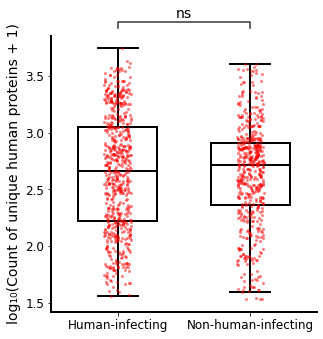

In [58]:
## Fig.S2B
def main_suppl_fig_ppi_distribution_of_humaninfecting_nonhumaninfecting_viruses(before_or_after):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    from statannotations.Annotator import Annotator
    from scipy.stats import ttest_ind

    # ===== 参数定义 =====
    if before_or_after == "before":
        title_str = "Before feature selection"
        color_points = "red"
        save_img = "../../tables_and_figs_updated/figS1b_update.pdf"
    elif before_or_after == "after":
        title_str = "After feature selection"
        color_points = "red"
        save_img = "../../tables_and_figs_updated/figS2b_after_update.pdf"
    else:
        raise ValueError("before_or_after must be 'before' or 'after'")

    y_label_str = "hp_count"
    log_label_str = "log10_hp_count"

    df_xx = pd.read_csv("./xx.csv", dtype=str)
    # ======== 读取数据（明细：每条 PPI 一行） ========
    dt_pred_vhppi = pd.read_csv(
        "../../data_updated/all_pred_ppis_final.csv",
        sep="\t", header=0, dtype=str
    )
    dt_pred_vhppi["Taxid"] = dt_pred_vhppi["Taxid"].astype(str).str.strip()
    dt_pred_vhppi = dt_pred_vhppi[dt_pred_vhppi["Taxid"].isin(df_xx["Taxid"].tolist())].reset_index(drop=True)

    # ======== 每个病毒预测到的 unique human protein 数 ========
    dt_pred_hp_count = []
    for taxid, gp in dt_pred_vhppi.groupby(by="Taxid"):
        dt_pred_hp_count.append([taxid, len(set(gp["human_unid"]))])
    dt_pred_hp_count = pd.DataFrame(dt_pred_hp_count, columns=["Taxid", "hp_count"])
    dt_pred_hp_count["Taxid"] = dt_pred_hp_count["Taxid"].astype(str).str.strip()

    # ======== 读取标签文件 ========
    dt3 = pd.read_excel(
        "../../tables_and_figs_updated/Table S3_update.xlsx",
        sheet_name="Table S3", header=1, dtype=str
    )
    dt3["Taxid"] = dt3["Taxid"].astype(str).str.strip()
    taxid_label_map = dict(zip(dt3["Taxid"], dt3["Label_text"]))

    # ======== 只保留标签表里有的 Taxid ========
    dt_pred_hp_count = dt_pred_hp_count[
        dt_pred_hp_count["Taxid"].isin(set(dt3["Taxid"]))
    ].reset_index(drop=True)
    dt_pred_hp_count["Label_text"] = dt_pred_hp_count["Taxid"].map(taxid_label_map)
    dt_pred_hp_count = dt_pred_hp_count.dropna(subset=["Label_text"]).reset_index(drop=True)

    # ======== 按感染类型拆成两组 ========
    dt_human_infecting = dt_pred_hp_count[
        dt_pred_hp_count["Label_text"] == "human-infecting"
    ].reset_index(drop=True)
    dt_human_infecting["group"] = "Human-infecting"

    dt_non_human_infecting = dt_pred_hp_count[
        dt_pred_hp_count["Label_text"] == "non-human-infecting"
    ].reset_index(drop=True)
    dt_non_human_infecting["group"] = "Non-human-infecting"

    # ======== 合并数据 ========
    df = pd.concat([dt_human_infecting, dt_non_human_infecting], ignore_index=True)
    print(dt_human_infecting["hp_count"].min(), dt_human_infecting["hp_count"].max())
    dt_xx = dt_human_infecting.sort_values(by="hp_count")
    print(dt_xx.head(5))
    print(dt_xx.tail(5))
    #df.to_csv("./xx.csv")

    # 安全检查
    print(f"[{title_str}] 分组后行数：")
    print(df.groupby("group").size())
    if df.empty:
        raise RuntimeError("df 为空：请检查 Taxid 是否匹配、Label_text 是否为预期值")

    # ===== log10(unique human proteins + 1) =====
    df[log_label_str] = np.log10(df[y_label_str].astype(float) + 1)

    # ===== 显式统计检验并打印 p 值 =====
    vals_pos = df[df["group"] == "Human-infecting"][log_label_str]
    vals_neg = df[df["group"] == "Non-human-infecting"][log_label_str]

    t_stat, p_value = ttest_ind(vals_pos, vals_neg, equal_var=False)

    print("\n==============================================")
    print(f"[{title_str}]")
    print(f"Human-infecting     n = {len(vals_pos)}")
    print(f"Non-human-infecting n = {len(vals_neg)}")
    print(f"Welch t-test: t = {t_stat:.4f}, p = {p_value:.4e}")
    print("==============================================\n")

    # ===== 绘图 =====
    plt.figure(figsize=(4.6, 4.8))
    ax = sns.boxplot(
        data=df,
        x="group",
        y=log_label_str,
        palette=["white", "white"],
        width=0.6,
        showfliers=False,
        order=["Human-infecting", "Non-human-infecting"],
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=2),
        whiskerprops=dict(linewidth=2, color="black"),
        capprops=dict(linewidth=2, color="black"),
        medianprops=dict(color="black", linewidth=2),
    )

    sns.stripplot(
        data=df,
        x="group",
        y=log_label_str,
        color=color_points,
        alpha=0.5,
        size=3,
        jitter=True,
        order=["Human-infecting", "Non-human-infecting"],
    )

    # ===== 显著性标注（星号） =====
    pairs = [("Human-infecting", "Non-human-infecting")]
    annotator = Annotator(
        ax, pairs,
        data=df,
        x="group", y=log_label_str,
        order=["Human-infecting", "Non-human-infecting"],
    )
    annotator.configure(
        test='t-test_ind',
        text_format='star',
        loc='outside',
        verbose=0,
        fontsize=14,
    )
    annotator.apply_and_annotate()

    # ===== 图形美化 =====
    ax.set_xlabel("")
    ax.set_ylabel("log₁₀(Count of unique human proteins + 1)", fontsize=14)
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    sns.despine()
    plt.tight_layout()

    plt.savefig(save_img, format="pdf", dpi=300,
                bbox_inches="tight", pad_inches=0.1)
    plt.show()


if __name__ == "__main__":
    main_suppl_fig_ppi_distribution_of_humaninfecting_nonhumaninfecting_viruses(before_or_after="before")

In [35]:
## Fig.S2A

def main_explain_suppl_fig_ppi_distribution_of_humaninfecting_nonhumaninfecting_viruses():
    import pandas as pd
    import numpy as np

    dt_pred_vhppi = pd.read_csv("../../data_updated/all_pred_ppis_final.csv", sep="\t", header=0, dtype=str)
    dt_pred_vhppi["Taxid"] = dt_pred_vhppi["Taxid"].astype(str).str.strip()

    # ======== 每个病毒预测到的 unique human protein 数 ========
    dt_pred_hp_count = []
    for taxid, gp in dt_pred_vhppi.groupby(by="Taxid"):
        dt_pred_hp_count.append([taxid, len(set(gp["human_unid"])), gp.shape[0]])
    dt_pred_hp_count = pd.DataFrame(dt_pred_hp_count, columns=["Taxid", "hp_count", "ppi_count"])
    dt_pred_hp_count["Taxid"] = dt_pred_hp_count["Taxid"].astype(str).str.strip()
    print(dt_pred_hp_count.head(3))

    # ======== 读取标签文件 ========
    dt3 = pd.read_excel(
        "../../tables_and_figs_updated/Table S3_update.xlsx",
        sheet_name="Table S3", header=1, dtype=str
    )
    dt3["Taxid"] = dt3["Taxid"].astype(str).str.strip()
    taxid_label_map = dict(zip(dt3["Taxid"], dt3["Label_text"]))

    # ======== 只保留标签表里有的 Taxid ========
    dt_pred_hp_count = dt_pred_hp_count[
        dt_pred_hp_count["Taxid"].isin(set(dt3["Taxid"]))
    ].reset_index(drop=True)
    dt_pred_hp_count["Label_text"] = dt_pred_hp_count["Taxid"].map(taxid_label_map)
    dt_pred_hp_count = dt_pred_hp_count[dt_pred_hp_count["ppi_count"]>=30].reset_index(drop=True)
    dt_pred_hp_count.to_csv("./vtaxid_with_hp_more1000.csv", sep="\t", index=False)
    print(dt_pred_hp_count.head(3))



if __name__ == "__main__":
    main_explain_suppl_fig_ppi_distribution_of_humaninfecting_nonhumaninfecting_viruses()

     Taxid  hp_count  ppi_count
0  1002359       733       1403
1  1002360       580       1361
2    10245      1356      24363
     Taxid  hp_count  ppi_count           Label_text
0  1002359       733       1403  non-human-infecting
1  1002360       580       1361  non-human-infecting
2    10245      1356      24363      human-infecting


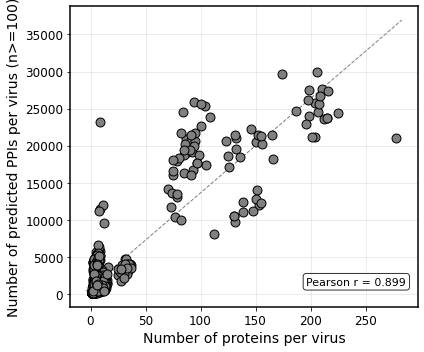

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. 准备数据
df = pd.read_csv("./vtaxid_with_hp_more1000_info.csv", sep="\t", header=0)
df = df[df["ppi_count"]>=100].reset_index(drop=True)
# 2. 计算 Pearson 相关系数
r, p = stats.pearsonr(df["num_of_vprot"], df["ppi_count"])

# 也可以用 Spearman（对非线性单调关系更稳健），按需选择
# r, p = stats.spearmanr(df["num_of_vprot"], df["ppi_count"])

# 3. 绘图
fig, ax = plt.subplots(figsize=(6, 5))

# 按 human / non-human 上色，便于区分
colors = {"human-infecting": "gray", "non-human-infecting": "gray"}
for label, group in df.groupby("Label_text"):
    ax.scatter(group["num_of_vprot"], group["ppi_count"],
               s=80, color=colors[label], label=label,
               edgecolor="black", zorder=3)

# 4. 添加回归线（可选）
slope, intercept, _, _, _ = stats.linregress(df["num_of_vprot"], df["ppi_count"])
x_line = range(df["num_of_vprot"].min() - 5,
               df["num_of_vprot"].max() + 6)
ax.plot(x_line, [slope * x + intercept for x in x_line],
        color="gray", linestyle="--", linewidth=1, zorder=2)

# 5. 在图上标注 r 和 p
ax.text(0.68, 0.1,
        f"Pearson r = {r:.3f}",
        transform=ax.transAxes,
        fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 6. 美化
ax.set_xlabel("Number of proteins per virus", fontsize=14)
ax.set_ylabel("Number of predicted PPIs per virus (n>=100)", fontsize=14)
#ax.set_title("Correlation between hp_count and num_of_vprot", fontsize=13)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
ax.grid(alpha=0.3)
#ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../../tables_and_figs_updated/figS1d_update.pdf", dpi=300, bbox_inches="tight")
plt.show()

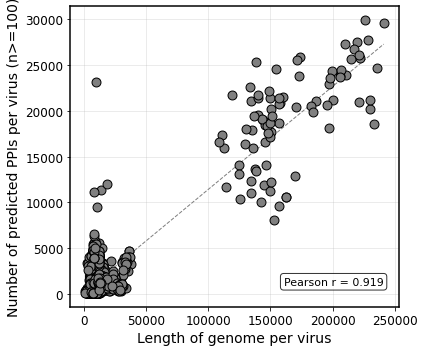

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. 准备数据
df = pd.read_csv("./vtaxid_with_hp_more1000_info.csv", sep="\t", header=0)
df = df[df["ppi_count"]>=100].reset_index(drop=True)
# 2. 计算 Pearson 相关系数
r, p = stats.pearsonr(df["len_of_vgene"], df["ppi_count"])

# 也可以用 Spearman（对非线性单调关系更稳健），按需选择
# r, p = stats.spearmanr(df["num_of_vprot"], df["ppi_count"])

# 3. 绘图
fig, ax = plt.subplots(figsize=(6, 5))

# 按 human / non-human 上色，便于区分
#colors = {"human-infecting": "red", "non-human-infecting": "green"}
colors = {"human-infecting": "gray", "non-human-infecting": "gray"}
for label, group in df.groupby("Label_text"):
    ax.scatter(group["len_of_vgene"], group["ppi_count"],
               s=80, color=colors[label], label=label,
               edgecolor="black", zorder=3)

# 4. 添加回归线（可选）
slope, intercept, _, _, _ = stats.linregress(df["len_of_vgene"], df["ppi_count"])
x_line = range(df["len_of_vgene"].min() - 5,
               df["len_of_vgene"].max() + 6)
ax.plot(x_line, [slope * x + intercept for x in x_line],
        color="gray", linestyle="--", linewidth=1, zorder=2)

# 5. 在图上标注 r 和 p
ax.text(0.65, 0.1,
        f"Pearson r = {r:.3f}",
        transform=ax.transAxes,
        fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# 6. 美化
ax.set_xlabel("Length of genome per virus", fontsize=14)
ax.set_ylabel("Number of predicted PPIs per virus (n>=100)", fontsize=14)
#ax.set_title("Correlation between hp_count and num_of_vprot", fontsize=13)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.spines["top"].set_linewidth(1.5)
ax.spines["right"].set_linewidth(1.5)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)
ax.grid(alpha=0.3)
#ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../../tables_and_figs_updated/figS1c_update.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def convert_kmer(kr):
    # ===== 读标签表（与 convert_ppi 保持一致） =====
    dt_info = pd.read_excel("./Table S3_update.xlsx", sheet_name="Table S3", header=1, dtype=str)

    # ===== 遍历 kmer npy 目录 =====
    kmer_dir = f"./data_and_res_fy_gwz_genome_proteome_kmer_embed/virusGenome_{kr}mer/"

    # ===== 先按 Taxid 收集所有片段向量（分段基因组：同一 vtaxid 多条片段） =====
    taxid_to_vecs = {}
    for fn in os.listdir(kmer_dir):
        if not fn.endswith(".npy"):
            continue
        taxid = fn.split("_")[1]
        arr = np.load(os.path.join(kmer_dir, fn)).reshape(-1).astype(float)
        taxid_to_vecs.setdefault(taxid, []).append(arr)

    # ===== 逐维求和 + 记录片段数 =====
    records = []
    for taxid, vecs in taxid_to_vecs.items():
        vec_sum = np.stack(vecs, axis=0).sum(axis=0)
        row = {"Taxid": taxid, "n_segments": len(vecs)}
        row.update({f"kmer_{i}": float(v) for i, v in enumerate(vec_sum)})
        records.append(row)

    dt_kmer = pd.DataFrame(records)

    # ===== 只保留标签表里有的病毒 =====
    dt_kmer = dt_kmer[dt_kmer["Taxid"].isin(set(dt_info["Taxid"]))].reset_index(drop=True)

    # ===== 补齐所有 Taxid（缺的填 0） =====
    all_taxids = pd.DataFrame({"Taxid": sorted(set(dt_info["Taxid"]))})
    dt_kmer = all_taxids.merge(dt_kmer, on="Taxid", how="left")

    # ===== 加 Label（第二列） =====
    dict_vtaxid_label = dict(zip(dt_info["Taxid"], dt_info["Label_text"]))
    dt_kmer.insert(1, "Label", dt_kmer["Taxid"].map(dict_vtaxid_label))

    label_map = {"human-infecting": 1, "non-human-infecting": 0}
    dt_kmer["Label"] = dt_kmer["Label"].map(label_map)
    dt_kmer = dt_kmer.dropna(subset=["Label"]).reset_index(drop=True)
    dt_kmer["Label"] = dt_kmer["Label"].astype(int)

    # ===== 缺失 kmer 的病毒填 0 =====
    feature_cols = [c for c in dt_kmer.columns if c not in ("Taxid", "Label")]
    dt_kmer[feature_cols] = dt_kmer[feature_cols].fillna(0)

    dt_kmer.to_csv(f"./data_and_res_fy_gwz_genome_proteome_kmer_embed/feat_vgenome_{kr}mer.csv", sep="\t", index=False)

    return dt_kmer

### Fig.S3 Cross-validation performance of genome- and proteome-based models for predicting human infectivity.

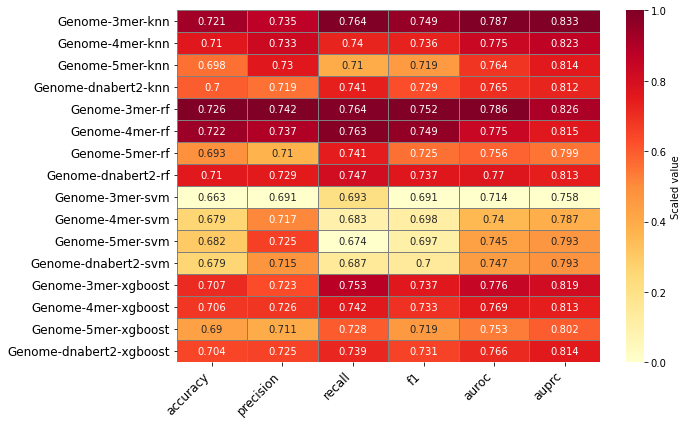

In [79]:
## Supplementary Fig. 3A Validation results combining Genome-based features (Genome-3mer, 4mer, 5mer, and DNABERT2) with four machine learning algorithms (KNN, RF, SVM, and XGBoost)

def mydataset_genome_feature_ML_selection_heatmap():
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.preprocessing import MinMaxScaler

    ml_list = ["knn","rf","svm","xgboost"]
    feature_type_list = ["3mer","4mer","5mer","dnabert2"]
    metrics = ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]

    results = []

    # 读取每个方法的均值
    for ml in ml_list:
        for feat in feature_type_list:
            method_name = f"Genome-{feat}-{ml}"
            dt_tmp = pd.read_csv(
                f"../../mid_result_updated/val/genome/{ml}_result_{feat}.csv",
                #f"../../data/supplementary_figs/human_infectivity/genome/{ml}_result_{feat}.csv",
                sep=",", header=0
            )
            mean_values = dt_tmp[metrics].mean().to_dict()
            mean_values["Method"] = method_name
            results.append(mean_values)

    df_mean = pd.DataFrame(results).set_index("Method")

    # ========== 缩放 (0-1) ==========
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_mean),
        index=df_mean.index,
        columns=df_mean.columns
    )

    # ========== 绘制热图 ==========
    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(
        df_scaled,
        annot=df_mean.round(3),   # 在热图上标注原始均值
        fmt="g",
        cmap="YlOrRd",
        cbar_kws={"label": "Scaled value"},
        linewidths=0.5,
        linecolor="grey"
    )

    #plt.title("Performance metrics heatmap of con", fontsize=14, fontweight="bold")
    plt.yticks(rotation=0, fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.ylabel("")
    plt.tight_layout()

    plt.savefig("../../tables_and_figs_updated/figS2a_update.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    mydataset_genome_feature_ML_selection_heatmap()

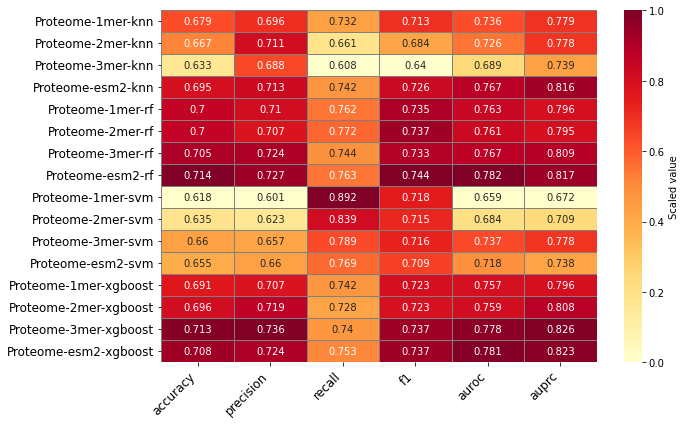

In [80]:
## Supplementary Fig. 3B Validation results combining Proteome-based features (Proteome-1mer, 2mer, 3mer, and ESM2) with the same four algorithms.

def mydataset_proteome_feature_ML_selection_heatmap():
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.preprocessing import MinMaxScaler

    ml_list = ["knn","rf","svm","xgboost"]
    feature_type_list = ["1mer","2mer","3mer","esm2"]
    metrics = ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]

    results = []

    # 读取每个方法的均值
    for ml in ml_list:
        for feat in feature_type_list:
            method_name = f"Proteome-{feat}-{ml}"
            dt_tmp = pd.read_csv(
                f"../../mid_result_updated/val/proteome/{ml}_result_{feat}.csv",
                #f"../../data/supplementary_figs/human_infectivity/proteome/{ml}_result_{feat}.csv",
                sep=",", header=0
            )
            mean_values = dt_tmp[metrics].mean().to_dict()
            mean_values["Method"] = method_name
            results.append(mean_values)

    df_mean = pd.DataFrame(results).set_index("Method")

    # ========== 缩放 (0-1) ==========
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_mean),
        index=df_mean.index,
        columns=df_mean.columns
    )

    # ========== 绘制热图 ==========
    plt.figure(figsize=(10, 6))
    ax = sns.heatmap(
        df_scaled,
        annot=df_mean.round(3),   # 在热图上标注原始均值
        fmt="g",
        cmap="YlOrRd",
        cbar_kws={"label": "Scaled value"},
        linewidths=0.5,
        linecolor="grey"
    )

    #plt.title("Performance metrics heatmap of con", fontsize=14, fontweight="bold")
    plt.yticks(rotation=0, fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.ylabel("")
    plt.tight_layout()

    plt.savefig("../../tables_and_figs_updated/figS2b_update.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    plt.show()


if __name__ == "__main__":
    mydataset_proteome_feature_ML_selection_heatmap()

### Supplementary Fig. 4 Performance of Mollentze’s and PPI-based model for predicting human infectivity on Mollentze’s dataset.

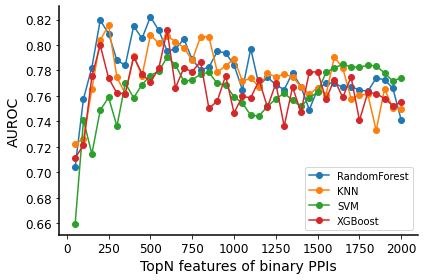

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def auroc_topN_curve_papertest():
    # 读取Excel文件
    df = []
    for i in range(50, 2050, 50):
        dt_tmp_rf = pd.read_csv(f"../../data/supplementary_figs/human_infectivity/ppi_fix/rf_top{i}_result_val.csv", sep=",", header=0)
        dt_tmp_knn = pd.read_csv(f"../../data/supplementary_figs/human_infectivity/ppi_fix/knn_top{i}_result_val.csv", sep=",", header=0)
        dt_tmp_svm = pd.read_csv(f"../../data/supplementary_figs/human_infectivity/ppi_fix/svm_top{i}_result_val.csv", sep=",", header=0)
        dt_tmp_xgb = pd.read_csv(f"../../data/supplementary_figs/human_infectivity/ppi_fix/xgboost_top{i}_result_val.csv", sep=",", header=0)
        df.append([i, dt_tmp_rf.loc[0,"auroc"], dt_tmp_knn.loc[0,"auroc"], dt_tmp_svm.loc[0,"auroc"], dt_tmp_xgb.loc[0,"auroc"]])
    
    df = pd.DataFrame(df, columns=["top","rf_auc","knn_auc","svm_auc","xgboost_auc"])
    df.to_csv("./xx.txt", sep="\t", index=False)
    #df = pd.read_excel('summary_plot_binary_ppi.xlsx')
    
    # 设置画布大小
    plt.figure(figsize=(6,4))  # 宽8英寸，高6英寸，可以根据需要调整
    
    # 图例映射字典
    label_map = {
        "RF": "RandomForest",
        "XGBOOST": "XGBoost",
        "KNN": "KNN",
        "SVM": "SVM"
    }
    
    # 绘制每一列（除了top列）对应的折线图
    for col in df.columns[1:]:
        name = col.replace('_auc', '').upper()
        label = label_map.get(name, name)  # 如果在字典中就替换，否则保持原样
        plt.plot(df['top'], df[col], marker='o', label=label)
    
    
    # 设置坐标轴标签和标题，字体调大
    plt.xlabel('TopN features of binary PPIs', fontsize=14)
    plt.ylabel('AUROC', fontsize=14)
    
    
    # 调大刻度字体
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    # 去掉上方和右侧的框线，加粗左侧和下方
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    
    # 图例字体调大
    plt.legend(fontsize=10)
    
    plt.tight_layout()
    
    plt.savefig("../fig_in_paper/FigS4_a.pdf",
                format="pdf", 
                dpi=300,  # 高分辨率
                bbox_inches="tight", # 防止内容被裁剪
                pad_inches=0.1)  # 添加少许边距
    plt.show()



if __name__ == "__main__":
    auroc_topN_curve_papertest()

0.7372635327635324
0.8423443223443223


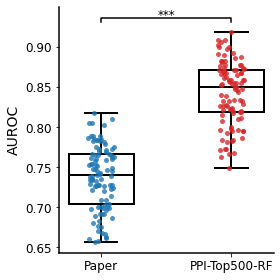

P-values vs PPI-Top500-RF:
Paper: 5.7632e-46


In [ ]:
## Supplementary Fig. 4B AUROC comparison of Mollentze’s and PPI-based model on independent test set of Mollentze’s dataset.

def boxplot_test_auroc_paperdataset():
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    
    from scipy.stats import ttest_ind
    import seaborn as sns

    dt_ppi500 = pd.read_csv("../../data/supplementary_figs/human_infectivity/ppi_fix_test/rf_top500_result.csv", sep=",", header=0)
    df = pd.read_excel("../../data/supplementary_figs/human_infectivity/result_for_figure.xlsx", sheet_name="paperdataset_test_auroc", header=0)
    df["PPI-Top500-RF"] = dt_ppi500["auroc"]
    df_long = df.melt(var_name="Method", value_name="Value")
    df_long = df_long[df_long["Method"].isin(["Paper", "PPI-Top500-RF"])].reset_index(drop=True)
    print(np.mean(df_long[df_long["Method"]=="Paper"]["Value"]))
    print(np.mean(df_long[df_long["Method"]=="PPI-Top500-RF"]["Value"]))
    
    # 手动指定顺序（保证x轴顺序固定）
    order = ["Paper", "PPI-Top500-RF"]
    palette = {
        "Paper": "#1f77b4",
        "PPI-Top500-RF": "#d62728"
    }
    
    # ========== 绘图 ==========
    plt.figure(figsize=(4,4))
    
    sns.boxplot(
        data=df_long, x="Method", y="Value",
        order=order, palette=palette, width=0.5, showfliers=False,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=2),
        whiskerprops=dict(linewidth=2, color="black"),
        capprops=dict(linewidth=2, color="black"),
        medianprops=dict(color="black", linewidth=2)
    )
    
    # 散点（按方法上色）
    for method in order:
        subset = df_long[df_long["Method"] == method]
        sns.stripplot(
            data=subset, x="Method", y="Value",
            order=order, jitter=True, size=5, alpha=0.8,
            color=palette[method]
        )
    
    plt.xticks(rotation=0, fontsize=12)
    plt.yticks(fontsize=12)
    plt.ylabel("AUROC", fontsize=14)
    plt.xlabel("")

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    
    # ========== 显著性检验 ==========
    ref = "PPI-Top500-RF"
    groups = ["Paper"]
    
    p_values = {}
    for g in groups:
        vals1 = df[g].dropna()
        vals2 = df[ref].dropna()
        stat, p = ttest_ind(vals1, vals2)
        p_values[g] = p
    
    # ========== 在图上标注显著性 ==========
    y_max = df_long["Value"].max()
    height = (df_long["Value"].max() - df_long["Value"].min()) * 0.05
    offset = height * 0.3
    
    for i, g in enumerate(groups):
        x1 = order.index(g)
        x2 = order.index(ref)
        y = y_max + (i+1)*height
        p = p_values[g]
    
        # 横线
        plt.plot([x1, x1, x2, x2], [y, y+0.005, y+0.005, y], lw=1.5, color="black")
    
        # 显著性标记
        if p < 0.001:
            text = "***"
        elif p < 0.01:
            text = "**"
        elif p < 0.05:
            text = "*"
        else:
            text = "ns"
    
        plt.text((x1+x2)/2, y+0.005-offset, text, ha="center", va="bottom", fontsize=12)
    
    plt.tight_layout()


    plt.savefig("../fig_in_paper/FigS4_b.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()
    
    # 打印具体 p 值
    print("P-values vs PPI-Top500-RF:")
    for k,v in p_values.items():
        print(f"{k}: {v:.4e}")

if __name__ == "__main__":
    boxplot_test_auroc_paperdataset()

### Supplementary Fig. 5 Cross-validation results of predicting viral transmissibility (TMS), transmission route (TRO), and tissue tropism (TT).

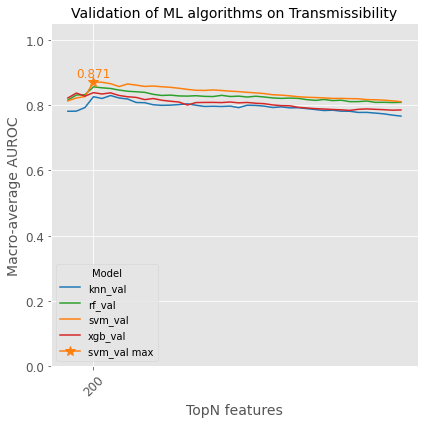

In [ ]:
## Supplementary Fig. 5A-C Validation AUROC using the TopN (N=50, 100, …, 2000) binary PPI features across machine learning algorithms (KNN, RF, SVM, and XGBoost) on prediction of transmissibility (A), transmission route (B), and tissue tropism (C).

### Supplementary Fig. 5A

import pandas as pd
import matplotlib.pyplot as plt
import os


def Transmissibility_ML_selection_val_experiment():
    plt.style.use("ggplot")
    
    colors = {
        "knn_val": "#1f77b4",
        "rf_val": "#2ca02c",
        "svm_val": "#ff7f0e",
        "xgb_val": "#d62728"
    }
    
    labels = ["Trlevel"]
    
    for label in labels:
        filename = f"../../data/supplementary_figs/transmissibility/auc_summary_{label}_v1.csv"
        if not os.path.exists(filename):
            print(f"文件不存在：{filename}")
            continue
    
        df = pd.read_csv(filename, index_col=0)
    
        plt.figure(figsize=(6, 6))
    
        global_max_val = -1
        global_max_idx = None
        global_max_model = None
    
        for model in df.columns:
            plt.plot(df.index, df[model], label=model, color=colors.get(model, None))
    
            # 查找全局最大值
            model_max = df[model].max()
            if model_max > global_max_val:
                global_max_val = model_max
                global_max_idx = df[model].idxmax()
                global_max_model = model
    
        # 标记全局最大值点
        if global_max_model:
            plt.plot(global_max_idx, global_max_val, marker='*',
                     color=colors.get(global_max_model, None), markersize=10,
                     label=f'{global_max_model} max')
            plt.text(global_max_idx, global_max_val + 0.015, f'{global_max_val:.3f}',
                     ha='center', fontsize=12, color=colors.get(global_max_model, None))
    
            # 只显示该点的x轴标签
            plt.xticks(ticks=[global_max_idx], labels=[global_max_idx], rotation=45)
        
        plt.title(f"Validation of ML algorithms on Transmissibility", fontsize=14)
        plt.xlabel("TopN features", fontsize=14)
        plt.ylabel("Macro-average AUROC", fontsize=14)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.ylim(0, 1.05)
        plt.legend(title="Model", fontsize=10)
        
        plt.tight_layout()
        
        plt.savefig("../fig_in_paper/FigS5_a.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
        
        plt.show()
        


if __name__ == "__main__":
    Transmissibility_ML_selection_val_experiment()

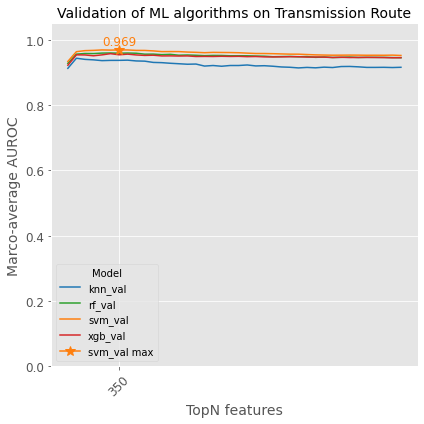

In [ ]:
### Supplementary Fig. 5B

import pandas as pd
import matplotlib.pyplot as plt
import os


def Transmission_Route_ML_selection_val_experiment():
    plt.style.use("ggplot")
    
    colors = {
        "knn_val": "#1f77b4",
        "rf_val": "#2ca02c",
        "svm_val": "#ff7f0e",
        "xgb_val": "#d62728"
    }
    
    labels = ["Trprimary"]
    
    for label in labels:
        filename = f"../../data/supplementary_figs/transmission_route/auc_summary_{label}_v1.csv"
        if not os.path.exists(filename):
            print(f"文件不存在：{filename}")
            continue
    
        df = pd.read_csv(filename, index_col=0)
    
        plt.figure(figsize=(6, 6))
    
        global_max_val = -1
        global_max_idx = None
        global_max_model = None
    
        for model in df.columns:
            plt.plot(df.index, df[model], label=model, color=colors.get(model, None))
    
            # 查找全局最大值
            model_max = df[model].max()
            if model_max > global_max_val:
                global_max_val = model_max
                global_max_idx = df[model].idxmax()
                global_max_model = model
    
        # 标记全局最大值点
        if global_max_model:
            plt.plot(global_max_idx, global_max_val, marker='*',
                     color=colors.get(global_max_model, None), markersize=10,
                     label=f'{global_max_model} max')
            plt.text(global_max_idx, global_max_val + 0.015, f'{global_max_val:.3f}',
                     ha='center', fontsize=12, color=colors.get(global_max_model, None))
    
            # 只显示该点的x轴标签
            plt.xticks(ticks=[global_max_idx], labels=[global_max_idx], rotation=45)
    
        plt.title(f"Validation of ML algorithms on Transmission Route", fontsize=14)
        plt.xlabel("TopN features", fontsize=14)
        plt.ylabel("Marco-average AUROC", fontsize=14)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.ylim(0, 1.05)
        plt.legend(title="Model", fontsize=10)
        plt.tight_layout()

        plt.savefig("../fig_in_paper/FIgS5_b.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
        
        plt.show()


if __name__ == "__main__":
    Transmission_Route_ML_selection_val_experiment()

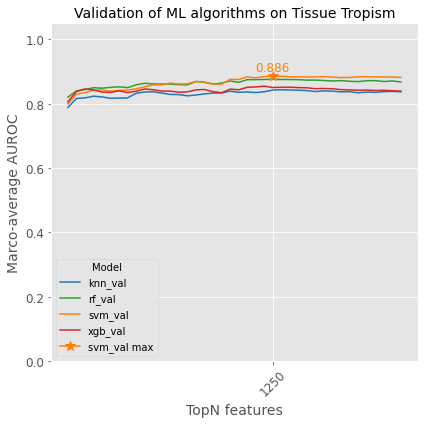

In [ ]:
### Supplementary Fig. 5C

import pandas as pd
import matplotlib.pyplot as plt
import os


def Tissue_Tropism_ML_selection_val_experiment():
    colors = {
        "knn_val": "#1f77b4",
        "rf_val": "#2ca02c",
        "svm_val": "#ff7f0e",
        "xgb_val": "#d62728"
    }
    
    labels = ["XX"]
    
    for label in labels:
        filename = f"../../data/supplementary_figs/tissue_tropism/auc_summary_Tpprimary_v1.csv"
        if not os.path.exists(filename):
            print(f"文件不存在：{filename}")
            continue
    
        df = pd.read_csv(filename, index_col=0)
    
        plt.figure(figsize=(6, 6))
    
        global_max_val = -1
        global_max_idx = None
        global_max_model = None
    
        for model in df.columns:
            plt.plot(df.index, df[model], label=model, color=colors.get(model, None))
    
            # 查找全局最大值
            model_max = df[model].max()
            if model_max > global_max_val:
                global_max_val = model_max
                global_max_idx = df[model].idxmax()
                global_max_model = model
    
        # 标记全局最大值点
        if global_max_model:
            plt.plot(global_max_idx, global_max_val, marker='*',
                     color=colors.get(global_max_model, None), markersize=10,
                     label=f'{global_max_model} max')
            plt.text(global_max_idx, global_max_val + 0.015, f'{global_max_val:.3f}',
                     ha='center', fontsize=12, color=colors.get(global_max_model, None))
    
            # 只显示该点的x轴标签
            plt.xticks(ticks=[global_max_idx], labels=[global_max_idx], rotation=45)
    
        plt.title(f"Validation of ML algorithms on Tissue Tropism", fontsize=14)
        plt.xlabel("TopN features", fontsize=14)
        plt.ylabel("Marco-average AUROC", fontsize=14)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.ylim(0, 1.05)
        plt.legend(title="Model", fontsize=10)
        plt.tight_layout()

        plt.savefig("../fig_in_paper/FigS5_c.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
        
        plt.show()


if __name__ == "__main__":
    Tissue_Tropism_ML_selection_val_experiment()

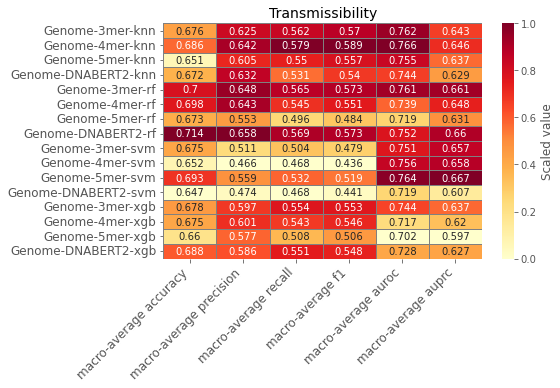

In [ ]:
## Supplementary Figure 5 D–F. Validation results combining Genome-based features (Genome-3mer, 4mer, 5mer, and DNABERT2) with six machine-learning algorithms (KNN, SVM, XGBoost, and RF) for predicting transmissibility (D), transmission route (E), and tissue tropism (F).

def transmissibility_genome_feature_ML_selection_heatmap():
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, average_precision_score
    )
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import label_binarize


    ml_list = ["knn", "rf", "svm", "xgb"]
    feature_type_list = ["3mer", "4mer", "5mer", "dnabert"]
    metrics = ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]

    results = []

    # 遍历所有方法
    for ml in ml_list:
        for feat in feature_type_list:
            method_name = f"Genome-{feat}-{ml}"
            metric_values_list = []

            # 遍历100个文件
            for idx in range(0, 100):
                if feat != "dnabert":
                    filename = f"../../data/supplementary_figs/transmissibility/val/{ml}_genome/Trlevel_{feat}/probs_split{idx}.csv"
                else:
                    filename = f"../../data/supplementary_figs/transmissibility/val/{ml}_dnabert/Trlevel/probs_split{idx}.csv"
                if not os.path.exists(filename):
                    print("缺失文件:", filename)
                    continue

                dt_tmp = pd.read_csv(filename, sep=",", header=0)
                dt_tmp.columns = ["prob_2", "prob_3", "prob_4"]+list(dt_tmp.columns)[3:]
                y_true = dt_tmp["true"].values
                y_pred = dt_tmp["pred"].values
                y_prob = dt_tmp[["prob_2", "prob_3", "prob_4"]].values
                
                # ==== 计算指标 ====
                acc = accuracy_score(y_true, y_pred)
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

                # 多分类 one-vs-rest 概率输入
                classes = [2, 3, 4]
                try:
                    y_true_bin = label_binarize(y_true, classes=classes)
                    auroc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
                except ValueError:
                    auroc = np.nan

                try:
                    y_true_bin = label_binarize(y_true, classes=classes)
                    auprc = average_precision_score(y_true_bin, y_prob, average="macro")
                except ValueError:
                    auprc = np.nan

                metric_values_list.append([acc, prec, rec, f1, auroc, auprc])

            # 对100次实验结果取均值
            if len(metric_values_list) > 0:
                mean_values = np.nanmean(metric_values_list, axis=0)
                tmp_dict = dict(zip(metrics, mean_values))
                tmp_dict["Method"] = method_name
                results.append(tmp_dict)

    # 生成 DataFrame
    df_mean = pd.DataFrame(results).set_index("Method")
    df_mean.index = df_mean.index.str.replace("dnabert", "DNABERT2", regex=False)

    # ========== 缩放 (0-1) ==========
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_mean),
        index=df_mean.index,
        columns=df_mean.columns
    )

    # ========== 绘制热图 ==========
    plt.figure(figsize=(8, 5.5))
    ax = sns.heatmap(
        df_scaled,
        annot=df_mean.round(3),   # 标注原始均值
        fmt="g",
        cmap="YlOrRd",
        cbar_kws={"label": "Scaled value"},
        linewidths=0.5,
        linecolor="grey"
    )

    plt.title("Transmissibility", fontsize=14)
    plt.yticks(rotation=0, fontsize=12)
    #plt.xticks(rotation=45, ha="right", fontsize=12)
    metrics_display = ["macro-average accuracy", "macro-average precision", "macro-average recall", 
                      "macro-average f1", "macro-average auroc", "macro-average auprc"]
    
    plt.xticks(ticks=np.arange(len(metrics)) + 0.5, 
               labels=metrics_display, 
               rotation=45, ha="right", fontsize=12)
    
    
    plt.ylabel("")
    plt.tight_layout()
    
    plt.savefig("../fig_in_paper/FigS5_d.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    transmissibility_genome_feature_ML_selection_heatmap()


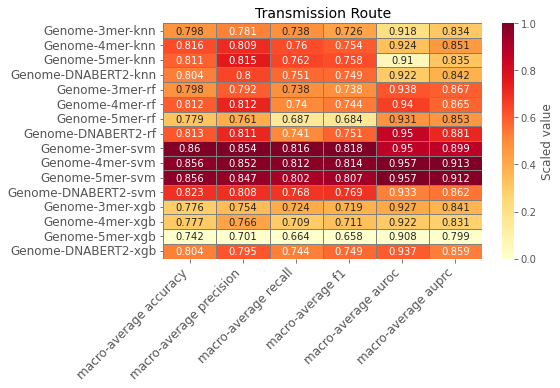

In [ ]:
def transmission_route_genome_feature_ML_selection_heatmap():
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, average_precision_score
    )
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import label_binarize


    ml_list = ["knn", "rf", "svm", "xgb"]
    feature_type_list = ["3mer", "4mer", "5mer", "dnabert"]
    metrics = ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]

    results = []

    # 遍历所有方法
    for ml in ml_list:
        for feat in feature_type_list:
            method_name = f"Genome-{feat}-{ml}"
            metric_values_list = []

            # 遍历100个文件
            for idx in range(0, 100):
                if feat != "dnabert":
                    filename = f"../../data/supplementary_figs/transmission_route/result_kmer/{ml}_genome/Trprimary_{feat}/probs_split{idx}.csv"
                else:
                    filename = f"../../data/supplementary_figs/transmission_route/result_LLM/{ml}_dnabert/Trprimary/probs_split{idx}.csv"
                if not os.path.exists(filename):
                    print("缺失文件:", filename)
                    continue

                dt_tmp = pd.read_csv(filename, sep=",", header=0)
                dt_tmp.columns = ["prob_direct contact","prob_faecal-oral","prob_respiratory","prob_vector"]+list(dt_tmp.columns)[4:]
                y_true = dt_tmp["true"].values
                y_pred = dt_tmp["pred"].values
                y_prob = dt_tmp[["prob_direct contact","prob_faecal-oral","prob_respiratory","prob_vector"]].values
                
                # ==== 计算指标 ====
                acc = accuracy_score(y_true, y_pred)
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

                # 多分类 one-vs-rest 概率输入
                classes = ["direct contact","faecal-oral","respiratory","vector"]
                try:
                    y_true_bin = label_binarize(y_true, classes=classes)
                    auroc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
                except ValueError:
                    auroc = np.nan

                try:
                    y_true_bin = label_binarize(y_true, classes=classes)
                    auprc = average_precision_score(y_true_bin, y_prob, average="macro")
                except ValueError:
                    auprc = np.nan

                metric_values_list.append([acc, prec, rec, f1, auroc, auprc])

            # 对100次实验结果取均值
            if len(metric_values_list) > 0:
                mean_values = np.nanmean(metric_values_list, axis=0)
                tmp_dict = dict(zip(metrics, mean_values))
                tmp_dict["Method"] = method_name
                results.append(tmp_dict)

    # 生成 DataFrame
    df_mean = pd.DataFrame(results).set_index("Method")
    df_mean.index = df_mean.index.str.replace("dnabert", "DNABERT2", regex=False)

    # ========== 缩放 (0-1) ==========
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_mean),
        index=df_mean.index,
        columns=df_mean.columns
    )

    # ========== 绘制热图 ==========
    plt.figure(figsize=(8, 5.5))
    ax = sns.heatmap(
        df_scaled,
        annot=df_mean.round(3),   # 标注原始均值
        fmt="g",
        cmap="YlOrRd",
        cbar_kws={"label": "Scaled value"},
        linewidths=0.5,
        linecolor="grey"
    )

    plt.title("Transmission Route", fontsize=14)
    plt.yticks(rotation=0, fontsize=12)
    #plt.xticks(rotation=45, ha="right", fontsize=12)
    metrics_display = ["macro-average accuracy", "macro-average precision", "macro-average recall", 
                      "macro-average f1", "macro-average auroc", "macro-average auprc"]
    
    plt.xticks(ticks=np.arange(len(metrics)) + 0.5, 
               labels=metrics_display, 
               rotation=45, ha="right", fontsize=12)
    
    
    plt.ylabel("")
    plt.tight_layout()

    plt.savefig("../fig_in_paper/FigS5_e.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    transmission_route_genome_feature_ML_selection_heatmap()


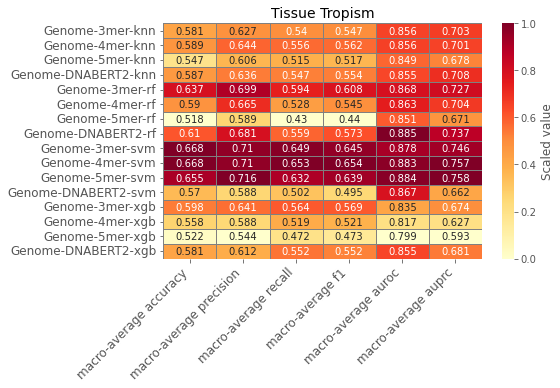

In [ ]:
## FigS5_f
def tissue_tropism_genome_feature_ML_selection_heatmap():
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, average_precision_score
    )
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import label_binarize

    
    ml_list = ["knn", "rf", "svm", "xgb"]
    feature_type_list = ["3mer", "4mer", "5mer", "dnabert"]
    metrics = ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]

    results = []

    # 遍历所有方法
    for ml in ml_list:
        for feat in feature_type_list:
            method_name = f"Genome-{feat}-{ml}"
            metric_values_list = []

            # 遍历100个文件
            for idx in range(0, 100):
                if feat != "dnabert":
                    filename = f"../../data/supplementary_figs/tissue_tropism/result_20other_kmer/{ml}_genome/Tpprimary_{feat}/probs_split{idx}.csv"
                else:
                    filename = f"../../data/supplementary_figs/tissue_tropism/result_20other_LLM/{ml}_dnabert/Tpprimary/probs_split{idx}.csv"
                if not os.path.exists(filename):
                    print("缺失文件:", filename)
                    continue

                dt_tmp = pd.read_csv(filename, sep=",", header=0)
                dt_tmp.columns = ["prob_gastrointestinal","prob_neural","prob_other","prob_respiratory","prob_systemic","prob_viraemic"]+list(dt_tmp.columns)[6:]
                y_true = dt_tmp["true"].values
                y_pred = dt_tmp["pred"].values
                y_prob = dt_tmp[["prob_gastrointestinal","prob_neural","prob_other","prob_respiratory","prob_systemic","prob_viraemic"]].values
                
                # ==== 计算指标 ====
                acc = accuracy_score(y_true, y_pred)
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
                
                # 多分类 one-vs-rest 概率输入
                classes = np.unique(y_true)
                if len(classes) < 2:
                    auroc = np.nan
                    auprc = np.nan
                else:
                    try:
                        y_true_bin = label_binarize(y_true, classes=classes)
                        auroc = roc_auc_score(y_true_bin, y_prob[:, :len(classes)], 
                                              average="macro", multi_class="ovr")
                    except ValueError:
                        auroc = np.nan

                    try:
                        y_true_bin = label_binarize(y_true, classes=classes)
                        auprc = average_precision_score(y_true_bin, y_prob[:, :len(classes)], 
                                                        average="macro")
                    except ValueError:
                        auprc = np.nan

                metric_values_list.append([acc, prec, rec, f1, auroc, auprc])

            # 对100次实验结果取均值
            if len(metric_values_list) > 0:
                mean_values = np.nanmean(metric_values_list, axis=0)
                tmp_dict = dict(zip(metrics, mean_values))
                tmp_dict["Method"] = method_name
                results.append(tmp_dict)

    # 生成 DataFrame
    df_mean = pd.DataFrame(results).set_index("Method")
    df_mean.index = df_mean.index.str.replace("dnabert", "DNABERT2", regex=False)

    # ========== 缩放 (0-1) ==========
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_mean),
        index=df_mean.index,
        columns=df_mean.columns
    )

    # ========== 绘制热图 ==========
    plt.figure(figsize=(8, 5.5))
    ax = sns.heatmap(
        df_scaled,
        annot=df_mean.round(3),   # 标注原始均值
        fmt="g",
        cmap="YlOrRd",
        cbar_kws={"label": "Scaled value"},
        linewidths=0.5,
        linecolor="grey"
    )

    plt.title("Tissue Tropism", fontsize=14)
    plt.yticks(rotation=0, fontsize=12)
    #plt.xticks(rotation=45, ha="right", fontsize=12)
    metrics_display = ["macro-average accuracy", "macro-average precision", "macro-average recall", 
                      "macro-average f1", "macro-average auroc", "macro-average auprc"]
    
    plt.xticks(ticks=np.arange(len(metrics)) + 0.5, 
               labels=metrics_display, 
               rotation=45, ha="right", fontsize=12)
    
    
    plt.ylabel("")
    plt.tight_layout()

    plt.savefig("../fig_in_paper/FigS5_f.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    tissue_tropism_genome_feature_ML_selection_heatmap()


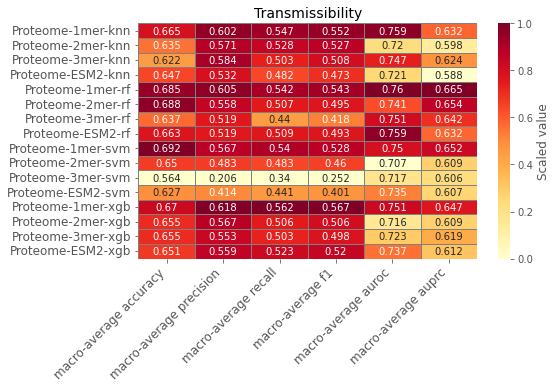

In [ ]:
## Supplementary Figure 5 G-I Validation results combining Proteome-based features (Proteome-1mer, 2mer, 3mer, and ESM2) with the same six algorithms for predicting transmissibility (G), transmission route (H), and tissue tropism (I).

def transmissibility_proteome_feature_ML_selection_heatmap():
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, average_precision_score
    )
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import label_binarize

    ml_list = ["knn", "rf", "svm", "xgb"]
    feature_type_list = ["1mer", "2mer", "3mer", "esm"]
    metrics = ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]

    results = []

    # 遍历所有方法
    for ml in ml_list:
        for feat in feature_type_list:
            method_name = f"Proteome-{feat}-{ml}"
            metric_values_list = []

            # 遍历100个文件
            for idx in range(0, 100):
                if feat != "esm":
                    filename = f"../../data/supplementary_figs/transmissibility/val/{ml}_proteome/Trlevel_{feat}/probs_split{idx}.csv"
                else:
                    filename = f"../../data/supplementary_figs/transmissibility/val/{ml}_esm/Trlevel/probs_split{idx}.csv"
                if not os.path.exists(filename):
                    print("缺失文件:", filename)
                    continue

                dt_tmp = pd.read_csv(filename, sep=",", header=0)
                dt_tmp.columns = ["prob_2", "prob_3", "prob_4"]+list(dt_tmp.columns)[3:]
                y_true = dt_tmp["true"].values
                y_pred = dt_tmp["pred"].values
                y_prob = dt_tmp[["prob_2", "prob_3", "prob_4"]].values
                
                # ==== 计算指标 ====
                acc = accuracy_score(y_true, y_pred)
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

                # 多分类 one-vs-rest 概率输入
                classes = [2, 3, 4]
                try:
                    y_true_bin = label_binarize(y_true, classes=classes)
                    auroc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
                except ValueError:
                    auroc = np.nan

                try:
                    y_true_bin = label_binarize(y_true, classes=classes)
                    auprc = average_precision_score(y_true_bin, y_prob, average="macro")
                except ValueError:
                    auprc = np.nan

                metric_values_list.append([acc, prec, rec, f1, auroc, auprc])

            # 对100次实验结果取均值
            if len(metric_values_list) > 0:
                mean_values = np.nanmean(metric_values_list, axis=0)
                tmp_dict = dict(zip(metrics, mean_values))
                tmp_dict["Method"] = method_name
                results.append(tmp_dict)

    # 生成 DataFrame
    df_mean = pd.DataFrame(results).set_index("Method")
    df_mean.index = df_mean.index.str.replace("esm", "ESM2", regex=False)

    # ========== 缩放 (0-1) ==========
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_mean),
        index=df_mean.index,
        columns=df_mean.columns
    )

    # ========== 绘制热图 ==========
    plt.figure(figsize=(8, 5.5))
    ax = sns.heatmap(
        df_scaled,
        annot=df_mean.round(3),   # 标注原始均值
        fmt="g",
        cmap="YlOrRd",
        cbar_kws={"label": "Scaled value"},
        linewidths=0.5,
        linecolor="grey"
    )

    plt.title("Transmissibility", fontsize=14)
    plt.yticks(rotation=0, fontsize=12)
    #plt.xticks(rotation=45, ha="right", fontsize=12)
    metrics_display = ["macro-average accuracy", "macro-average precision", "macro-average recall", 
                      "macro-average f1", "macro-average auroc", "macro-average auprc"]
    
    plt.xticks(ticks=np.arange(len(metrics)) + 0.5, 
               labels=metrics_display, 
               rotation=45, ha="right", fontsize=12)
    
    
    plt.ylabel("")
    plt.tight_layout()

    plt.savefig("../fig_in_paper/FigS5_g.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    plt.show()


if __name__ == "__main__":
    transmissibility_proteome_feature_ML_selection_heatmap()


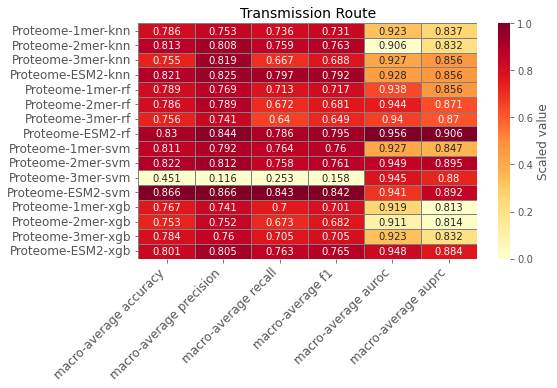

In [ ]:
def transmission_route_proteome_feature_ML_selection_heatmap():
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, average_precision_score
    )
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import label_binarize
    
    ml_list = ["knn", "rf", "svm", "xgb"]
    feature_type_list = ["1mer", "2mer", "3mer", "esm"]
    metrics = ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]

    results = []

    # 遍历所有方法
    for ml in ml_list:
        for feat in feature_type_list:
            method_name = f"Proteome-{feat}-{ml}"
            metric_values_list = []

            # 遍历100个文件
            for idx in range(0, 100):
                if feat != "esm":
                    filename = f"../../data/supplementary_figs/transmission_route/result_kmer/{ml}_proteome/Trprimary_{feat}/probs_split{idx}.csv"
                else:
                    filename = f"../../data/supplementary_figs/transmission_route/result_LLM/{ml}_esm/Trprimary/probs_split{idx}.csv"
                if not os.path.exists(filename):
                    print("缺失文件:", filename)
                    continue

                dt_tmp = pd.read_csv(filename, sep=",", header=0)
                dt_tmp.columns = ["prob_direct contact","prob_faecal-oral","prob_respiratory","prob_vector"]+list(dt_tmp.columns)[4:]
                y_true = dt_tmp["true"].values
                y_pred = dt_tmp["pred"].values
                y_prob = dt_tmp[["prob_direct contact","prob_faecal-oral","prob_respiratory","prob_vector"]].values
                
                # ==== 计算指标 ====
                acc = accuracy_score(y_true, y_pred)
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

                # 多分类 one-vs-rest 概率输入
                classes = ["direct contact","faecal-oral","respiratory","vector"]
                try:
                    y_true_bin = label_binarize(y_true, classes=classes)
                    auroc = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
                except ValueError:
                    auroc = np.nan

                try:
                    y_true_bin = label_binarize(y_true, classes=classes)
                    auprc = average_precision_score(y_true_bin, y_prob, average="macro")
                except ValueError:
                    auprc = np.nan

                metric_values_list.append([acc, prec, rec, f1, auroc, auprc])

            # 对100次实验结果取均值
            if len(metric_values_list) > 0:
                mean_values = np.nanmean(metric_values_list, axis=0)
                tmp_dict = dict(zip(metrics, mean_values))
                tmp_dict["Method"] = method_name
                results.append(tmp_dict)

    # 生成 DataFrame
    df_mean = pd.DataFrame(results).set_index("Method")
    df_mean.index = df_mean.index.str.replace("esm", "ESM2", regex=False)
    
    # ========== 缩放 (0-1) ==========
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_mean),
        index=df_mean.index,
        columns=df_mean.columns
    )

    # ========== 绘制热图 ==========
    plt.figure(figsize=(8, 5.5))
    ax = sns.heatmap(
        df_scaled,
        annot=df_mean.round(3),   # 标注原始均值
        fmt="g",
        cmap="YlOrRd",
        cbar_kws={"label": "Scaled value"},
        linewidths=0.5,
        linecolor="grey"
    )

    plt.title("Transmission Route", fontsize=14)
    plt.yticks(rotation=0, fontsize=12)
    #plt.xticks(rotation=45, ha="right", fontsize=12)
    metrics_display = ["macro-average accuracy", "macro-average precision", "macro-average recall", 
                      "macro-average f1", "macro-average auroc", "macro-average auprc"]
    
    plt.xticks(ticks=np.arange(len(metrics)) + 0.5, 
               labels=metrics_display, 
               rotation=45, ha="right", fontsize=12)
    
    
    plt.ylabel("")
    plt.tight_layout()

    plt.savefig("../fig_in_paper/FigS5_h.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    transmission_route_proteome_feature_ML_selection_heatmap()


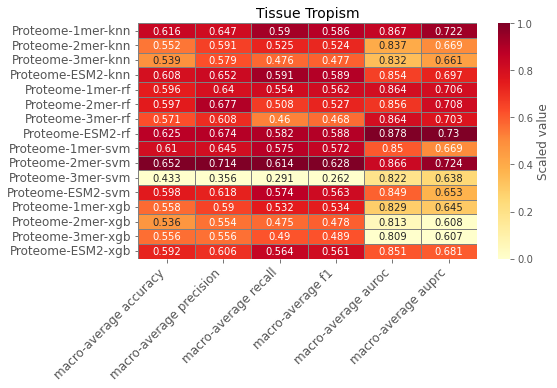

In [ ]:
def tissue_tropism_proteome_feature_ML_selection_heatmap():
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, average_precision_score
    )
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import label_binarize
    
    ml_list = ["knn", "rf", "svm", "xgb"]
    feature_type_list = ["1mer", "2mer", "3mer", "esm"]
    metrics = ["accuracy", "precision", "recall", "f1", "auroc", "auprc"]

    results = []

    # 遍历所有方法
    for ml in ml_list:
        for feat in feature_type_list:
            method_name = f"Proteome-{feat}-{ml}"
            metric_values_list = []

            # 遍历100个文件
            for idx in range(0, 100):
                if feat != "esm":
                    filename = f"../../data/supplementary_figs/tissue_tropism/result_20other_kmer/{ml}_proteome/Tpprimary_{feat}/probs_split{idx}.csv"
                else:
                    filename = f"../../data/supplementary_figs/tissue_tropism/result_20other_LLM/{ml}_esm/Tpprimary/probs_split{idx}.csv"
                if not os.path.exists(filename):
                    print("缺失文件:", filename)
                    continue

                dt_tmp = pd.read_csv(filename, sep=",", header=0)
                dt_tmp.columns = ["prob_gastrointestinal","prob_neural","prob_other","prob_respiratory","prob_systemic","prob_viraemic"]+list(dt_tmp.columns)[6:]
                y_true = dt_tmp["true"].values
                y_pred = dt_tmp["pred"].values
                y_prob = dt_tmp[["prob_gastrointestinal","prob_neural","prob_other","prob_respiratory","prob_systemic","prob_viraemic"]].values
                
                # ==== 计算指标 ====
                acc = accuracy_score(y_true, y_pred)
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
                f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
                
                # 多分类 one-vs-rest 概率输入
                classes = np.unique(y_true)
                if len(classes) < 2:
                    auroc = np.nan
                    auprc = np.nan
                else:
                    try:
                        y_true_bin = label_binarize(y_true, classes=classes)
                        auroc = roc_auc_score(y_true_bin, y_prob[:, :len(classes)], 
                                              average="macro", multi_class="ovr")
                    except ValueError:
                        auroc = np.nan

                    try:
                        y_true_bin = label_binarize(y_true, classes=classes)
                        auprc = average_precision_score(y_true_bin, y_prob[:, :len(classes)], 
                                                        average="macro")
                    except ValueError:
                        auprc = np.nan

                metric_values_list.append([acc, prec, rec, f1, auroc, auprc])

            # 对100次实验结果取均值
            if len(metric_values_list) > 0:
                mean_values = np.nanmean(metric_values_list, axis=0)
                tmp_dict = dict(zip(metrics, mean_values))
                tmp_dict["Method"] = method_name
                results.append(tmp_dict)

    # 生成 DataFrame
    df_mean = pd.DataFrame(results).set_index("Method")
    df_mean.index = df_mean.index.str.replace("esm", "ESM2", regex=False)

    # ========== 缩放 (0-1) ==========
    scaler = MinMaxScaler()
    df_scaled = pd.DataFrame(
        scaler.fit_transform(df_mean),
        index=df_mean.index,
        columns=df_mean.columns
    )

    # ========== 绘制热图 ==========
    plt.figure(figsize=(8, 5.5))
    ax = sns.heatmap(
        df_scaled,
        annot=df_mean.round(3),   # 标注原始均值
        fmt="g",
        cmap="YlOrRd",
        cbar_kws={"label": "Scaled value"},
        linewidths=0.5,
        linecolor="grey"
    )

    plt.title("Tissue Tropism", fontsize=14)
    plt.yticks(rotation=0, fontsize=12)
    #plt.xticks(rotation=45, ha="right", fontsize=12)
    metrics_display = ["macro-average accuracy", "macro-average precision", "macro-average recall", 
                      "macro-average f1", "macro-average auroc", "macro-average auprc"]
    
    plt.xticks(ticks=np.arange(len(metrics)) + 0.5, 
               labels=metrics_display, 
               rotation=45, ha="right", fontsize=12)
    
    
    plt.ylabel("")
    plt.tight_layout()

    plt.savefig("../fig_in_paper/FigS5_i.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    plt.show()


if __name__ == "__main__":
    tissue_tropism_proteome_feature_ML_selection_heatmap()


### Supplementary Fig. 6 Human infectivity prediction for potentially human-infecting viruses using the PPI-based model.

0.1401708074534161 0.92


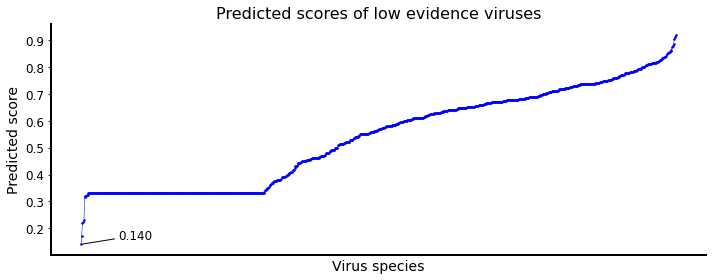

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def res_low_evidence_virus():

    # ===== 读入并排序 =====
    dt = pd.read_csv("../../mid_result_updated/low_confidience_predict/human_infectivity/rf_top1000_low_confidence_prediction_score.csv")
    dt.columns = ["Taxid","pred_label", "pred_score"]
    #dt = dt[dt["pred_label"]==1].reset_index(drop=True)
    #dt = pd.read_csv("../../data/low_evidence_virus/v403_low_evidence_human_infectivity_pred_score.csv")
    dt_sorted = dt.sort_values(by="pred_score", ascending=True).reset_index(drop=True)
    #dt_sorted.to_csv("./v573_low_evidence_human_infectivity_pred_score.csv", sep="\t", index=False)

    # ===== 找最小值 =====
    min_idx = dt_sorted["pred_score"].idxmin()
    min_val = dt_sorted.loc[min_idx, "pred_score"]
    print(dt_sorted["pred_score"].min(), dt_sorted["pred_score"].max())

    # ===== 创建画布（明确背景）=====
    plt.figure(figsize=(10, 4))
    plt.plot(
        range(len(dt_sorted)),
        dt_sorted["pred_score"],
        marker="o",
        markersize=1.5,
        linewidth=0.5,
        color="blue"
    )

    plt.xlabel("Virus species", fontsize=14)
    plt.ylabel("Predicted score", fontsize=14)
    plt.title("Predicted scores of low evidence viruses", fontsize=16)

    plt.xticks([])
    plt.yticks(fontsize=12)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    # 标注最小值
    ax.annotate(
        f"{min_val:.3f}",  # 显示三位小数
        xy=(min_idx, min_val),             # 数据点
        xytext=(min_idx+50, min_val+0.02), # 偏移位置
        arrowprops=dict(arrowstyle="-", color="black", lw=1),
        fontsize=12,
        color="black"
    )

    plt.tight_layout()

    plt.savefig("../../tables_and_figs_updated/figS5_update.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    res_low_evidence_virus()


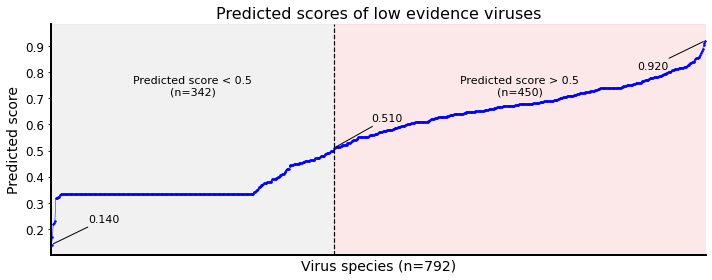

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


def res_low_evidence_virus():

    # ===== 1. 读入并排序 =====
    dt = pd.read_csv("../../mid_result_updated/low_confidience_predict/human_infectivity/rf_top1000_low_confidence_prediction_score.csv")
    dt.columns = ["Taxid", "pred_label", "pred_score"]
    dt_sorted = dt.sort_values(by="pred_score", ascending=True).reset_index(drop=True)

    # ===== 2. 基本统计 =====
    total_n = dt_sorted.shape[0]
    n_low = (dt_sorted["pred_score"] <= 0.5).sum()
    n_high = (dt_sorted["pred_score"] > 0.5).sum()

    # 全部病毒最低分和最高分
    min_idx = dt_sorted["pred_score"].idxmin()
    max_idx = dt_sorted["pred_score"].idxmax()
    min_val = dt_sorted.loc[min_idx, "pred_score"]
    max_val = dt_sorted.loc[max_idx, "pred_score"]

    # score < 0.5中的最高分
    low_part = dt_sorted[dt_sorted["pred_score"] <= 0.5]
    low_max_idx = low_part["pred_score"].idxmax()
    low_max_val = low_part.loc[low_max_idx, "pred_score"]

    # score > 0.5中的最低分
    high_part = dt_sorted[dt_sorted["pred_score"] > 0.5]
    high_min_idx = high_part["pred_score"].idxmin()
    high_min_val = high_part.loc[high_min_idx, "pred_score"]

    # 0.5阈值对应的x轴分界位置
    threshold_x = n_low - 0.5

    # ===== 3. 创建画布 =====
    fig, ax = plt.subplots(figsize=(10, 4))

    # ===== 4. 左右背景 =====
    ax.axvspan(-0.5, threshold_x, color="#D9D9D9", alpha=0.35, zorder=0)
    ax.axvspan(threshold_x, total_n - 0.5, color="#F4A6A6", alpha=0.25, zorder=0)

    # ===== 5. 预测分数曲线 =====
    ax.plot(range(total_n), dt_sorted["pred_score"], marker="o", markersize=1.5, linewidth=0.5, color="blue", zorder=2)

    # ===== 6. 0.5阈值对应的竖直虚线 =====
    ax.axvline(x=threshold_x, color="black", linestyle="--", linewidth=1.2, zorder=3)

    # ===== 7. 左右区域文字 =====
    y_min = dt_sorted["pred_score"].min()
    y_max = dt_sorted["pred_score"].max()
    y_range = y_max - y_min
    text_y = y_min + y_range * 0.78

    if n_low > 0:
        ax.text((threshold_x - 0.5) / 2, text_y, f"Predicted score < 0.5\n(n={n_low})", ha="center", va="center", fontsize=11, color="black")

    if n_high > 0:
        ax.text(threshold_x + (total_n - 0.5 - threshold_x) / 2, text_y, f"Predicted score > 0.5\n(n={n_high})", ha="center", va="center", fontsize=11, color="black")

    # ===== 8. 标注全部病毒最低分 =====
    ax.annotate(
        f"{min_val:.3f}",
        xy=(min_idx, min_val),
        xytext=(min_idx + total_n * 0.08, min_val + y_range * 0.10),
        ha="center", va="bottom", fontsize=11, color="black",
        arrowprops=dict(arrowstyle="-", color="black", linewidth=1.0),
        zorder=4
    )

    ## ===== 9. 标注 score < 0.5 部分的最高分 =====
    #ax.annotate(
    #    f"{low_max_val:.3f}",
    #    xy=(low_max_idx, low_max_val),
    #    xytext=(low_max_idx - total_n * 0.08, low_max_val - y_range * 0.12),
    #    ha="center", va="top", fontsize=11, color="black",
    #    arrowprops=dict(arrowstyle="-", color="black", linewidth=1.0),
    #    zorder=4
    #)

    # ===== 10. 标注 score > 0.5 部分的最低分 =====
    ax.annotate(
        f"{high_min_val:.3f}",
        xy=(high_min_idx, high_min_val),
        xytext=(high_min_idx + total_n * 0.08, high_min_val + y_range * 0.12),
        ha="center", va="bottom", fontsize=11, color="black",
        arrowprops=dict(arrowstyle="-", color="black", linewidth=1.0),
        zorder=4
    )

    # ===== 11. 标注全部病毒最高分 =====
    ax.annotate(
        f"{max_val:.3f}",
        xy=(max_idx, max_val),
        xytext=(max_idx - total_n * 0.08, max_val - y_range * 0.10),
        ha="center", va="top", fontsize=11, color="black",
        arrowprops=dict(arrowstyle="-", color="black", linewidth=1.0),
        zorder=4
    )

    # ===== 12. 坐标轴 =====
    ax.set_xlabel(f"Virus species (n={total_n})", fontsize=14)
    ax.set_ylabel("Predicted score", fontsize=14)
    ax.set_title("Predicted scores of low evidence viruses", fontsize=16)

    ax.set_xlim(-0.5, total_n - 0.5)
    ax.set_ylim(y_min - y_range * 0.05, y_max + y_range * 0.08)
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=12)

    # ===== 13. Figure style =====
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    # ===== 14. Layout =====
    plt.tight_layout()

    # ===== 15. 保存 =====
    plt.savefig("../../tables_and_figs_updated/figS5_update.pdf", format="pdf", dpi=300, bbox_inches="tight", pad_inches=0.1)

    plt.show()


if __name__ == "__main__":
    res_low_evidence_virus()

### Supplementary Fig. 7 Distribution of SHAP values for human genes predicted to interact with HPVs.

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
18 input query terms found dup hits:	[('P47929', 2), ('P0DP23', 3), ('Q9ULR0', 2), ('P84243', 2), ('Q71DI3', 3), ('Q6P1K2', 2), ('Q99666'
9 input query terms found no hit:	['Q96L14', 'P01857', 'Q1A5X7', 'Q9BRJ2', 'Q58FG1', 'A2A3N6', 'O43930', 'P57078', 'Q8NHW5']


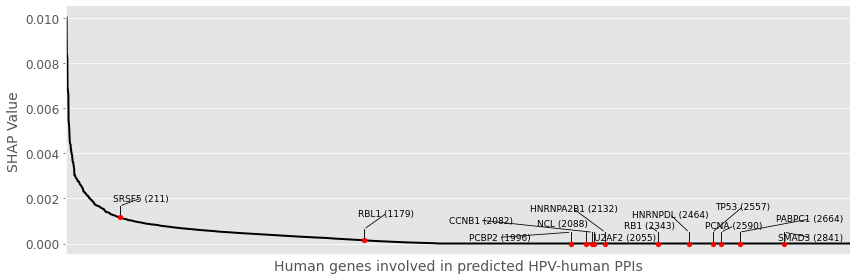

In [ ]:
def figshow_known_human_gene_lineplot():
    import pandas as pd
    import numpy as np
    import mygene
    import matplotlib.pyplot as plt
    from adjustText import adjust_text

    known_gene_of_hpv_infection = [
        "CCNB1","SMAD3","PCNA","HNRNPDL","TP53","RB1","RBL1","RBL2",
        "NCL","U2AF2","PABPC1","HNRNPA2B1","SRSF5","PCBP2"
    ]  # 已知与HPV相关基因

    # ========= 1. 读取数据 =========
    df = pd.read_csv('../data/hpv_classification/ppi_binary_matrix.csv').rename(
        columns={'Unnamed: 0': 'Taxid', 'risk_label': 'Label'}
    )

    feature_importances_df = pd.read_csv("../../data/hpv_classification/feature_importance/rf_feature_importances_ppibinary.csv")
    mean_importance = feature_importances_df.mean()
    top_n_features = mean_importance.sort_values(ascending=False)
    top_n_df = (top_n_features.rename('mean_importance')
                .reset_index()
                .rename(columns={'index':'uniprot'}))

    mg = mygene.MyGeneInfo()
    out = mg.querymany(top_n_df["uniprot"].tolist(), scopes="uniprot", fields="symbol", species="human")
    df_map = pd.DataFrame(out)
    df_map["symbol"].fillna("NoGene", inplace=True)
    dict_unid2gene = {df_map["query"][i]: df_map["symbol"][i] for i in range(df_map.shape[0])}

    colnames_gene = []
    for p in top_n_df["uniprot"].tolist():
        try:
            genename = dict_unid2gene[p]
            colnames_gene.append(genename if genename != "NoGene" else p)
        except Exception:
            colnames_gene.append(p)
    top_n_df["gene"] = colnames_gene

    # ===== 排序并计算排名 =====
    rank_df = (top_n_df
               .sort_values("mean_importance", ascending=False)
               .reset_index(drop=True))
    rank_df["rank"] = rank_df.index + 1

    x = np.arange(len(rank_df))
    y = rank_df["mean_importance"].to_numpy()

    # ===== 基础折线图 =====
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(x, y, color="black", linewidth=2)
    ax.set_xlim(-0.5, len(rank_df) - 0.5)
    ax.set_xticks([])  # 去掉x轴刻度

    # ===== 找到已知HPV基因并标红点 =====
    known_set = {g.upper() for g in known_gene_of_hpv_infection}
    present_idx = [i for i, g in enumerate(rank_df["gene"]) if str(g).upper() in known_set]

    ax.scatter(x[present_idx], y[present_idx], s=23, color="red", zorder=3)

    # ===== 自动散开标签 =====
    texts = []
    for i in present_idx:
        xi, yi = x[i], y[i]
        lx, ly = xi, yi + 0.05 * (y.max() - y.min())  # 初始稍微往上
        ax.plot([xi, lx], [yi, ly], linestyle="-", linewidth=0.9, color="black")
        texts.append(
            ax.text(lx, ly,
                    f"{rank_df.loc[i, 'gene']} ({int(rank_df.loc[i,'rank'])})",
                    ha="center", va="bottom", fontsize=9)
        )

    # 让文本自动调整，避免重叠
    adjust_text(texts, ax=ax,
                expand_text=(1.2, 1.4),
                arrowprops=dict(arrowstyle="-", color="black", lw=0.8))

    # ===== 其他美化 =====
    plt.xlabel('Human genes involved in predicted HPV-human PPIs', fontsize=14)
    plt.ylabel('SHAP Value', fontsize=14)
    plt.yticks(fontsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)

    plt.tight_layout()
    
    plt.savefig("../fig_in_paper/FigS7.pdf",
            format="pdf", 
            dpi=300,  # 高分辨率
            bbox_inches="tight", # 防止内容被裁剪
            pad_inches=0.1)  # 添加少许边距
    
    plt.show()


if __name__ == "__main__":
    figshow_known_human_gene_lineplot()


## Supplementary Table

### Table S6: Performance comparison of HT, TR and TT prediction.

In [ ]:
"""
Table S6 : HT
Per-class (one-vs-rest) evaluation of transmissibility prediction

Metrics:
Accuracy, Precision, Recall, F1-Score, AUROC, AUPRC

No plotting. Only statistics.
"""

import glob
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# =====================================================
# 1. Per-class metrics for ONE file
# =====================================================
def compute_class_metrics(file, classes):
    df = pd.read_csv(file)

    y_true = df["true"].values
    y_pred = df["pred"].values

    results = {}

    for cls in classes:
        # ----- one-vs-rest -----
        y_true_bin = (y_true == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        y_prob = df[f"prob_{cls}"].values

        # if no positive samples, skip
        if np.sum(y_true_bin) == 0:
            results[cls] = {
                "Accuracy": np.nan,
                "Precision": np.nan,
                "Recall": np.nan,
                "F1-Score": np.nan,
                "AUROC": np.nan,
                "AUPRC": np.nan
            }
            continue

        # ----- classification metrics -----
        acc = accuracy_score(y_true_bin, y_pred_bin)
        prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

        # ----- AUROC -----
        fpr, tpr, _ = roc_curve(y_true_bin, y_prob)
        auroc = auc(fpr, tpr)

        # ----- AUPRC -----
        precision, recall, _ = precision_recall_curve(y_true_bin, y_prob)
        auprc = auc(recall, precision)

        results[cls] = {
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "AUROC": auroc,
            "AUPRC": auprc
        }

    return results


# =====================================================
# 2. Aggregate across splits
# =====================================================
def compute_group_metrics(file_list, group_name, classes):
    records = []

    for file in file_list:
        metrics = compute_class_metrics(file, classes)
        for cls, vals in metrics.items():
            for metric_name, metric_val in vals.items():
                records.append({
                    "Method": group_name,
                    "Class": cls,
                    "Metric": metric_name,
                    "Value": metric_val
                })

    return pd.DataFrame(records)


# =====================================================
# 3. Main
# =====================================================
def main():

    classes = [2, 3, 4]

    # ---------- files ----------
    exp_files = sorted(
        glob.glob("../../data/transmissibility/ppibased/top200_probs_split*.csv")
    )
    ctrl_files = sorted(
        glob.glob("../../data/transmissibility/genomebased/probs_split*.csv")
    )
    ctrl_files2 = sorted(
        glob.glob("../../data/transmissibility/proteomebased/probs_split*.csv")
    )

    # ---------- compute ----------
    df_ppi = compute_group_metrics(exp_files, "PPI-HT", classes)
    df_genome = compute_group_metrics(ctrl_files, "Genome-HT", classes)
    df_proteome = compute_group_metrics(ctrl_files2, "Proteome-HT", classes)

    df_all = pd.concat([df_ppi, df_genome, df_proteome], ignore_index=True)

    # ---------- class labels ----------
    class_map = {
        2: "no human-to-human",
        3: "limited human-to-human",
        4: "sustained human-to-human"
    }
    df_all["Category"] = df_all["Class"].map(class_map)

    # ---------- summary: mean ± std ----------
    df_summary = (
        df_all
        .groupby(["Method", "Category", "Metric"])["Value"]
        .agg(["mean", "std"])
        .reset_index()
    )

    # ---------- reshape to final table ----------
    df_table = df_summary.pivot_table(
        index=["Method", "Category"],
        columns="Metric",
        values="mean"
    ).reset_index()

    # reorder columns
    df_table = df_table[
        ["Method", "Category",
         "Accuracy", "Precision", "Recall",
         "F1-Score", "AUROC", "AUPRC"]
    ]

    # round
    df_table.iloc[:, 2:] = df_table.iloc[:, 2:].round(3)
    
    out_file = "../fig_in_paper/TableS6_HT.xlsx"
    df_table.to_excel(out_file, index=False)

    print(df_table)
    print(f"\nSaved to: {out_file}")
    print(df_table)


# =====================================================
# 4. Run
# =====================================================
if __name__ == "__main__":
    main()


Metric       Method                  Category  Accuracy  Precision  Recall  \
0         Genome-HT    limited human-to-human     0.820      0.402   0.326   
1         Genome-HT         no human-to-human     0.743      0.743   0.844   
2         Genome-HT  sustained human-to-human     0.854      0.806   0.650   
3            PPI-HT    limited human-to-human     0.875      0.691   0.410   
4            PPI-HT         no human-to-human     0.788      0.781   0.875   
5            PPI-HT  sustained human-to-human     0.881      0.812   0.768   
6       Proteome-HT    limited human-to-human     0.843      0.432   0.154   
7       Proteome-HT         no human-to-human     0.712      0.696   0.874   
8       Proteome-HT  sustained human-to-human     0.835      0.756   0.638   

Metric  F1-Score  AUROC  AUPRC  
0          0.345  0.694  0.381  
1          0.788  0.794  0.837  
2          0.709  0.872  0.815  
3          0.485  0.850  0.631  
4          0.822  0.866  0.892  
5          0.781  0.9

In [ ]:
"""
Table S6: TR
Per-class (one-vs-rest) evaluation of transmission route prediction

Metrics:
Accuracy, Precision, Recall, F1-Score, AUROC, AUPRC

No plotting. Only statistics.
"""

import glob
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# =====================================================
# 1. Per-route metrics for ONE file
# =====================================================
def compute_route_metrics(file, classes):
    df = pd.read_csv(file)

    y_true = df["true"].values
    y_pred = df["pred"].values

    results = {}

    for cls in classes:
        # ----- one-vs-rest -----
        y_true_bin = (y_true == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)
        y_prob = df[f"prob_{cls}"].values

        # 若该 split 中没有该传播途径样本，返回 NaN
        if np.sum(y_true_bin) == 0:
            results[cls] = {
                "Accuracy": np.nan,
                "Precision": np.nan,
                "Recall": np.nan,
                "F1-Score": np.nan,
                "AUROC": np.nan,
                "AUPRC": np.nan
            }
            continue

        # ----- classification metrics -----
        acc = accuracy_score(y_true_bin, y_pred_bin)
        prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

        # ----- AUROC -----
        fpr, tpr, _ = roc_curve(y_true_bin, y_prob)
        auroc = auc(fpr, tpr)

        # ----- AUPRC -----
        precision, recall, _ = precision_recall_curve(y_true_bin, y_prob)
        auprc = auc(recall, precision)

        results[cls] = {
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "AUROC": auroc,
            "AUPRC": auprc
        }

    return results


# =====================================================
# 2. Aggregate across splits
# =====================================================
def compute_group_metrics(file_list, group_name, classes):
    records = []

    for file in file_list:
        metrics = compute_route_metrics(file, classes)
        for cls, vals in metrics.items():
            for metric_name, metric_val in vals.items():
                records.append({
                    "Method": group_name,
                    "Route": cls,
                    "Metric": metric_name,
                    "Value": metric_val
                })

    return pd.DataFrame(records)


# =====================================================
# 3. Main
# =====================================================
def main():

    # ---------- transmission routes ----------
    classes = ["direct contact", "faecal-oral", "respiratory", "vector"]

    # ---------- files ----------
    exp_files = sorted(
        glob.glob("../../data/transmission_route/ppibased/top350_probs_split*.csv")
    )
    ctrl_files = sorted(
        glob.glob("../../data/transmission_route/genomebased/probs_split*.csv")
    )
    ctrl_files2 = sorted(
        glob.glob("../../data/transmission_route/proteomebased/probs_split*.csv")
    )

    # ---------- compute ----------
    df_ppi = compute_group_metrics(exp_files, "PPI-TR", classes)
    df_genome = compute_group_metrics(ctrl_files, "Genome-TR", classes)
    df_proteome = compute_group_metrics(ctrl_files2, "Proteome-TR", classes)

    df_all = pd.concat([df_ppi, df_genome, df_proteome], ignore_index=True)

    # ---------- summary: mean across splits ----------
    df_summary = (
        df_all
        .groupby(["Method", "Route", "Metric"])["Value"]
        .mean()
        .reset_index()
    )

    # ---------- reshape to final table ----------
    df_table = df_summary.pivot_table(
        index=["Method", "Route"],
        columns="Metric",
        values="Value"
    ).reset_index()

    df_table = df_table[
        ["Method", "Route",
         "Accuracy", "Precision", "Recall",
         "F1-Score", "AUROC", "AUPRC"]
    ]

    # round
    df_table.iloc[:, 2:] = df_table.iloc[:, 2:].round(3)

    # ---------- save ----------
    out_file = "../fig_in_paper/TableS6_TR.xlsx"
    df_table.to_excel(out_file, index=False)

    print(df_table)
    print(f"\nSaved to: {out_file}")


# =====================================================
# 4. Run
# =====================================================
if __name__ == "__main__":
    main()


Metric       Method           Route  Accuracy  Precision  Recall  F1-Score  \
0         Genome-TR  direct contact     0.916      0.862   0.836     0.840   
1         Genome-TR     faecal-oral     0.915      0.740   0.605     0.639   
2         Genome-TR     respiratory     0.948      0.871   0.830     0.838   
3         Genome-TR          vector     0.931      0.899   0.952     0.923   
4            PPI-TR  direct contact     0.897      0.793   0.855     0.816   
5            PPI-TR     faecal-oral     0.934      0.818   0.680     0.722   
6            PPI-TR     respiratory     0.966      0.964   0.834     0.885   
7            PPI-TR          vector     0.954      0.937   0.963     0.948   
8       Proteome-TR  direct contact     0.890      0.795   0.815     0.798   
9       Proteome-TR     faecal-oral     0.941      0.870   0.660     0.726   
10      Proteome-TR     respiratory     0.944      0.878   0.788     0.818   
11      Proteome-TR          vector     0.903      0.866   0.928

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Fig.3J
Per-class (one-vs-rest) evaluation of tissue tropism prediction

Metrics:
Accuracy, Precision, Recall, F1-Score, AUROC, AUPRC

Input format:
prob_gastrointestinal, prob_neural, prob_other,
prob_respiratory, prob_systemic, prob_viraemic,
taxid, true, pred
"""

import glob
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# =====================================================
# 1. Per-tissue metrics for ONE file
# =====================================================
def compute_tissue_metrics(file, classes, prob_col_map):
    df = pd.read_csv(file)

    y_true = df["true"].values
    y_pred = df["pred"].values

    results = {}

    for cls in classes:
        # ----- one-vs-rest -----
        y_true_bin = (y_true == cls).astype(int)
        y_pred_bin = (y_pred == cls).astype(int)

        prob_col = prob_col_map[cls]
        y_prob = df[prob_col].values

        # 若该 split 中没有该组织类型样本
        if np.sum(y_true_bin) == 0:
            results[cls] = {
                "Accuracy": np.nan,
                "Precision": np.nan,
                "Recall": np.nan,
                "F1-Score": np.nan,
                "AUROC": np.nan,
                "AUPRC": np.nan
            }
            continue

        # ----- classification metrics -----
        acc = accuracy_score(y_true_bin, y_pred_bin)
        prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
        rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

        # ----- AUROC -----
        fpr, tpr, _ = roc_curve(y_true_bin, y_prob)
        auroc = auc(fpr, tpr)

        # ----- AUPRC -----
        precision, recall, _ = precision_recall_curve(y_true_bin, y_prob)
        auprc = auc(recall, precision)

        results[cls] = {
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "AUROC": auroc,
            "AUPRC": auprc
        }

    return results


# =====================================================
# 2. Aggregate across splits
# =====================================================
def compute_group_metrics(file_list, group_name, classes, prob_col_map):
    records = []

    for file in file_list:
        metrics = compute_tissue_metrics(file, classes, prob_col_map)
        for cls, vals in metrics.items():
            for metric_name, metric_val in vals.items():
                records.append({
                    "Method": group_name,
                    "TissueClass": cls,
                    "Metric": metric_name,
                    "Value": metric_val
                })

    return pd.DataFrame(records)


# =====================================================
# 3. Main
# =====================================================
def main():

    # ---------- tissue classes ----------
    classes = [0, 1, 2, 3, 4, 5]

    tissue_map = {
        0: "gastrointestinal",
        1: "neural",
        2: "other",
        3: "respiratory",
        4: "systemic",
        5: "viraemic"
    }

    # ⭐ 关键修正：概率列映射
    prob_col_map = {
        0: "prob_gastrointestinal",
        1: "prob_neural",
        2: "prob_other",
        3: "prob_respiratory",
        4: "prob_systemic",
        5: "prob_viraemic"
    }

    # ---------- files ----------
    exp_files = sorted(
        glob.glob("../../data/tissue_tropism/ppibased/top1250_probs_split*.csv")
    )
    ctrl_files = sorted(
        glob.glob("../../data/tissue_tropism/genomebased/probs_split*.csv")
    )
    ctrl_files2 = sorted(
        glob.glob("../../data/tissue_tropism/proteomebased/probs_split*.csv")
    )

    # ---------- compute ----------
    df_ppi = compute_group_metrics(exp_files, "PPI-TT", classes, prob_col_map)
    df_genome = compute_group_metrics(ctrl_files, "Genome-TT", classes, prob_col_map)
    df_proteome = compute_group_metrics(ctrl_files2, "Proteome-TT", classes, prob_col_map)

    df_all = pd.concat([df_ppi, df_genome, df_proteome], ignore_index=True)

    # ---------- map tissue names ----------
    df_all["Tissue"] = df_all["TissueClass"].map(tissue_map)

    # ---------- summary: mean across splits ----------
    df_summary = (
        df_all
        .groupby(["Method", "Tissue", "Metric"])["Value"]
        .mean()
        .reset_index()
    )

    # ---------- reshape to final table ----------
    df_table = df_summary.pivot_table(
        index=["Method", "Tissue"],
        columns="Metric",
        values="Value"
    ).reset_index()

    df_table = df_table[
        ["Method", "Tissue",
         "Accuracy", "Precision", "Recall",
         "F1-Score", "AUROC", "AUPRC"]
    ]

    # round
    df_table.iloc[:, 2:] = df_table.iloc[:, 2:].round(3)

    # ---------- save ----------
    out_file = "../fig_in_paper/TableS6_TT.xlsx"
    df_table.to_excel(out_file, index=False)

    print(df_table)
    print(f"\nSaved to: {out_file}")


# =====================================================
# 4. Run
# =====================================================
if __name__ == "__main__":
    main()


Metric       Method            Tissue  Accuracy  Precision  Recall  F1-Score  \
0         Genome-TT  gastrointestinal     0.942      0.804   0.772     0.770   
1         Genome-TT            neural     0.851      0.592   0.268     0.348   
2         Genome-TT             other     0.942      0.759   0.530     0.596   
3         Genome-TT       respiratory     0.931      0.710   0.413     0.499   
4         Genome-TT          systemic     0.901      0.692   0.498     0.554   
5         Genome-TT          viraemic     0.695      0.561   0.879     0.681   
6            PPI-TT  gastrointestinal     0.928      0.750   0.762     0.735   
7            PPI-TT            neural     0.852      0.582   0.520     0.526   
8            PPI-TT             other     0.951      0.825   0.667     0.714   
9            PPI-TT       respiratory     0.911      0.567   0.370     0.421   
10           PPI-TT          systemic     0.887      0.606   0.620     0.588   
11           PPI-TT          viraemic   